# Hybrid quality-diversity compiler for Fibonacci braids

This notebook implements and evaluates a quality-diversity reinforcement-learning compiler for six-strand Fibonacci braid words. The computational path is divided into four reproducible stages:

1. **Core implementation:** mathematical representation, scoring, archives, environment, policy, and training routines.
2. **Global discovery:** configuration, validation, multi-seed training, and checkpoint loading.
3. **Evaluation and refinement:** independent identity-start evaluation, frozen-policy suffix refinement, projective pruning, and result tables.
4. **Publication outputs:** CSV tables, a braid diagram, and a fixed-budget statistical comparison with an inverse-free random-search baseline.

Leakage and Makhlin errors are evaluated directly on the computational block, while perfect-entangler certification is reported separately from its determinant-normalized unitary polar factor.

## Reproducibility and execution

Execute the notebook from top to bottom. The global-discovery and statistical-baseline cells are computationally intensive; their configuration cells expose the corresponding workload controls. Intermediate models, archives, ledgers, and result tables are written to `hybrid_fibonacci_compiler_outputs/` so completed stages can be inspected independently.

A fresh Python environment requires NumPy, pandas, SciPy, Matplotlib, PyTorch, Gymnasium, Stable-Baselines3, `sb3-contrib`, TensorBoard, and tqdm.

In [1]:
# Uncomment in a fresh environment, then restart the kernel.
# %pip install -q numpy pandas scipy matplotlib torch gymnasium stable-baselines3 sb3-contrib tensorboard tqdm

# Part 1 — Core implementation

This part defines the mathematical model and all reusable computational components. It does not launch the multi-seed experiment. The cells are ordered by dependency so that each section can be inspected and tested independently.

## 1.1 Imports, schemas, and reproducibility utilities

In [2]:
from __future__ import annotations

from dataclasses import asdict, dataclass, field
from functools import lru_cache
from io import StringIO
from pathlib import Path
from typing import Any, Iterable, Literal, Sequence
import importlib.metadata
import importlib.util
import hashlib
import json
import math
import platform
import random
import sys
import time

import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.linalg import expm
import torch

from IPython.display import display
from sb3_contrib import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecEnv
def seed_everything(seed: int) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SOLUTION_COLUMNS = [
    'word', 'length', 'retention_amplitude', 'probability_leakage',
    'raw_makhlin_error', 'raw_total_error', 'training_cost', 'source',
]

TRAINING_BUDGET_COLUMNS = [
    'Seed', 'CurriculumStage', 'Component', 'GateScoreEvaluations',
]
TRAINING_HISTORY_COLUMNS = [
    'Seed', 'Episode', 'Timesteps', 'EpisodeReturn', 'Length',
    'ResetSource', 'ResetArchiveKey', 'ExplorationBeta',
    'EpisodicNoveltyScore', 'EpisodicNoveltyCells',
    'RestartCandidateCount', 'BestCost', 'BestRawTotalError',
    'BestRetentionAmplitude', 'BestRawMakhlinError',
    'AnyPrefixSuccess', 'BestWord', 'BestSuccessfulWord',
]

SEARCH_PROGRESS_COLUMNS = [
    'Iteration', 'SearchArchiveNodes', 'CandidatesEvaluated',
    'NonSuccessInsertions', 'SuccessesFound', 'TotalDistinctSolutions',
    'Seed', 'CurriculumStage',
]


def parse_boolean(value: Any) -> bool:
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if pd.isna(value):
        raise ValueError('Boolean value is missing.')
    normalised = str(value).strip().lower()
    if normalised in {'true', '1', 'yes', 'y'}:
        return True
    if normalised in {'false', '0', 'no', 'n'}:
        return False
    raise ValueError(f'Invalid boolean value: {value!r}')


def coerce_boolean_series(series: pd.Series) -> pd.Series:
    return series.map(parse_boolean).astype(bool)


BRAID_WORD_COLUMNS: tuple[str, ...] = (
    'Word', 'BestWord', 'BestSuccessfulWord', 'FirstCertifiedWord',
    'BestCertifiedWord', 'OriginWord', 'word', 'best_word',
    'best_successful_word',
)


def read_csv_preserving_braid_words(
    path_or_buffer: Any,
    *,
    word_columns: Sequence[str] = BRAID_WORD_COLUMNS,
    **kwargs: Any,
) -> pd.DataFrame:
    """Read a CSV without numeric coercion of digit-encoded braid words."""
    requested_dtype = kwargs.pop('dtype', None)
    if requested_dtype is None:
        dtype: Any = {}
    elif isinstance(requested_dtype, dict):
        dtype = dict(requested_dtype)
    else:
        return pd.read_csv(path_or_buffer, dtype=requested_dtype, **kwargs)

    for column in word_columns:
        dtype.setdefault(column, 'string')
    return pd.read_csv(path_or_buffer, dtype=dtype, **kwargs)


def frame_with_schema(
    frame: pd.DataFrame | None,
    columns: Sequence[str],
) -> pd.DataFrame:
    if frame is None or frame.empty:
        return pd.DataFrame(columns=list(columns))
    result = frame.copy()
    for column in columns:
        if column not in result.columns:
            result[column] = np.nan
    return result.loc[:, list(columns)]


def read_csv_or_empty(
    path: str | Path,
    *,
    columns: Sequence[str],
    **kwargs: Any,
) -> pd.DataFrame:
    path = Path(path)
    if not path.exists() or path.stat().st_size <= 1:
        return pd.DataFrame(columns=list(columns))
    try:
        frame = read_csv_preserving_braid_words(path, **kwargs)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=list(columns))
    return frame_with_schema(frame, columns)


def stable_payload_digest(payload: dict[str, Any], length: int = 16) -> str:
    encoded = json.dumps(
        payload,
        sort_keys=True,
        separators=(',', ':'),
        default=str,
    ).encode('utf-8')
    return hashlib.sha256(encoded).hexdigest()[: int(length)]


def runtime_information() -> pd.DataFrame:
    """Return the principal runtime versions used by the experiment."""
    records = [
        {"Component": "Platform", "Version": platform.platform()},
        {"Component": "Python", "Version": sys.version.split()[0]},
        {"Component": "PyTorch", "Version": torch.__version__},
        {"Component": "CUDA available", "Version": str(torch.cuda.is_available())},
    ]
    if torch.cuda.is_available():
        records.append(
            {"Component": "GPU", "Version": torch.cuda.get_device_name(0)}
        )
    return pd.DataFrame.from_records(records)

## 1.2 Experiment, archive, and search configuration

The configuration dataclasses collect the scientific thresholds, PPO hyperparameters, descriptor resolution, archive capacity, and frontier-search budget. The curriculum is scaled proportionally to the requested training budget while retaining its stage structure.

In [3]:
@dataclass(frozen=True)
class CurriculumStage:
    minimum_horizon: int
    maximum_horizon: int
    timesteps: int
    search_iterations: int = 0
    identity_reset_probability: float = 1.0
    coverage_reset_probability: float = 0.0
    frontier_reset_probability: float = 0.0
    success_discovery_bonus: float = 0.0

    def reset_probabilities(self) -> np.ndarray:
        probabilities = np.asarray(
            [
                self.identity_reset_probability,
                self.coverage_reset_probability,
                self.frontier_reset_probability,
            ],
            dtype=np.float64,
        )
        if np.any(probabilities < 0.0):
            raise ValueError('Reset probabilities must be nonnegative.')
        total = float(probabilities.sum())
        if total <= 0.0:
            raise ValueError('At least one reset probability must be positive.')
        return probabilities / total



@dataclass(frozen=True)
class ExperimentConfig:
    gamma: float = 0.995
    gae_lambda: float = 0.95
    learning_rate: float = 1e-4
    entropy_coefficient: float = 0.01
    target_kl: float | None = 0.02

    global_max_sequence_length: int = 80
    minimum_eligible_prefix_length: int = 10
    archive_minimum_prefix_length: int = 4
    minimum_continuation_after_restart: int = 4

    success_retention_threshold: float = 0.94
    success_makhlin_threshold: float = 0.1

    # For the present 1+4 unitary block structure this is exactly the
    # trace-norm computational-block unitarity defect.
    leakage_weight: float = 0.9
    makhlin_weight: float = 0.1
    normalized_violation_cap: float = 5.0

    terminal_cost_weight: float = 1.0
    quality_potential_scale: float = 0.15
    action_step_cost: float = 1e-3
    invalid_action_penalty: float = 2.0

    # The beta value is sampled once per training episode and is included in
    # the observation. Novelty is a frozen archive-cell score. Only the first
    # visit to a cell in an episode earns intrinsic reward, and the total
    # undiscounted novelty score is bounded by episodic_novelty_budget.
    exploration_betas: tuple[float, ...] = (0.0, 0.10, 0.25, 0.50)
    episodic_novelty_budget: float = 1.0
    use_online_novelty: bool = True

    # Computationally expensive mechanisms are excluded from environment stepping.
    include_successor_features: bool = False
    use_online_archive_updates: bool = False
    mask_immediate_inverse: bool = True

    # At most four short words are returned through terminal info.
    episode_restart_candidate_limit: int = 4

    num_envs: int = 8
    n_steps: int = 128
    batch_size: int = 256
    n_epochs: int = 5
    clip_range: float = 0.2

    determinant_regularization: float = 1e-12
    determinant_regularization_mode: Literal['additive', 'radial'] = (
        'additive'
    )

    tensorboard_log: str = './tensorboard_logs/'
    model_stem: str = 'hybrid_fibonacci_compiler_ppo'
    history_stem: str = 'hybrid_fibonacci_compiler_history'
    archive_stem: str = 'hybrid_fibonacci_compiler_archive'
    solutions_stem: str = 'hybrid_fibonacci_compiler_solutions'


@dataclass(frozen=True)
class ArchiveConfig:
    landmark_count: int = 8
    landmark_minimum_length: int = 3
    landmark_maximum_length: int = 40
    landmark_seed: int = 271_828

    bins_per_descriptor_dimension: int = 6

    # Novelty uses a separate coarse descriptor map. Four fixed landmark
    # coordinates plus leakage and bounded Makhlin error give six dimensions.
    # Three bins per dimension yield at most 3**6 = 729 novelty cells.
    novelty_landmark_indices: tuple[int, ...] = (0, 2, 4, 6)
    novelty_bins_per_dimension: int = 3

    @property
    def novelty_dimension_count(self) -> int:
        return len(self.novelty_landmark_indices) + 2

    @property
    def novelty_cell_count(self) -> int:
        return int(
            self.novelty_bins_per_dimension ** self.novelty_dimension_count
        )

    length_bin_width: int = 5
    elites_per_cell: int = 4
    maximum_nodes: int = 4_000
    archive_stride: int = 2

    matrix_duplicate_tolerance: float = 1e-12
    comparison_tolerance: float = 1e-10

    frontier_quantile: float = 0.30
    frontier_temperature: float = 0.15


@dataclass(frozen=True)
class FrontierSearchConfig:
    # Deliberately small between-stage budget. Parent construction traverses
    # the archive only once per iteration.
    parents_per_iteration: int = 64
    coverage_fraction: float = 0.80
    policy_actions_per_parent: int = 3
    random_actions_per_parent: int = 2
    maximum_length: int = 80
    export_non_success_nodes: int = 1_500
    report_every: int = 1
    score_class_tolerance: float = 1e-10


CONFIG = ExperimentConfig()
ARCHIVE_CONFIG = ArchiveConfig()
SEARCH_CONFIG = FrontierSearchConfig(
    maximum_length=CONFIG.global_max_sequence_length,
)

# Identity starts remain the majority throughout, while later stages retain
# enough archive restarts to prevent the longest training phase from erasing
# alternative behaviours. The repeated threshold-crossing bonus is annealed to
# zero once feasible gates are routinely found.
BASE_CURRICULUM = (
    CurriculumStage(
        10, 20, 50_000, 0, 1.00, 0.00, 0.00,
        success_discovery_bonus=0.50,
    ),
    CurriculumStage(
        15, 30, 75_000, 3, 0.75, 0.20, 0.05,
        success_discovery_bonus=0.25,
    ),
    CurriculumStage(
        20, 45, 100_000, 4, 0.65, 0.28, 0.07,
        success_discovery_bonus=0.10,
    ),
    CurriculumStage(
        25, 60, 125_000, 4, 0.65, 0.28, 0.07,
        success_discovery_bonus=0.02,
    ),
    CurriculumStage(
        30, 80, 150_000, 5, 0.70, 0.25, 0.05,
        success_discovery_bonus=0.00,
    ),
)

def scale_curriculum_timesteps(
    stages: Sequence[CurriculumStage],
    total_timesteps: int,
) -> tuple[CurriculumStage, ...]:
    total_timesteps = int(total_timesteps)
    if total_timesteps < len(stages):
        raise ValueError('The timestep budget is too small for the curriculum.')

    weights = np.asarray([stage.timesteps for stage in stages], dtype=float)
    raw = total_timesteps * weights / weights.sum()
    allocated = np.maximum(np.floor(raw).astype(int), 1)
    remainder = total_timesteps - int(allocated.sum())

    if remainder > 0:
        order = np.argsort(-(raw - np.floor(raw)))
        for index in order[:remainder]:
            allocated[index] += 1
    elif remainder < 0:
        order = np.argsort(raw - np.floor(raw))
        remaining = -remainder
        for index in order:
            removable = min(remaining, allocated[index] - 1)
            allocated[index] -= removable
            remaining -= removable
            if remaining == 0:
                break
        if remaining:
            raise RuntimeError('Could not scale the curriculum exactly.')

    result = tuple(
        CurriculumStage(
            minimum_horizon=stage.minimum_horizon,
            maximum_horizon=stage.maximum_horizon,
            timesteps=int(timesteps),
            search_iterations=stage.search_iterations,
            identity_reset_probability=stage.identity_reset_probability,
            coverage_reset_probability=stage.coverage_reset_probability,
            frontier_reset_probability=stage.frontier_reset_probability,
            success_discovery_bonus=stage.success_discovery_bonus,
        )
        for stage, timesteps in zip(stages, allocated)
    )

    if sum(stage.timesteps for stage in result) != total_timesteps:
        raise RuntimeError('Scaled curriculum does not match the budget.')
    return result


DEFAULT_TRAINING_TIMESTEPS = 300_000
DEFAULT_EVALUATION_NUM_ENVS = 8
USE_SUBPROCESS_ENVIRONMENTS = platform.system() == "Linux"

CURRICULUM = scale_curriculum_timesteps(
    BASE_CURRICULUM,
    DEFAULT_TRAINING_TIMESTEPS,
)

## 1.3 Fibonacci braid representation

The ten discrete actions consist of five positive braid generators and their inverses. Words are represented as digit strings for compact storage and are composed from left to right into the full five-dimensional braid operator.

In [4]:
def block_diagonal(*blocks: np.ndarray | complex) -> np.ndarray:
    arrays = []
    for block in blocks:
        array = np.asarray(block, dtype=np.complex128)
        if array.ndim == 0:
            array = array.reshape(1, 1)
        if array.ndim != 2 or array.shape[0] != array.shape[1]:
            raise ValueError('Every block must be square.')
        arrays.append(array)

    size = sum(array.shape[0] for array in arrays)
    result = np.zeros((size, size), dtype=np.complex128)
    offset = 0
    for array in arrays:
        width = array.shape[0]
        result[offset:offset + width, offset:offset + width] = array
        offset += width
    return result


R_MATRIX = np.array(
    [
        [np.exp(-4j * np.pi / 5), 0.0],
        [0.0, np.exp(3j * np.pi / 5)],
    ],
    dtype=np.complex128,
)

PHI = (1.0 + np.sqrt(5.0)) / 2.0
F_MATRIX = np.array(
    [
        [1.0 / PHI, np.sqrt(1.0 / PHI)],
        [np.sqrt(1.0 / PHI), -1.0 / PHI],
    ],
    dtype=np.complex128,
)


def build_positive_braid_generators() -> list[np.ndarray]:
    identity_2 = np.eye(2, dtype=np.complex128)
    transformed_r = F_MATRIX @ R_MATRIX @ F_MATRIX
    scalar = R_MATRIX[1, 1]

    permutation = np.eye(5, dtype=np.complex128)
    permutation[[0, 3]] = permutation[[3, 0]]

    rho_1 = block_diagonal(scalar, np.kron(R_MATRIX, identity_2))
    rho_2 = block_diagonal(scalar, np.kron(transformed_r, identity_2))
    rho_3 = (
        permutation
        @ block_diagonal(scalar, R_MATRIX, transformed_r)
        @ permutation
    )
    rho_4 = block_diagonal(scalar, np.kron(identity_2, transformed_r))
    rho_5 = block_diagonal(scalar, np.kron(identity_2, R_MATRIX))

    return [rho_1, rho_2, rho_3, rho_4, rho_5]


POSITIVE_BRAID_GATES = build_positive_braid_generators()
BRAID_GATES = POSITIVE_BRAID_GATES + [
    gate.conjugate().T for gate in POSITIVE_BRAID_GATES
]

GENERATOR_NAMES = [
    'rho_1', 'rho_2', 'rho_3', 'rho_4', 'rho_5',
    'rho_1^-1', 'rho_2^-1', 'rho_3^-1', 'rho_4^-1', 'rho_5^-1',
]

INVERSE_ACTION = {
    0: 5, 1: 6, 2: 7, 3: 8, 4: 9,
    5: 0, 6: 1, 7: 2, 8: 3, 9: 4,
}

TARGET_GATE = np.array(
    [
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
    ],
    dtype=np.complex128,
)


def compose_actions(
    actions: Iterable[int],
    braid_gates: Sequence[np.ndarray] = BRAID_GATES,
) -> np.ndarray:
    composition = np.eye(5, dtype=np.complex128)
    for action in actions:
        index = int(action)
        if index < 0 or index >= len(braid_gates):
            raise IndexError(f'Invalid braid action {index}.')
        composition = composition @ braid_gates[index]
    return composition


def actions_to_word(actions: Iterable[int]) -> str:
    return ''.join(str(int(action)) for action in actions)


def word_to_actions(word: str) -> list[int]:
    value = str(word).strip()
    if any(character not in '0123456789' for character in value):
        raise ValueError('Braid words must use action digits 0 through 9.')
    return [int(character) for character in value]


def reduce_actions(actions: Iterable[int]) -> tuple[int, ...]:
    stack: list[int] = []
    for raw_action in actions:
        action = int(raw_action)
        if stack and INVERSE_ACTION[action] == stack[-1]:
            stack.pop()
        else:
            stack.append(action)
    return tuple(stack)


def sample_inverse_free_actions(
    length: int,
    rng: np.random.Generator,
) -> tuple[int, ...]:
    actions: list[int] = []
    for _ in range(int(length)):
        legal = list(range(len(BRAID_GATES)))
        if actions:
            legal.remove(INVERSE_ACTION[actions[-1]])
        actions.append(int(rng.choice(legal)))
    return tuple(actions)

## 1.4 Gate metrics and lexicographic objective

The computational block is scored without unitary projection or rescaling. Threshold success combines a retention-amplitude condition with a raw Makhlin-invariant error condition. The continuous training cost places eligible successes and failures in disjoint intervals.

In [5]:
MAGIC_BASIS = (1.0 / np.sqrt(2.0)) * np.array(
    [
        [1, 0, 0, 1j],
        [0, 1j, 1, 0],
        [0, 1j, -1, 0],
        [1, 0, 0, -1j],
    ],
    dtype=np.complex128,
)


@dataclass(frozen=True)
class GateMetrics:
    retention_amplitude: float
    probability_leakage: float
    physical_error: float
    raw_makhlin_error: float
    raw_total_error: float
    candidate_invariants: tuple[complex, complex, complex]


@dataclass(frozen=True)
class ThresholdObjective:
    retention_violation: float
    makhlin_violation: float
    threshold_error: float


def regularize_determinant(
    determinant: complex,
    *,
    epsilon: float,
    mode: str,
) -> complex:
    if abs(determinant) >= epsilon:
        return complex(determinant)

    if mode == 'additive':
        return complex(determinant + epsilon)

    if mode == 'radial':
        if determinant == 0:
            return complex(epsilon)
        return complex(epsilon * determinant / abs(determinant))

    raise ValueError(f'Unknown determinant regularization mode: {mode!r}.')


def compute_makhlin_invariants(
    matrix: np.ndarray,
    *,
    config: ExperimentConfig = CONFIG,
) -> tuple[complex, complex, complex]:
    """Evaluate the selected Makhlin formulae on the supplied 4x4 matrix.

    The matrix is intentionally not projected to a unitary, normalised, or
    replaced by a polar factor.
    """
    matrix = np.asarray(matrix, dtype=np.complex128)
    if matrix.shape != (4, 4):
        raise ValueError(f'Expected a 4x4 matrix, received {matrix.shape}.')

    transformed = MAGIC_BASIS.conjugate().T @ matrix @ MAGIC_BASIS
    makhlin_matrix = transformed.T @ transformed

    trace_m = np.trace(makhlin_matrix)
    trace_m2 = np.trace(makhlin_matrix @ makhlin_matrix)
    determinant = regularize_determinant(
        np.linalg.det(matrix),
        epsilon=config.determinant_regularization,
        mode=config.determinant_regularization_mode,
    )

    complex_invariant = trace_m**2 / (16.0 * determinant)
    return (
        complex(complex_invariant.real),
        complex(complex_invariant.imag),
        complex((trace_m**2 - trace_m2) / (4.0 * determinant)),
    )


TARGET_INVARIANTS = compute_makhlin_invariants(TARGET_GATE)


def compute_gate_metrics(
    full_matrix: np.ndarray,
    *,
    config: ExperimentConfig = CONFIG,
) -> GateMetrics:
    full_matrix = np.asarray(full_matrix, dtype=np.complex128)
    if full_matrix.shape != (5, 5):
        raise ValueError(f'Expected a 5x5 matrix, received {full_matrix.shape}.')

    retention = float(abs(full_matrix[0, 0]))
    probability_leakage = float(
        np.clip(1.0 - retention**2, 0.0, 1.0)
    )

    candidate_invariants = compute_makhlin_invariants(
        full_matrix[1:5, 1:5],
        config=config,
    )
    raw_makhlin_error = float(
        sum(
            abs(target - candidate) ** 2
            for target, candidate in zip(
                TARGET_INVARIANTS,
                candidate_invariants,
            )
        )
    )

    physical_error = float(config.leakage_weight * probability_leakage)
    raw_total_error = float(
        physical_error + config.makhlin_weight * raw_makhlin_error
    )

    return GateMetrics(
        retention_amplitude=retention,
        probability_leakage=probability_leakage,
        physical_error=physical_error,
        raw_makhlin_error=raw_makhlin_error,
        raw_total_error=raw_total_error,
        candidate_invariants=candidate_invariants,
    )


def compute_threshold_objective(
    metrics: GateMetrics,
    *,
    config: ExperimentConfig = CONFIG,
) -> ThresholdObjective:
    retention_violation = max(
        0.0,
        (
            config.success_retention_threshold
            - metrics.retention_amplitude
        )
        / max(1.0 - config.success_retention_threshold, 1e-12),
    )
    makhlin_violation = max(
        0.0,
        (
            metrics.raw_makhlin_error
            - config.success_makhlin_threshold
        )
        / max(config.success_makhlin_threshold, 1e-12),
    )

    retention_violation = min(
        retention_violation,
        config.normalized_violation_cap,
    )
    makhlin_violation = min(
        makhlin_violation,
        config.normalized_violation_cap,
    )

    return ThresholdObjective(
        retention_violation=float(retention_violation),
        makhlin_violation=float(makhlin_violation),
        threshold_error=float(
            retention_violation**2 + makhlin_violation**2
        ),
    )


def is_success(
    metrics: GateMetrics,
    *,
    config: ExperimentConfig = CONFIG,
) -> bool:
    return bool(
        metrics.retention_amplitude > config.success_retention_threshold
        and metrics.raw_makhlin_error < config.success_makhlin_threshold
    )


def lexicographic_training_cost(
    metrics: GateMetrics,
    objective: ThresholdObjective,
    *,
    eligible: bool,
    config: ExperimentConfig = CONFIG,
) -> float:
    """Return a continuous cost with success and failure in disjoint ranges.

    Eligible successful states lie in [0, 1). All other states lie in [1, 2).
    This preserves a strong discovery signal without making all successful
    gates nearly equivalent.
    """
    eligible_success = eligible and is_success(metrics, config=config)

    boundary_reference = (
        config.leakage_weight
        * (1.0 - config.success_retention_threshold**2)
        + config.makhlin_weight * config.success_makhlin_threshold
    )
    boundary_reference = max(boundary_reference, 1e-12)

    if eligible_success:
        quality = metrics.raw_total_error
        return float(quality / (quality + boundary_reference))

    violation = objective.threshold_error
    return float(1.0 + violation / (1.0 + violation))


@lru_cache(maxsize=None)
def identity_scoring_state(
    config: ExperimentConfig = CONFIG,
) -> tuple[np.ndarray, GateMetrics, ThresholdObjective, float]:
    """Return the cached identity state and its direct scoring data."""
    composition = np.eye(5, dtype=np.complex128)
    metrics = compute_gate_metrics(composition, config=config)
    objective = compute_threshold_objective(metrics, config=config)
    cost = lexicographic_training_cost(
        metrics,
        objective,
        eligible=False,
        config=config,
    )
    return composition, metrics, objective, cost

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## 1.5 Perfect-entangler certification and scoring fingerprints

Perfect-entangler membership is evaluated on the determinant-normalized polar unitary of the computational block. This diagnostic is kept distinct from the direct leakage and Makhlin scores used during training. Fixed numerical fingerprints protect the direct scoring path against accidental normalization changes.

In [6]:
# Perfect-entangler membership is a closed condition. A zero margin is a valid
# boundary point (including exact CNOT); a positive threshold is reported
# separately as a robust-interior diagnostic.
PERFECT_ENTANGLER_NUMERICAL_TOLERANCE = 1e-10


def unitary_polar_factor(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=np.complex128)
    if matrix.shape != (4, 4):
        raise ValueError(f'Expected a 4x4 matrix, received {matrix.shape}.')

    left, _, right_adjoint = np.linalg.svd(matrix, full_matrices=False)
    unitary = left @ right_adjoint
    determinant = np.linalg.det(unitary)
    if abs(determinant) < 1e-14:
        raise FloatingPointError('Polar unitary has a vanishing determinant.')
    return unitary * np.exp(-0.25j * np.angle(determinant))


def perfect_entangler_spectral_margin(unitary: np.ndarray) -> float:
    unitary = np.asarray(unitary, dtype=np.complex128)
    defect = np.linalg.norm(
        unitary.conjugate().T @ unitary - np.eye(4),
        ord=2,
    )
    if defect > 1e-8:
        raise ValueError('Perfect-entangler diagnostics require a unitary.')

    transformed = MAGIC_BASIS.conjugate().T @ unitary @ MAGIC_BASIS
    makhlin_matrix = transformed.T @ transformed
    eigenvalues = np.linalg.eigvals(makhlin_matrix)
    magnitudes = np.abs(eigenvalues)
    if np.any(magnitudes < 1e-14):
        raise FloatingPointError(
            'Perfect-entangler diagnostic encountered a zero eigenvalue.'
        )

    phases = np.sort(
        np.mod(np.angle(eigenvalues / magnitudes), 2.0 * np.pi)
    )
    circular = np.concatenate([phases, [phases[0] + 2.0 * np.pi]])
    maximum_gap = float(np.max(np.diff(circular)))
    return float((np.pi - maximum_gap) / np.pi)


def perfect_entangler_diagnostics(
    full_matrix: np.ndarray,
    *,
    robust_margin_threshold: float,
    numerical_tolerance: float = PERFECT_ENTANGLER_NUMERICAL_TOLERANCE,
) -> tuple[bool, bool, float]:
    full_matrix = np.asarray(full_matrix, dtype=np.complex128)
    if full_matrix.shape != (5, 5):
        raise ValueError(f'Expected a 5x5 matrix, received {full_matrix.shape}.')
    polar = unitary_polar_factor(full_matrix[1:5, 1:5])
    margin = perfect_entangler_spectral_margin(polar)
    perfect_entangler = margin >= -abs(float(numerical_tolerance))
    robust_interior = margin >= float(robust_margin_threshold)
    return bool(perfect_entangler), bool(robust_interior), float(margin)
def signed_log1p(values: np.ndarray | Sequence[float]) -> np.ndarray:
    array = np.asarray(values, dtype=np.float64)
    return np.sign(array) * np.log1p(np.abs(array))


# Fixed outputs from the direct Makhlin path. These fingerprints
# protect against accidentally inserting a unitary projection, polar factor,
# determinant phase normalisation, or computational-block rescaling.
MAKHLIN_REGRESSION_FINGERPRINTS: dict[
    str,
    tuple[tuple[complex, complex, complex], float],
] = {
    '01234': (
        (
            complex(-0.059016994374947514, 0.0),
            complex(1.544132107204479e-16, 0.0),
            complex(0.8819660112501042, 3.6332520169517157e-16),
        ),
        0.017415028125262903,
    ),
    '0246813579': (
        (
            complex(0.9999999999999991, 0.0),
            complex(-2.465190328815662e-32, 0.0),
            complex(2.9999999999999973, -9.860761315262648e-32),
        ),
        4.999999999999991,
    ),
    '001122334455': (
        (
            complex(0.2682372542187883, 0.0),
            complex(-0.531656755220024, 0.0),
            complex(1.5364745084375757, -1.063313510440048),
        ),
        1.773050649609597,
    ),
    '9876543210': (
        (
            complex(0.05901699437494749, 0.0),
            complex(6.429464252197593e-18, 0.0),
            complex(-0.8819660112501041, 1.2858928504395286e-17),
        ),
        3.5452790731256765,
    ),
}


def run_makhlin_path_regression_tests(tolerance: float = 2e-13) -> None:
    for word, (expected_invariants, expected_error) in (
        MAKHLIN_REGRESSION_FINGERPRINTS.items()
    ):
        full_matrix = compose_actions(word_to_actions(word))
        metrics = compute_gate_metrics(full_matrix)
        assert np.allclose(
            np.asarray(metrics.candidate_invariants),
            np.asarray(expected_invariants),
            atol=tolerance,
            rtol=tolerance,
        )
        assert np.isclose(
            metrics.raw_makhlin_error,
            expected_error,
            atol=tolerance,
            rtol=tolerance,
        )

## 1.6 Mathematical regression tests

These tests verify the direct Makhlin fingerprints, generator unitarity, the exact leakage–unitarity relation for the one-plus-four block decomposition, and the perfect-entangler boundary convention.

In [7]:
# For a full unitary block matrix

# \[
# U=\begin{pmatrix}a&b\\c&A\end{pmatrix}\in U(5),
# \]

# with a one-dimensional leakage sector and a four-dimensional computational sector,

# \[
# I-A^\dagger A=b^\dagger b,
# \qquad
# \|I-A^\dagger A\|_1=\|b\|^2=1-|a|^2.
# \]

# The singular values of $A$ are $1,1,1,|a|$. The regression test below checks the identity numerically for generated braid words.
def schatten_trace_norm(matrix: np.ndarray) -> float:
    singular_values = np.linalg.svd(
        np.asarray(matrix, dtype=np.complex128),
        compute_uv=False,
    )
    return float(np.sum(singular_values))


def run_mathematical_regression_tests(
    number_of_words: int = 250,
    seed: int = 1234,
) -> None:
    run_makhlin_path_regression_tests()

    target_full = block_diagonal(1.0, TARGET_GATE)
    target_pe, target_robust, target_margin = perfect_entangler_diagnostics(
        target_full,
        robust_margin_threshold=1e-4,
    )
    assert target_pe
    assert not target_robust
    assert abs(target_margin) < 1e-12

    identity_5 = np.eye(5, dtype=np.complex128)
    generator_defects = [
        np.linalg.norm(gate.conjugate().T @ gate - identity_5, ord=2)
        for gate in BRAID_GATES
    ]
    assert max(generator_defects) < 1e-10

    rng = np.random.default_rng(seed)
    nonunitary_blocks = 0

    for _ in range(number_of_words):
        length = int(rng.integers(1, CONFIG.global_max_sequence_length + 1))
        actions = sample_inverse_free_actions(length, rng)
        full_matrix = compose_actions(actions)
        block = full_matrix[1:5, 1:5]
        metrics = compute_gate_metrics(full_matrix)

        defect = np.eye(4, dtype=np.complex128) - block.conjugate().T @ block
        trace_norm_defect = schatten_trace_norm(defect)
        assert np.isclose(
            trace_norm_defect,
            metrics.probability_leakage,
            atol=1e-10,
            rtol=1e-10,
        )

        singular_values = np.sort(np.linalg.svd(block, compute_uv=False))
        expected = np.sort(
            np.array([1.0, 1.0, 1.0, metrics.retention_amplitude])
        )
        assert np.allclose(singular_values, expected, atol=1e-10, rtol=1e-10)
        assert np.isclose(
            abs(np.linalg.det(block)),
            metrics.retention_amplitude,
            atol=1e-10,
            rtol=1e-10,
        )

        nonunitary_blocks += int(
            np.linalg.norm(block.conjugate().T @ block - np.eye(4), ord=2)
            > 1e-12
        )

    assert nonunitary_blocks > 0
    print(
        f'Passed {number_of_words} mathematical regression tests; '
        f'{nonunitary_blocks} sampled computational blocks were non-unitary.'
    )

## 1.7 Projective geometry and archive descriptors

Archive descriptors combine distances to fixed non-success landmarks with leakage and bounded Makhlin error. Projective distance quotients out the physically irrelevant global phase of the complete braid operator.

In [8]:
def projective_distance_squared(
    left: np.ndarray,
    right: np.ndarray,
) -> float:
    """Global-phase-quotiented distance for full 5x5 unitary matrices.

    The returned normalised value is

        1 - |tr(left^dagger right)| / 5,

    and lies in [0, 1] up to floating-point error.
    """
    overlap = np.trace(
        np.asarray(left).conjugate().T @ np.asarray(right)
    )
    value = 1.0 - abs(overlap) / 5.0
    return float(np.clip(value, 0.0, 1.0))


@dataclass(frozen=True)
class ArchiveDescriptor:
    landmarks: tuple[np.ndarray, ...]
    bins_per_dimension: int

    def values(
        self,
        matrix: np.ndarray,
        metrics: GateMetrics,
    ) -> np.ndarray:
        distances = np.array(
            [
                projective_distance_squared(matrix, landmark)
                for landmark in self.landmarks
            ],
            dtype=np.float64,
        )
        bounded_makhlin = (
            metrics.raw_makhlin_error
            / (1.0 + metrics.raw_makhlin_error)
        )
        return np.concatenate(
            [
                distances,
                np.array(
                    [metrics.probability_leakage, bounded_makhlin],
                    dtype=np.float64,
                ),
            ]
        )

    def cell(
        self,
        matrix: np.ndarray,
        metrics: GateMetrics,
    ) -> tuple[int, ...]:
        values = np.clip(self.values(matrix, metrics), 0.0, 1.0)
        bins = np.floor(values * self.bins_per_dimension).astype(int)
        bins = np.clip(bins, 0, self.bins_per_dimension - 1)
        return tuple(map(int, bins))


def make_non_success_descriptor_landmarks(
    *,
    archive_config: ArchiveConfig = ARCHIVE_CONFIG,
    experiment_config: ExperimentConfig = CONFIG,
) -> ArchiveDescriptor:
    """Build fixed descriptor anchors without using successful gates.

    These matrices are geometric landmarks only. They are never reset states,
    demonstrations, behaviour-cloning targets, or policy actions.
    """
    rng = np.random.default_rng(archive_config.landmark_seed)
    landmarks: list[np.ndarray] = [np.eye(5, dtype=np.complex128)]

    attempts = 0
    maximum_attempts = 100_000
    while len(landmarks) < archive_config.landmark_count:
        attempts += 1
        if attempts > maximum_attempts:
            raise RuntimeError('Could not generate enough non-success landmarks.')

        length = int(
            rng.integers(
                archive_config.landmark_minimum_length,
                archive_config.landmark_maximum_length + 1,
            )
        )
        actions = sample_inverse_free_actions(length, rng)
        matrix = compose_actions(actions)
        metrics = compute_gate_metrics(matrix, config=experiment_config)
        if is_success(metrics, config=experiment_config):
            continue

        if any(
            projective_distance_squared(matrix, existing) < 1e-8
            for existing in landmarks
        ):
            continue

        landmarks.append(matrix)

    return ArchiveDescriptor(
        landmarks=tuple(landmarks),
        bins_per_dimension=archive_config.bins_per_descriptor_dimension,
    )


def novelty_descriptor_key(
    descriptor: ArchiveDescriptor,
    archive_config: ArchiveConfig,
    matrix: np.ndarray,
    metrics: GateMetrics,
) -> tuple[int, ...]:
    """Return the coarse novelty cell for one physical state."""
    values = descriptor.values(
        np.asarray(matrix, dtype=np.complex128),
        metrics,
    )
    indices = archive_config.novelty_landmark_indices
    if not indices:
        raise ValueError('At least one novelty landmark is required.')
    if min(indices) < 0 or max(indices) >= len(descriptor.landmarks):
        raise ValueError('Novelty landmark index is outside the descriptor.')

    selected = np.concatenate(
        [
            values[np.asarray(indices, dtype=int)],
            values[-2:],
        ]
    )
    bins_per_dimension = int(archive_config.novelty_bins_per_dimension)
    if bins_per_dimension < 2:
        raise ValueError('Novelty requires at least two bins per dimension.')
    bins = np.floor(
        np.clip(selected, 0.0, 1.0) * bins_per_dimension
    ).astype(int)
    bins = np.clip(bins, 0, bins_per_dimension - 1)
    return tuple(map(int, bins))


def novelty_cell_index(
    key: Sequence[int],
    archive_config: ArchiveConfig,
) -> int:
    """Encode a novelty-cell tuple as a dense base-b index."""
    key_tuple = tuple(map(int, key))
    if len(key_tuple) != archive_config.novelty_dimension_count:
        raise ValueError('Novelty key has the wrong dimension.')
    bins = int(archive_config.novelty_bins_per_dimension)
    index = 0
    for coordinate in key_tuple:
        if coordinate < 0 or coordinate >= bins:
            raise ValueError('Novelty coordinate lies outside the cell grid.')
        index = index * bins + coordinate
    return int(index)


def empty_novelty_visit_mask(
    archive_config: ArchiveConfig,
) -> np.ndarray:
    return np.zeros(archive_config.novelty_cell_count, dtype=np.float32)


def mark_novelty_key_visited(
    visit_mask: np.ndarray,
    key: Sequence[int],
    archive_config: ArchiveConfig,
) -> int:
    """Mark a novelty cell and return its dense index."""
    mask = np.asarray(visit_mask)
    expected_shape = (archive_config.novelty_cell_count,)
    if mask.shape != expected_shape:
        raise ValueError(
            f'Novelty visit mask has shape {mask.shape}; expected {expected_shape}.'
        )
    index = novelty_cell_index(key, archive_config)
    mask[index] = 1.0
    return index


DESCRIPTOR = make_non_success_descriptor_landmarks()

## 1.8 Solution records and non-success archive

Successful words are stored only for reporting. Training restarts are drawn from a separate archive containing verified non-success prefixes. Each archive cell retains a small cost–length Pareto set with matrix diversity.

In [9]:
@dataclass(eq=False)
class FrontierNode:
    composition: np.ndarray
    actions: tuple[int, ...]
    metrics: GateMetrics
    cost: float
    best_cost: float
    best_actions: tuple[int, ...]
    best_metrics: GateMetrics
    source: str
    novelty_visit_mask: np.ndarray = field(repr=False)
    verified_no_successful_prefix: bool = True
    times_selected: int = 0

    @property
    def last_action(self) -> int:
        return self.actions[-1] if self.actions else len(BRAID_GATES)

    @property
    def length(self) -> int:
        return len(self.actions)


@dataclass(frozen=True)
class SolutionRecord:
    word: str
    length: int
    retention_amplitude: float
    probability_leakage: float
    raw_makhlin_error: float
    raw_total_error: float
    training_cost: float
    source: str


class SolutionArchive:
    """A reporting-only archive. Its contents are never training starts."""

    def __init__(self, score_tolerance: float = 1e-10) -> None:
        self.score_tolerance = float(score_tolerance)
        self._by_word: dict[str, SolutionRecord] = {}

    def insert(
        self,
        actions: Sequence[int],
        metrics: GateMetrics,
        cost: float,
        *,
        source: str,
    ) -> bool:
        reduced = reduce_actions(actions)
        word = actions_to_word(reduced)
        record = SolutionRecord(
            word=word,
            length=len(reduced),
            retention_amplitude=metrics.retention_amplitude,
            probability_leakage=metrics.probability_leakage,
            raw_makhlin_error=metrics.raw_makhlin_error,
            raw_total_error=metrics.raw_total_error,
            training_cost=float(cost),
            source=str(source),
        )
        incumbent = self._by_word.get(word)
        if incumbent is None or record.raw_total_error < incumbent.raw_total_error:
            self._by_word[word] = record
            return True
        return False

    def __len__(self) -> int:
        return len(self._by_word)

    def to_frame(self) -> pd.DataFrame:
        if not self._by_word:
            return pd.DataFrame(columns=SOLUTION_COLUMNS)

        frame = pd.DataFrame.from_records(
            [asdict(record) for record in self._by_word.values()],
            columns=SOLUTION_COLUMNS,
        )
        tolerance = self.score_tolerance
        frame['_RetentionClass'] = np.rint(
            frame['retention_amplitude'] / tolerance
        ).astype(np.int64)
        frame['_MakhlinClass'] = np.rint(
            frame['raw_makhlin_error'] / tolerance
        ).astype(np.int64)
        frame['_TotalClass'] = np.rint(
            frame['raw_total_error'] / tolerance
        ).astype(np.int64)

        return (
            frame.sort_values(
                ['raw_total_error', 'raw_makhlin_error', 'length']
            )
            .drop_duplicates(
                ['_RetentionClass', '_MakhlinClass', '_TotalClass'],
                keep='first',
            )
            .drop(columns=['_RetentionClass', '_MakhlinClass', '_TotalClass'])
            .reset_index(drop=True)
        )

class DiversityArchive:
    """Two-layer archive used for non-success training restarts.

    `active_cells` is frozen during a PPO curriculum stage and determines
    restarts and novelty scores. `staging_cells` receives states generated
    during that stage. `commit_staging` merges them only between stages.
    """

    def __init__(
        self,
        descriptor: ArchiveDescriptor,
        *,
        archive_config: ArchiveConfig = ARCHIVE_CONFIG,
        experiment_config: ExperimentConfig = CONFIG,
    ) -> None:
        self.descriptor = descriptor
        self.archive_config = archive_config
        self.experiment_config = experiment_config

        self.active_cells: dict[tuple[int, ...], list[FrontierNode]] = {}
        self.staging_cells: dict[tuple[int, ...], list[FrontierNode]] = {}
        self.cell_selection_counts: dict[tuple[int, ...], int] = {}
        self.active_novelty_counts: dict[tuple[int, ...], int] = {}

        # Cached counts avoid scanning every archive cell after every insertion.
        # This preserves the original sequential insertion/pruning semantics.
        self._active_node_count = 0
        self._staging_node_count = 0

        identity, metrics, _, cost = identity_scoring_state(
            experiment_config
        )
        identity_mask = empty_novelty_visit_mask(archive_config)
        identity_key = novelty_descriptor_key(
            descriptor,
            archive_config,
            identity,
            metrics,
        )
        mark_novelty_key_visited(
            identity_mask,
            identity_key,
            archive_config,
        )
        self.insert_active(
            FrontierNode(
                composition=identity.copy(),
                actions=(),
                metrics=metrics,
                cost=cost,
                best_cost=cost,
                best_actions=(),
                best_metrics=metrics,
                source='identity',
                novelty_visit_mask=identity_mask,
            )
        )

    def key_for_state(
        self,
        matrix: np.ndarray,
        metrics: GateMetrics,
        actions: Sequence[int],
    ) -> tuple[int, ...]:
        actions_tuple = tuple(map(int, actions))
        descriptor_cell = self.descriptor.cell(matrix, metrics)
        length_bin = len(actions_tuple) // self.archive_config.length_bin_width
        last_action = (
            actions_tuple[-1] if actions_tuple else len(BRAID_GATES)
        )
        return (
            int(last_action),
            int(length_bin),
            *descriptor_cell,
        )

    def key_for(self, node: FrontierNode) -> tuple[int, ...]:
        return self.key_for_state(
            node.composition,
            node.metrics,
            node.actions,
        )

    def novelty_key_for_state(
        self,
        matrix: np.ndarray,
        metrics: GateMetrics,
    ) -> tuple[int, ...]:
        """Return the coarse descriptor key used only for novelty."""
        return novelty_descriptor_key(
            self.descriptor,
            self.archive_config,
            matrix,
            metrics,
        )

    def _adjust_active_novelty_count(
        self,
        node: FrontierNode,
        delta: int,
    ) -> None:
        key = self.novelty_key_for_state(node.composition, node.metrics)
        updated = self.active_novelty_counts.get(key, 0) + int(delta)
        if updated < 0:
            raise RuntimeError('Novelty occupancy became negative.')
        if updated == 0:
            self.active_novelty_counts.pop(key, None)
        else:
            self.active_novelty_counts[key] = updated

    def add_selection_counts(
        self,
        increments: dict[tuple[int, ...], int],
    ) -> None:
        for key, raw_count in increments.items():
            count = int(raw_count)
            if count <= 0:
                continue
            tuple_key = tuple(map(int, key))
            self.cell_selection_counts[tuple_key] = (
                self.cell_selection_counts.get(tuple_key, 0) + count
            )

    def merge_selection_counts_max(
        self,
        counts: dict[tuple[int, ...], int],
    ) -> None:
        for key, raw_count in counts.items():
            tuple_key = tuple(map(int, key))
            self.cell_selection_counts[tuple_key] = max(
                self.cell_selection_counts.get(tuple_key, 0),
                int(raw_count),
            )

    def _dominates(self, left: FrontierNode, right: FrontierNode) -> bool:
        tolerance = self.archive_config.comparison_tolerance
        weak = (
            left.cost <= right.cost + tolerance
            and left.length <= right.length
        )
        strict = (
            left.cost < right.cost - tolerance
            or left.length < right.length
        )
        return bool(weak and strict)

    def _select_diverse_subset(
        self,
        nodes: Sequence[FrontierNode],
        maximum: int,
    ) -> list[FrontierNode]:
        nodes = list(nodes)
        if len(nodes) <= maximum:
            return nodes

        selected: list[FrontierNode] = []
        best_cost = min(nodes, key=lambda node: (node.cost, node.length))
        shortest = min(nodes, key=lambda node: (node.length, node.cost))
        selected.append(best_cost)
        if shortest is not best_cost:
            selected.append(shortest)

        remaining = [node for node in nodes if node not in selected]
        while remaining and len(selected) < maximum:
            candidate = max(
                remaining,
                key=lambda node: (
                    min(
                        projective_distance_squared(
                            node.composition,
                            chosen.composition,
                        )
                        for chosen in selected
                    ),
                    -node.cost,
                    -node.length,
                ),
            )
            selected.append(candidate)
            remaining.remove(candidate)

        return selected

    def _insert_into(
        self,
        cells: dict[tuple[int, ...], list[FrontierNode]],
        node: FrontierNode,
    ) -> tuple[bool, int]:
        if not node.verified_no_successful_prefix:
            raise ValueError('Restart nodes must have no successful prefix.')
        if is_success(node.metrics, config=self.experiment_config):
            raise ValueError('Successful states cannot enter the restart archive.')

        novelty_mask = np.asarray(
            node.novelty_visit_mask,
            dtype=np.float32,
        )
        expected_shape = (self.archive_config.novelty_cell_count,)
        if novelty_mask.shape != expected_shape:
            raise ValueError(
                'Restart node has an invalid novelty-history mask shape.'
            )
        if np.any((novelty_mask != 0.0) & (novelty_mask != 1.0)):
            raise ValueError('Novelty-history masks must be binary.')
        current_novelty_key = self.novelty_key_for_state(
            node.composition,
            node.metrics,
        )
        current_novelty_index = novelty_cell_index(
            current_novelty_key,
            self.archive_config,
        )
        if novelty_mask[current_novelty_index] != 1.0:
            raise ValueError(
                'Restart node novelty history omits its current state.'
            )
        node.novelty_visit_mask = novelty_mask.copy()

        key = self.key_for(node)
        original_incumbents = list(cells.get(key, []))
        incumbents = list(original_incumbents)

        for incumbent in incumbents:
            if (
                projective_distance_squared(
                    node.composition,
                    incumbent.composition,
                )
                <= self.archive_config.matrix_duplicate_tolerance
            ):
                if self._dominates(node, incumbent):
                    incumbents.remove(incumbent)
                    break
                return False, 0

        candidates = incumbents + [node]
        nondominated = [
            candidate
            for candidate in candidates
            if not any(
                other is not candidate and self._dominates(other, candidate)
                for other in candidates
            )
        ]
        retained = self._select_diverse_subset(
            nondominated,
            self.archive_config.elites_per_cell,
        )
        cells[key] = retained
        return node in retained, len(retained) - len(original_incumbents)

    def _node_count(
        self,
        cells: dict[tuple[int, ...], list[FrontierNode]],
    ) -> int:
        # Retained for diagnostics and regression checks. Performance-sensitive paths use the
        # cached active/staging counts below.
        return sum(len(nodes) for nodes in cells.values())

    def _prune_to_capacity(
        self,
        cells: dict[tuple[int, ...], list[FrontierNode]],
        current_count: int,
    ) -> tuple[list[FrontierNode], int]:
        removed: list[FrontierNode] = []
        maximum = self.archive_config.maximum_nodes
        while current_count > maximum:
            candidate_keys = [key for key, nodes in cells.items() if nodes]
            key = max(
                candidate_keys,
                key=lambda value: (
                    self.cell_selection_counts.get(value, 0),
                    len(cells[value]),
                    max(node.cost for node in cells[value]),
                ),
            )
            nodes = cells[key]
            removal = max(nodes, key=lambda node: (node.cost, node.length))
            nodes.remove(removal)
            removed.append(removal)
            current_count -= 1
            if not nodes:
                del cells[key]
        return removed, current_count

    def stage(self, node: FrontierNode) -> bool:
        inserted, delta = self._insert_into(self.staging_cells, node)
        if not inserted:
            return False
        self._staging_node_count += delta
        _, self._staging_node_count = self._prune_to_capacity(
            self.staging_cells,
            self._staging_node_count,
        )
        return True

    def insert_active(self, node: FrontierNode) -> bool:
        storage_key = self.key_for(node)
        previous_nodes = tuple(self.active_cells.get(storage_key, ()))
        inserted, delta = self._insert_into(self.active_cells, node)
        if not inserted:
            return False

        self._active_node_count += delta
        for previous in previous_nodes:
            self._adjust_active_novelty_count(previous, -1)
        for retained in self.active_cells.get(storage_key, ()):
            self._adjust_active_novelty_count(retained, +1)

        removed, self._active_node_count = self._prune_to_capacity(
            self.active_cells,
            self._active_node_count,
        )
        for removed_node in removed:
            self._adjust_active_novelty_count(removed_node, -1)
        return True

    def commit_staging(self) -> int:
        inserted = 0
        for nodes in list(self.staging_cells.values()):
            for node in nodes:
                inserted += int(self.insert_active(node))
        self.staging_cells.clear()
        self._staging_node_count = 0
        return inserted

    def __len__(self) -> int:
        return int(self._active_node_count)

    def active_nodes(
        self,
        *,
        include_identity: bool = True,
    ) -> list[FrontierNode]:
        """Return a stable snapshot of nodes in the active archive.

        The archive is stored by cell in ``active_cells``.  Search, cloning,
        validation, and export code use this helper when they need a flat
        collection.  Identity is identified by its empty action tuple.
        """
        nodes = [
            node
            for cell_nodes in self.active_cells.values()
            for node in cell_nodes
        ]
        if not include_identity:
            nodes = [node for node in nodes if node.actions]
        return nodes

    def novelty(
        self,
        matrix: np.ndarray,
        metrics: GateMetrics,
        *,
        actions: Sequence[int],
    ) -> float:
        """Return coarse frozen cell-count novelty in constant time.

        ``actions`` is accepted for interface compatibility but deliberately
        does not enter the novelty key. Empty coarse cells receive novelty 1;
        occupied cells receive 1/sqrt(1+n), where n is the number of retained
        active elites in that coarse descriptor cell.
        """
        del actions
        key = self.novelty_key_for_state(
            np.asarray(matrix, dtype=np.complex128),
            metrics,
        )
        occupancy = self.active_novelty_counts.get(key, 0)
        return float(1.0 / np.sqrt(1.0 + occupancy))

    def sample_restart(
        self,
        rng: np.random.Generator,
        *,
        mode: Literal['coverage', 'frontier'],
        maximum_length: int,
    ) -> FrontierNode | None:
        valid_by_key = {
            key: [
                node
                for node in nodes
                if 0 < node.length < maximum_length
            ]
            for key, nodes in self.active_cells.items()
        }
        valid_by_key = {
            key: nodes for key, nodes in valid_by_key.items() if nodes
        }
        if not valid_by_key:
            return None

        if mode == 'coverage':
            keys = list(valid_by_key)
            weights = np.array(
                [
                    1.0 / (1.0 + self.cell_selection_counts.get(key, 0))
                    for key in keys
                ],
                dtype=np.float64,
            )
            weights /= weights.sum()
            key = keys[int(rng.choice(len(keys), p=weights))]
            node = valid_by_key[key][
                int(rng.integers(0, len(valid_by_key[key])))
            ]
        elif mode == 'frontier':
            candidates = [
                node for nodes in valid_by_key.values() for node in nodes
            ]
            costs = np.array([node.cost for node in candidates], dtype=float)
            cutoff = float(
                np.quantile(costs, self.archive_config.frontier_quantile)
            )
            candidates = [node for node in candidates if node.cost <= cutoff]
            costs = np.array([node.cost for node in candidates], dtype=float)
            shifted = costs - costs.min()
            temperature = max(self.archive_config.frontier_temperature, 1e-12)
            weights = np.exp(-shifted / temperature)
            weights *= np.array(
                [1.0 / (1.0 + node.times_selected) for node in candidates]
            )
            weights /= weights.sum()
            node = candidates[int(rng.choice(len(candidates), p=weights))]
            key = self.key_for(node)
        else:
            raise ValueError(f'Unknown restart mode: {mode!r}.')

        node.times_selected += 1
        self.cell_selection_counts[key] = (
            self.cell_selection_counts.get(key, 0) + 1
        )
        return node

    def to_frame(self) -> pd.DataFrame:
        records = []
        for key, nodes in self.active_cells.items():
            for node in nodes:
                records.append(
                    {
                        'ArchiveCell': ','.join(map(str, key)),
                        'Word': actions_to_word(node.actions),
                        'Length': node.length,
                        'RetentionAmplitude': node.metrics.retention_amplitude,
                        'ProbabilityLeakage': node.metrics.probability_leakage,
                        'RawMakhlinError': node.metrics.raw_makhlin_error,
                        'RawTotalError': node.metrics.raw_total_error,
                        'TrainingCost': node.cost,
                        'BestWord': actions_to_word(node.best_actions),
                        'BestTrainingCost': node.best_cost,
                        'Source': node.source,
                        'TimesSelected': node.times_selected,
                        'CellSelectionCount': self.cell_selection_counts.get(
                            key,
                            0,
                        ),
                        'VerifiedNoSuccessfulPrefix': (
                            node.verified_no_successful_prefix
                        ),
                    }
                )
        if not records:
            return pd.DataFrame()
        return (
            pd.DataFrame.from_records(records)
            .sort_values(['TrainingCost', 'Length'])
            .reset_index(drop=True)
        )

## 1.9 Markov environment

The environment observation contains the physical state, current objective, best-prefix history, remaining horizon, restart context, episode-level exploration coefficient, the episode-fixed novelty normalization scale, and the complete binary novelty-cell visit history. Immediate inverse actions are masked, and novelty reward is bounded by a fixed per-episode budget.

In [10]:
class GateApproxEnv(gym.Env[np.ndarray, int]):
    metadata = {'render_modes': []}

    def __init__(
        self,
        *,
        config: ExperimentConfig,
        archive_config: ArchiveConfig,
        descriptor: ArchiveDescriptor,
        curriculum_minimum_horizon: int,
        curriculum_maximum_horizon: int,
        shared_archive: DiversityArchive | None,
        solution_archive: SolutionArchive | None,
        identity_reset_probability: float,
        coverage_reset_probability: float,
        frontier_reset_probability: float,
        success_discovery_bonus: float,
        training: bool,
    ) -> None:
        super().__init__()
        self.config = config
        self.archive_config = archive_config
        self.descriptor = descriptor
        self.shared_archive = shared_archive
        self.solution_archive = solution_archive
        self.training = bool(training)
        self.success_discovery_bonus = float(success_discovery_bonus)
        if self.success_discovery_bonus < 0.0:
            raise ValueError('Success discovery bonus must be nonnegative.')

        reset_probabilities = np.asarray(
            [
                identity_reset_probability,
                coverage_reset_probability,
                frontier_reset_probability,
            ],
            dtype=np.float64,
        )
        if np.any(reset_probabilities < 0.0):
            raise ValueError('Reset probabilities must be nonnegative.')
        total_reset_probability = float(reset_probabilities.sum())
        if total_reset_probability <= 0.0:
            raise ValueError('At least one reset probability must be positive.')
        self.reset_probabilities = reset_probabilities / total_reset_probability

        self.braid_gates = [gate.copy() for gate in BRAID_GATES]
        self.action_space = spaces.Discrete(len(self.braid_gates))
        self.set_curriculum(
            curriculum_minimum_horizon,
            curriculum_maximum_horizon,
        )

        self.matrix_feature_count = 50
        self.horizon_feature_count = 2
        self.previous_action_feature_count = len(BRAID_GATES) + 1
        self.context_feature_count = 3
        self.novelty_history_feature_count = (
            archive_config.novelty_cell_count
            if config.use_online_novelty
            else 0
        )
        self.metric_feature_count = 10
        self.reward_state_feature_count = 7
        self.successor_feature_count = (
            len(BRAID_GATES) * 5 if config.include_successor_features else 0
        )

        observation_size = (
            self.matrix_feature_count
            + self.horizon_feature_count
            + self.previous_action_feature_count
            + self.context_feature_count
            + self.novelty_history_feature_count
            + self.metric_feature_count
            + self.reward_state_feature_count
            + self.successor_feature_count
        )
        self.observation_space = spaces.Box(
            low=np.full(observation_size, -np.inf, dtype=np.float32),
            high=np.full(observation_size, np.inf, dtype=np.float32),
            dtype=np.float32,
        )

        (
            identity_composition,
            identity_metrics,
            identity_objective,
            identity_cost,
        ) = identity_scoring_state(config)
        self.identity_composition = identity_composition.copy()
        self.identity_metrics = identity_metrics
        self.identity_objective = identity_objective
        self.identity_cost = identity_cost

        self.current_composition = self.identity_composition.copy()
        self.actions: list[int] = []
        self.current_step = 0
        self.episode_horizon = curriculum_maximum_horizon
        self.exploration_beta = 0.0
        self.current_novelty = 0.0
        self.current_metrics = self.identity_metrics
        self.current_objective = self.identity_objective
        self.current_cost = self.identity_cost

        self.best_cost = self.current_cost
        self.best_word = ''
        self.best_metrics = self.current_metrics
        self.any_prefix_success = False
        self.has_successful_matrix_prefix = False
        self.best_successful_word = ''
        self.best_successful_metrics: GateMetrics | None = None
        self.best_successful_cost = float('inf')
        self.reset_source = 'identity'
        self.reset_archive_key: tuple[int, ...] | None = None
        self.restart_candidates: dict[
            str,
            tuple[float, float, float, str],
        ] = {}
        self.episode_novelty_mask = empty_novelty_visit_mask(archive_config)
        self.novelty_reward_normalizer = 1.0
        self.episodic_novelty_score = 0.0

        self._prepare_restart_pools()

    def set_curriculum(
        self,
        minimum_horizon: int,
        maximum_horizon: int,
    ) -> None:
        minimum_horizon = int(minimum_horizon)
        maximum_horizon = int(maximum_horizon)
        if minimum_horizon < 1:
            raise ValueError('Minimum horizon must be positive.')
        if maximum_horizon < minimum_horizon:
            raise ValueError('Maximum horizon is below minimum horizon.')
        if maximum_horizon > self.config.global_max_sequence_length:
            raise ValueError('Horizon exceeds the global maximum.')
        self.curriculum_minimum_horizon = minimum_horizon
        self.curriculum_maximum_horizon = maximum_horizon

    def prefix_is_eligible(self, step: int | None = None) -> bool:
        value = self.current_step if step is None else int(step)
        return value >= self.config.minimum_eligible_prefix_length

    def action_mask_for_state(
        self,
        actions: Sequence[int],
    ) -> np.ndarray:
        mask = np.ones(len(self.braid_gates), dtype=bool)
        if self.config.mask_immediate_inverse and actions:
            mask[INVERSE_ACTION[int(actions[-1])]] = False
        return mask

    def action_masks(self) -> np.ndarray:
        return self.action_mask_for_state(self.actions)

    def _evaluate_state(
        self,
        composition: np.ndarray,
        step: int,
    ) -> tuple[GateMetrics, ThresholdObjective, float, bool]:
        metrics = compute_gate_metrics(composition, config=self.config)
        objective = compute_threshold_objective(metrics, config=self.config)
        eligible = self.prefix_is_eligible(step)
        cost = lexicographic_training_cost(
            metrics,
            objective,
            eligible=eligible,
            config=self.config,
        )
        success = eligible and is_success(metrics, config=self.config)
        return metrics, objective, cost, success

    def _novelty_key_for_state(
        self,
        composition: np.ndarray,
        metrics: GateMetrics,
    ) -> tuple[int, ...]:
        return novelty_descriptor_key(
            self.descriptor,
            self.archive_config,
            composition,
            metrics,
        )

    def _novelty_index_for_state(
        self,
        composition: np.ndarray,
        metrics: GateMetrics,
    ) -> int:
        return novelty_cell_index(
            self._novelty_key_for_state(composition, metrics),
            self.archive_config,
        )

    def _normalise_novelty_visit_mask(
        self,
        visit_mask: np.ndarray,
    ) -> np.ndarray:
        mask = np.asarray(visit_mask, dtype=np.float32)
        expected_shape = (self.archive_config.novelty_cell_count,)
        if mask.shape != expected_shape:
            raise ValueError(
                f'Novelty visit mask has shape {mask.shape}; '
                f'expected {expected_shape}.'
            )
        if np.any((mask != 0.0) & (mask != 1.0)):
            raise ValueError('Novelty visit mask must be binary.')
        return mask

    def _novelty_for_state(
        self,
        composition: np.ndarray,
        metrics: GateMetrics,
        actions: Sequence[int],
    ) -> float:
        if not self.config.use_online_novelty or self.shared_archive is None:
            return 0.0
        return self.shared_archive.novelty(
            composition,
            metrics,
            actions=actions,
        )

    def _record_restart_candidates(self) -> None:
        """Maintain four bounded non-success representatives."""
        if self.current_step < self.config.archive_minimum_prefix_length:
            return

        word = actions_to_word(self.actions)
        candidates = {
            'best_cost': (
                self.current_cost,
                -float(self.current_step),
                self.current_metrics.raw_makhlin_error,
                word,
            ),
            'best_retention': (
                -self.current_metrics.retention_amplitude,
                -float(self.current_step),
                self.current_cost,
                word,
            ),
            'best_makhlin': (
                self.current_metrics.raw_makhlin_error,
                -float(self.current_step),
                self.current_cost,
                word,
            ),
            'most_novel': (
                -self.current_novelty,
                -float(self.current_step),
                self.current_cost,
                word,
            ),
        }

        for label, candidate in candidates.items():
            incumbent = self.restart_candidates.get(label)
            if incumbent is None or candidate < incumbent:
                self.restart_candidates[label] = candidate

    def _restart_candidate_words(self) -> list[str]:
        words: list[str] = []
        seen: set[str] = set()
        for candidate in self.restart_candidates.values():
            word = candidate[-1]
            if word and word not in seen:
                words.append(word)
                seen.add(word)
        return words[: self.config.episode_restart_candidate_limit]

    def _successor_features(
        self,
        composition: np.ndarray,
        actions: Sequence[int],
        current_cost: float,
    ) -> np.ndarray:
        features = []
        mask = self.action_mask_for_state(actions)
        next_step = len(actions) + 1

        for action in range(len(self.braid_gates)):
            if not mask[action]:
                features.extend([0.0, 0.0, 0.0, 0.0, 0.0])
                continue

            successor = composition @ self.braid_gates[action]
            successor_actions = (*actions, action)
            metrics, _, cost, _ = self._evaluate_state(successor, next_step)
            novelty = self._novelty_for_state(
                successor,
                metrics,
                successor_actions,
            )
            features.extend(
                [
                    1.0,
                    float(np.tanh(current_cost - cost)),
                    metrics.probability_leakage,
                    float(np.log1p(metrics.raw_makhlin_error)),
                    novelty,
                ]
            )

        return np.asarray(features, dtype=np.float64)

    def observation_for_state(
        self,
        composition: np.ndarray,
        actions: Sequence[int],
        episode_horizon: int,
        *,
        exploration_beta: float,
        best_cost: float,
        any_prefix_success: bool,
        novelty_visit_mask: np.ndarray,
        novelty_reward_normalizer: float,
        current_novelty: float | None = None,
        metrics: GateMetrics | None = None,
        objective: ThresholdObjective | None = None,
        cost: float | None = None,
    ) -> np.ndarray:
        step = len(actions)
        if metrics is None or objective is None or cost is None:
            metrics, objective, cost, current_success = self._evaluate_state(
                composition,
                step,
            )
        else:
            current_success = (
                self.prefix_is_eligible(step)
                and is_success(metrics, config=self.config)
            )

        if current_novelty is None:
            current_novelty = self._novelty_for_state(
                composition,
                metrics,
                actions,
            )
        novelty_reward_normalizer = float(novelty_reward_normalizer)
        if novelty_reward_normalizer <= 0.0:
            raise ValueError('Novelty reward normalizer must be positive.')

        pieces: list[np.ndarray] = [
            np.concatenate(
                [composition.real.ravel(), composition.imag.ravel()]
            ),
            np.array(
                [
                    step / self.config.global_max_sequence_length,
                    max(0, episode_horizon - step)
                    / self.config.global_max_sequence_length,
                ],
                dtype=np.float64,
            ),
        ]

        previous_action = np.zeros(
            len(self.braid_gates) + 1,
            dtype=np.float64,
        )
        if actions:
            previous_action[int(actions[-1])] = 1.0
        else:
            previous_action[-1] = 1.0
        pieces.append(previous_action)

        maximum_beta = max(self.config.exploration_betas)
        pieces.append(
            np.array(
                [
                    exploration_beta / max(maximum_beta, 1e-12),
                    current_novelty,
                    float(novelty_reward_normalizer)
                    / self.config.global_max_sequence_length,
                ],
                dtype=np.float64,
            )
        )

        if self.config.use_online_novelty:
            pieces.append(
                self._normalise_novelty_visit_mask(novelty_visit_mask)
                .astype(np.float64, copy=False)
            )

        residuals = (
            np.asarray(metrics.candidate_invariants)
            - np.asarray(TARGET_INVARIANTS)
        )
        transformed_residuals = signed_log1p(
            np.array(
                [
                    residuals[0].real,
                    residuals[0].imag,
                    residuals[1].real,
                    residuals[1].imag,
                    residuals[2].real,
                    residuals[2].imag,
                ]
            )
        )
        pieces.append(
            np.concatenate(
                [
                    np.array(
                        [
                            metrics.retention_amplitude,
                            metrics.probability_leakage,
                            np.log1p(metrics.raw_makhlin_error),
                            np.log1p(metrics.raw_total_error),
                        ],
                        dtype=np.float64,
                    ),
                    transformed_residuals,
                ]
            )
        )

        pieces.append(
            np.array(
                [
                    float(self.prefix_is_eligible(step)),
                    float(current_success),
                    float(any_prefix_success),
                    cost,
                    best_cost,
                    objective.retention_violation,
                    objective.makhlin_violation,
                ],
                dtype=np.float64,
            )
        )

        if self.config.include_successor_features:
            pieces.append(
                self._successor_features(
                    composition,
                    actions,
                    cost,
                )
            )

        return np.concatenate(pieces).astype(np.float32)

    def _get_obs(self) -> np.ndarray:
        return self.observation_for_state(
            self.current_composition,
            self.actions,
            self.episode_horizon,
            exploration_beta=self.exploration_beta,
            best_cost=self.best_cost,
            any_prefix_success=self.any_prefix_success,
            novelty_visit_mask=self.episode_novelty_mask,
            novelty_reward_normalizer=self.novelty_reward_normalizer,
            current_novelty=self.current_novelty,
            metrics=self.current_metrics,
            objective=self.current_objective,
            cost=self.current_cost,
        )

    def _prepare_restart_pools(self) -> None:
        """Precompute coverage and frontier restart pools once per stage."""
        self._coverage_keys: list[tuple[int, ...]] = []
        self._coverage_nodes: list[tuple[FrontierNode, ...]] = []
        self._coverage_local_counts: dict[tuple[int, ...], int] = {}
        self._frontier_nodes: tuple[FrontierNode, ...] = ()
        self._frontier_base_weights = np.empty(0, dtype=np.float64)
        self._frontier_local_counts: dict[tuple[int, ...], int] = {}

        if self.shared_archive is None:
            return

        maximum_restart_length = (
            self.curriculum_maximum_horizon
            - self.config.minimum_continuation_after_restart
        )
        if maximum_restart_length <= 0:
            return

        all_valid_nodes: list[FrontierNode] = []
        for key, nodes in self.shared_archive.active_cells.items():
            valid = tuple(
                node
                for node in nodes
                if 0 < node.length <= maximum_restart_length
            )
            if not valid:
                continue
            self._coverage_keys.append(key)
            self._coverage_nodes.append(valid)
            self._coverage_local_counts[key] = (
                self.shared_archive.cell_selection_counts.get(key, 0)
            )
            all_valid_nodes.extend(valid)

        if not all_valid_nodes:
            return

        costs = np.asarray(
            [node.cost for node in all_valid_nodes],
            dtype=np.float64,
        )
        cutoff = float(
            np.quantile(costs, self.archive_config.frontier_quantile)
        )
        frontier = tuple(
            node for node in all_valid_nodes if node.cost <= cutoff
        )
        if not frontier:
            return

        frontier_costs = np.asarray(
            [node.cost for node in frontier],
            dtype=np.float64,
        )
        shifted = frontier_costs - float(frontier_costs.min())
        temperature = max(
            self.archive_config.frontier_temperature,
            1e-12,
        )
        self._frontier_nodes = frontier
        self._frontier_base_weights = np.exp(-shifted / temperature)
        self._frontier_local_counts = {
            self.shared_archive.key_for(node): (
                self.shared_archive.cell_selection_counts.get(
                    self.shared_archive.key_for(node),
                    0,
                )
            )
            for node in frontier
        }

    def _sample_precomputed_restart(
        self,
        mode: Literal['coverage', 'frontier'],
    ) -> FrontierNode | None:
        if mode == 'coverage':
            if not self._coverage_keys:
                return None
            weights = np.asarray(
                [
                    1.0
                    / (1.0 + self._coverage_local_counts.get(key, 0))
                    for key in self._coverage_keys
                ],
                dtype=np.float64,
            )
            weights /= weights.sum()
            index = int(
                self.np_random.choice(len(self._coverage_keys), p=weights)
            )
            key = self._coverage_keys[index]
            nodes = self._coverage_nodes[index]
            node = nodes[int(self.np_random.integers(0, len(nodes)))]
            self._coverage_local_counts[key] = (
                self._coverage_local_counts.get(key, 0) + 1
            )
            return node

        if mode == 'frontier':
            if not self._frontier_nodes:
                return None
            selection_penalties = np.asarray(
                [
                    1.0
                    / (
                        1.0
                        + self._frontier_local_counts.get(
                            self.shared_archive.key_for(node),
                            0,
                        )
                    )
                    for node in self._frontier_nodes
                ],
                dtype=np.float64,
            )
            weights = self._frontier_base_weights * selection_penalties
            weights /= weights.sum()
            index = int(
                self.np_random.choice(len(self._frontier_nodes), p=weights)
            )
            node = self._frontier_nodes[index]
            key = self.shared_archive.key_for(node)
            self._frontier_local_counts[key] = (
                self._frontier_local_counts.get(key, 0) + 1
            )
            return node

        raise ValueError(f'Unknown restart mode: {mode!r}.')

    def _choose_reset_node(self) -> FrontierNode | None:
        if not self.training or self.shared_archive is None:
            return None

        mode = int(self.np_random.choice(3, p=self.reset_probabilities))
        if mode == 0:
            return None

        restart_mode: Literal['coverage', 'frontier'] = (
            'coverage' if mode == 1 else 'frontier'
        )
        return self._sample_precomputed_restart(restart_mode)

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[np.ndarray, dict[str, Any]]:
        super().reset(seed=seed)
        options = {} if options is None else dict(options)

        forced_identity = bool(options.get('force_identity', False))
        restart = None if forced_identity else self._choose_reset_node()

        if restart is None:
            self.current_composition = self.identity_composition.copy()
            self.actions = []
            self.current_metrics = self.identity_metrics
            self.current_objective = self.identity_objective
            self.current_cost = self.identity_cost
            self.reset_source = 'identity'
            self.reset_archive_key = None
            self.episode_novelty_mask = empty_novelty_visit_mask(
                self.archive_config
            )
            if self.config.use_online_novelty:
                identity_key = self._novelty_key_for_state(
                    self.current_composition,
                    self.current_metrics,
                )
                mark_novelty_key_visited(
                    self.episode_novelty_mask,
                    identity_key,
                    self.archive_config,
                )
        else:
            assert restart.verified_no_successful_prefix
            assert not is_success(restart.metrics, config=self.config)
            self.current_composition = restart.composition.copy()
            self.actions = list(restart.actions)
            self.current_metrics = restart.metrics
            self.current_objective = compute_threshold_objective(
                restart.metrics,
                config=self.config,
            )
            self.current_cost = restart.cost
            self.reset_source = restart.source
            assert self.shared_archive is not None
            self.reset_archive_key = self.shared_archive.key_for(restart)
            self.episode_novelty_mask = self._normalise_novelty_visit_mask(
                restart.novelty_visit_mask
            ).copy()

        self.current_step = len(self.actions)

        if 'exploration_beta' in options:
            self.exploration_beta = float(options['exploration_beta'])
        elif self.training:
            self.exploration_beta = float(
                self.np_random.choice(self.config.exploration_betas)
            )
        else:
            self.exploration_beta = 0.0

        minimum_horizon = max(
            self.curriculum_minimum_horizon,
            self.current_step + self.config.minimum_continuation_after_restart,
        )
        minimum_horizon = min(minimum_horizon, self.curriculum_maximum_horizon)

        if 'episode_horizon' in options:
            horizon = int(options['episode_horizon'])
            if not minimum_horizon <= horizon <= self.curriculum_maximum_horizon:
                raise ValueError('Requested episode horizon is invalid.')
            self.episode_horizon = horizon
        else:
            self.episode_horizon = int(
                self.np_random.integers(
                    minimum_horizon,
                    self.curriculum_maximum_horizon + 1,
                )
            )

        current_success = (
            self.prefix_is_eligible(self.current_step)
            and is_success(self.current_metrics, config=self.config)
        )
        if current_success:
            raise RuntimeError(
                'A successful state entered reset despite the archive invariant.'
            )

        if restart is None:
            self.best_cost = self.current_cost
            self.best_word = ''
            self.best_metrics = self.current_metrics
        else:
            self.best_cost = restart.best_cost
            self.best_word = actions_to_word(restart.best_actions)
            self.best_metrics = restart.best_metrics

        self.any_prefix_success = False
        self.has_successful_matrix_prefix = False
        self.best_successful_word = ''
        self.best_successful_metrics = None
        self.best_successful_cost = float('inf')
        self.restart_candidates = {}
        self.current_novelty = self._novelty_for_state(
            self.current_composition,
            self.current_metrics,
            self.actions,
        )
        self.novelty_reward_normalizer = float(
            max(1, self.episode_horizon - self.current_step)
        )
        self.episodic_novelty_score = 0.0

        return self._get_obs(), {
            'episode_horizon': self.episode_horizon,
            'reset_source': self.reset_source,
            'exploration_beta': self.exploration_beta,
            'restart_length': self.current_step,
            'reset_archive_key': self.reset_archive_key,
        }

    def _terminal_info(self, reason: str) -> dict[str, Any]:
        restart_words = self._restart_candidate_words()
        return {
            'terminal_reason': reason,
            'word': actions_to_word(self.actions),
            'length': self.current_step,
            'episode_horizon': self.episode_horizon,
            'reset_source': self.reset_source,
            'exploration_beta': self.exploration_beta,
            'success_discovery_bonus': self.success_discovery_bonus,
            'reset_archive_key': self.reset_archive_key,
            'episodic_novelty_score': self.episodic_novelty_score,
            'episodic_novelty_cells': int(
                np.count_nonzero(self.episode_novelty_mask)
            ),
            'retention_amplitude': self.current_metrics.retention_amplitude,
            'probability_leakage': self.current_metrics.probability_leakage,
            'raw_makhlin_error': self.current_metrics.raw_makhlin_error,
            'raw_total_error': self.current_metrics.raw_total_error,
            'training_cost': self.current_cost,
            'final_success': bool(
                self.prefix_is_eligible()
                and is_success(self.current_metrics, config=self.config)
            ),
            'best_word': self.best_word,
            'best_length': len(self.best_word),
            'best_cost': self.best_cost,
            'best_retention_amplitude': self.best_metrics.retention_amplitude,
            'best_probability_leakage': self.best_metrics.probability_leakage,
            'best_raw_makhlin_error': self.best_metrics.raw_makhlin_error,
            'best_raw_total_error': self.best_metrics.raw_total_error,
            'any_prefix_success': self.any_prefix_success,
            'has_successful_matrix_prefix': self.has_successful_matrix_prefix,
            'best_successful_word': self.best_successful_word,
            'best_successful_length': (
                len(self.best_successful_word)
                if self.best_successful_word
                else -1
            ),
            'best_successful_cost': (
                self.best_successful_cost
                if self.best_successful_metrics is not None
                else np.nan
            ),
            'best_successful_retention_amplitude': (
                self.best_successful_metrics.retention_amplitude
                if self.best_successful_metrics is not None
                else np.nan
            ),
            'best_successful_probability_leakage': (
                self.best_successful_metrics.probability_leakage
                if self.best_successful_metrics is not None
                else np.nan
            ),
            'best_successful_raw_makhlin_error': (
                self.best_successful_metrics.raw_makhlin_error
                if self.best_successful_metrics is not None
                else np.nan
            ),
            'best_successful_raw_total_error': (
                self.best_successful_metrics.raw_total_error
                if self.best_successful_metrics is not None
                else np.nan
            ),
            'restart_candidate_words': restart_words,
            'restart_candidate_count': len(restart_words),
            'active_archive_nodes': (
                len(self.shared_archive)
                if self.shared_archive is not None
                else 0
            ),
            'staging_archive_nodes': (
                sum(
                    len(nodes)
                    for nodes in self.shared_archive.staging_cells.values()
                )
                if self.shared_archive is not None
                else 0
            ),
        }

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        action = int(action)
        if not self.action_space.contains(action):
            raise ValueError(f'Action {action} is outside the action space.')

        if not self.action_masks()[action]:
            reward = -self.config.invalid_action_penalty
            return self._get_obs(), reward, True, False, self._terminal_info(
                'invalid_action'
            )

        previous_best_cost = self.best_cost
        previous_any_prefix_success = self.any_prefix_success

        self.current_composition = (
            self.current_composition @ self.braid_gates[action]
        )
        self.actions.append(action)
        self.current_step += 1

        (
            self.current_metrics,
            self.current_objective,
            self.current_cost,
            current_success,
        ) = self._evaluate_state(
            self.current_composition,
            self.current_step,
        )
        self.current_novelty = self._novelty_for_state(
            self.current_composition,
            self.current_metrics,
            self.actions,
        )

        first_episode_cell_visit = False
        if self.config.use_online_novelty:
            novelty_index = self._novelty_index_for_state(
                self.current_composition,
                self.current_metrics,
            )
            first_episode_cell_visit = bool(
                self.episode_novelty_mask[novelty_index] == 0.0
            )
            self.episode_novelty_mask[novelty_index] = 1.0

        intrinsic_novelty_score = 0.0
        if first_episode_cell_visit:
            intrinsic_novelty_score = (
                self.config.episodic_novelty_budget
                * self.current_novelty
                / self.novelty_reward_normalizer
            )
            self.episodic_novelty_score += intrinsic_novelty_score

        if self.current_cost < self.best_cost:
            self.best_cost = self.current_cost
            self.best_word = actions_to_word(self.actions)
            self.best_metrics = self.current_metrics

        mathematical_success = is_success(
            self.current_metrics,
            config=self.config,
        )
        safe_restart_prefix = (
            not self.has_successful_matrix_prefix
            and not mathematical_success
        )
        if safe_restart_prefix:
            self._record_restart_candidates()

        self.has_successful_matrix_prefix = (
            self.has_successful_matrix_prefix or mathematical_success
        )
        first_success = current_success and not previous_any_prefix_success

        if current_success:
            self.any_prefix_success = True
            if self.current_cost < self.best_successful_cost:
                self.best_successful_cost = self.current_cost
                self.best_successful_word = actions_to_word(self.actions)
                self.best_successful_metrics = self.current_metrics

            if self.solution_archive is not None:
                self.solution_archive.insert(
                    self.actions,
                    self.current_metrics,
                    self.current_cost,
                    source='ppo_training' if self.training else 'ppo_evaluation',
                )

        if (
            self.config.use_online_archive_updates
            and self.training
            and self.shared_archive is not None
            and not self.has_successful_matrix_prefix
            and not mathematical_success
            and self.current_step >= self.config.archive_minimum_prefix_length
            and self.current_step % self.archive_config.archive_stride == 0
        ):
            self.shared_archive.stage(
                FrontierNode(
                    composition=self.current_composition.copy(),
                    actions=tuple(self.actions),
                    metrics=self.current_metrics,
                    cost=self.current_cost,
                    best_cost=self.best_cost,
                    best_actions=tuple(word_to_actions(self.best_word)),
                    best_metrics=self.best_metrics,
                    source='ppo_rollout',
                    novelty_visit_mask=self.episode_novelty_mask.copy(),
                    verified_no_successful_prefix=True,
                )
            )

        terminated = self.current_step >= self.episode_horizon
        quality_phi_previous = -previous_best_cost
        quality_phi_next = 0.0 if terminated else -self.best_cost

        reward = -self.config.action_step_cost
        if terminated:
            reward -= self.config.terminal_cost_weight * self.best_cost

        reward += self.config.quality_potential_scale * (
            self.config.gamma * quality_phi_next - quality_phi_previous
        )
        reward += self.exploration_beta * intrinsic_novelty_score
        if first_success:
            reward += self.success_discovery_bonus

        if terminated:
            info = self._terminal_info('horizon')
        else:
            info = {
                'length': self.current_step,
                'episode_horizon': self.episode_horizon,
                'reset_source': self.reset_source,
                'exploration_beta': self.exploration_beta,
                'current_success': current_success,
                'any_prefix_success': self.any_prefix_success,
                'best_cost': self.best_cost,
            }

        return self._get_obs(), float(reward), terminated, False, info

### Certification-tracking evaluation environment

Evaluation uses the same transition dynamics while recording the first threshold-successful and perfect-entangler-certified prefixes. These additional records do not enter the training observation or reward.

In [11]:
class CertificationTrackingGateApproxEnv(GateApproxEnv):
    """Gate environment with optional post-training certification tracking.

    Certification is disabled in PPO training. During identity-start policy
    evaluation it is evaluated only when a prefix already satisfies the gate
    success thresholds, avoiding an expensive polar diagnostic on every step.
    """

    def __init__(
        self,
        *,
        track_certification: bool = False,
        robust_margin_threshold: float = 1e-4,
        **kwargs: Any,
    ) -> None:
        super().__init__(**kwargs)
        self.track_certification = bool(track_certification)
        self.robust_margin_threshold = float(robust_margin_threshold)
        self.any_prefix_certified = False
        self.any_prefix_robustly_certified = False
        self.first_certified_word = ''
        self.first_certified_length = -1
        self.first_certified_margin = np.nan
        self.best_certified_word = ''
        self.best_certified_length = -1
        self.best_certified_raw_total_error = float('inf')
        self.best_certified_margin = np.nan

    def reset(
        self,
        *,
        seed: int | None = None,
        options: dict[str, Any] | None = None,
    ) -> tuple[np.ndarray, dict[str, Any]]:
        observation, info = super().reset(seed=seed, options=options)
        self.any_prefix_certified = False
        self.any_prefix_robustly_certified = False
        self.first_certified_word = ''
        self.first_certified_length = -1
        self.first_certified_margin = np.nan
        self.best_certified_word = ''
        self.best_certified_length = -1
        self.best_certified_raw_total_error = float('inf')
        self.best_certified_margin = np.nan
        return observation, info

    def _certification_fields(self) -> dict[str, Any]:
        return {
            'any_prefix_certified': self.any_prefix_certified,
            'any_prefix_robustly_certified': (
                self.any_prefix_robustly_certified
            ),
            'first_certified_word': self.first_certified_word,
            'first_certified_length': self.first_certified_length,
            'first_certified_margin': self.first_certified_margin,
            'best_certified_word': self.best_certified_word,
            'best_certified_length': self.best_certified_length,
            'best_certified_raw_total_error': (
                self.best_certified_raw_total_error
            ),
            'best_certified_margin': self.best_certified_margin,
        }

    def step(
        self,
        action: int,
    ) -> tuple[np.ndarray, float, bool, bool, dict[str, Any]]:
        observation, reward, terminated, truncated, info = super().step(action)

        invalid = info.get('terminal_reason') == 'invalid_action'
        current_success = bool(
            self.prefix_is_eligible()
            and is_success(self.current_metrics, config=self.config)
        )
        if self.track_certification and current_success and not invalid:
            perfect, robust, margin = perfect_entangler_diagnostics(
                self.current_composition,
                robust_margin_threshold=self.robust_margin_threshold,
            )
            if perfect and not self.any_prefix_certified:
                self.first_certified_word = actions_to_word(self.actions)
                self.first_certified_length = self.current_step
                self.first_certified_margin = margin
            if (
                perfect
                and self.current_metrics.raw_total_error
                < self.best_certified_raw_total_error
            ):
                self.best_certified_word = actions_to_word(self.actions)
                self.best_certified_length = self.current_step
                self.best_certified_raw_total_error = (
                    self.current_metrics.raw_total_error
                )
                self.best_certified_margin = margin
            self.any_prefix_certified = self.any_prefix_certified or perfect
            self.any_prefix_robustly_certified = (
                self.any_prefix_robustly_certified or robust
            )

        info.update(self._certification_fields())
        return observation, reward, terminated, truncated, info

## 1.10 Environment construction and invariant checks

Candidate restart words are recomposed in the parent process, and every prefix is rescored before admission to the archive. The regression suite checks action masking, complete novelty-history observability, restart restoration, score-call accounting, archive novelty accounting, persistence, and boundary-length behavior.

In [12]:
def make_single_environment(
    stage: CurriculumStage | None = None,
    *,
    archive: DiversityArchive | None = None,
    solutions: SolutionArchive | None = None,
    training: bool = True,
    track_certification: bool = False,
    robust_margin_threshold: float = 1e-4,
) -> GateApproxEnv:
    selected = CURRICULUM[0] if stage is None else stage
    return CertificationTrackingGateApproxEnv(
        config=CONFIG,
        archive_config=ARCHIVE_CONFIG,
        descriptor=(archive.descriptor if archive is not None else DESCRIPTOR),
        curriculum_minimum_horizon=selected.minimum_horizon,
        curriculum_maximum_horizon=selected.maximum_horizon,
        shared_archive=archive,
        solution_archive=solutions,
        identity_reset_probability=selected.identity_reset_probability,
        coverage_reset_probability=selected.coverage_reset_probability,
        frontier_reset_probability=selected.frontier_reset_probability,
        success_discovery_bonus=selected.success_discovery_bonus,
        training=training,
        track_certification=track_certification,
        robust_margin_threshold=robust_margin_threshold,
    )


def prefix_contains_success(actions: Sequence[int]) -> bool:
    composition = np.eye(5, dtype=np.complex128)
    for action in actions:
        composition = composition @ BRAID_GATES[int(action)]
        if is_success(compute_gate_metrics(composition), config=CONFIG):
            return True
    return False


def build_verified_frontier_node(
    actions: Sequence[int],
    *,
    source: str,
    times_selected: int = 0,
    config: ExperimentConfig = CONFIG,
    descriptor: ArchiveDescriptor = DESCRIPTOR,
    archive_config: ArchiveConfig = ARCHIVE_CONFIG,
    evaluation_counter: list[int] | None = None,
) -> FrontierNode | None:
    """Construct a restart node with exact prefix and novelty histories."""
    actions_tuple = tuple(map(int, actions))
    if not actions_tuple:
        raise ValueError('Use the archive identity node for the empty word.')

    composition, identity_metrics, _, identity_cost = identity_scoring_state(
        config
    )
    composition = composition.copy()
    final_metrics: GateMetrics | None = None
    final_cost = float('inf')
    best_cost = identity_cost
    best_actions: tuple[int, ...] = ()
    best_metrics: GateMetrics = identity_metrics
    novelty_visit_mask = empty_novelty_visit_mask(archive_config)
    identity_key = novelty_descriptor_key(
        descriptor,
        archive_config,
        composition,
        identity_metrics,
    )
    mark_novelty_key_visited(
        novelty_visit_mask,
        identity_key,
        archive_config,
    )

    for step, action in enumerate(actions_tuple, start=1):
        composition = composition @ BRAID_GATES[action]
        metrics = compute_gate_metrics(composition, config=config)
        if evaluation_counter is not None:
            evaluation_counter[0] += 1
        if is_success(metrics, config=config):
            return None

        novelty_key = novelty_descriptor_key(
            descriptor,
            archive_config,
            composition,
            metrics,
        )
        mark_novelty_key_visited(
            novelty_visit_mask,
            novelty_key,
            archive_config,
        )
        objective = compute_threshold_objective(metrics, config=config)
        cost = lexicographic_training_cost(
            metrics,
            objective,
            eligible=step >= config.minimum_eligible_prefix_length,
            config=config,
        )
        final_metrics = metrics
        final_cost = cost

        if cost < best_cost:
            best_cost = cost
            best_actions = actions_tuple[:step]
            best_metrics = metrics

    assert final_metrics is not None
    return FrontierNode(
        composition=composition,
        actions=actions_tuple,
        metrics=final_metrics,
        cost=final_cost,
        best_cost=best_cost,
        best_actions=best_actions,
        best_metrics=best_metrics,
        source=str(source),
        novelty_visit_mask=novelty_visit_mask,
        verified_no_successful_prefix=True,
        times_selected=int(times_selected),
    )


def run_environment_regression_tests() -> None:
    run_mathematical_regression_tests()

    archive = DiversityArchive(DESCRIPTOR)
    solutions = SolutionArchive()
    environment = make_single_environment(
        archive=archive,
        solutions=solutions,
        training=True,
    )
    check_env(environment, warn=True)

    observation, info = environment.reset(
        seed=123,
        options={
            'force_identity': True,
            'episode_horizon': CURRICULUM[0].maximum_horizon,
            'exploration_beta': 0.0,
        },
    )
    assert observation.shape == environment.observation_space.shape
    assert info['reset_source'] == 'identity'

    environment.step(0)
    assert not bool(environment.action_masks()[INVERSE_ACTION[0]])

    # Verify that best-cost history and success history are explicit parts of
    # the observation by changing them while holding the physical state fixed.
    baseline = environment.observation_for_state(
        environment.current_composition,
        environment.actions,
        environment.episode_horizon,
        exploration_beta=0.0,
        best_cost=environment.current_cost,
        any_prefix_success=False,
        novelty_visit_mask=environment.episode_novelty_mask,
        novelty_reward_normalizer=environment.novelty_reward_normalizer,
    )
    modified = environment.observation_for_state(
        environment.current_composition,
        environment.actions,
        environment.episode_horizon,
        exploration_beta=0.0,
        best_cost=max(0.0, environment.current_cost - 0.1),
        any_prefix_success=True,
        novelty_visit_mask=environment.episode_novelty_mask,
        novelty_reward_normalizer=environment.novelty_reward_normalizer,
    )
    assert not np.array_equal(baseline, modified)

    alternate_history = environment.episode_novelty_mask.copy()
    unvisited = np.flatnonzero(alternate_history == 0.0)
    assert len(unvisited) > 0
    alternate_history[int(unvisited[0])] = 1.0
    history_modified = environment.observation_for_state(
        environment.current_composition,
        environment.actions,
        environment.episode_horizon,
        exploration_beta=0.0,
        best_cost=environment.current_cost,
        any_prefix_success=False,
        novelty_visit_mask=alternate_history,
        novelty_reward_normalizer=environment.novelty_reward_normalizer,
    )
    assert not np.array_equal(baseline, history_modified)

    normalizer_modified = environment.observation_for_state(
        environment.current_composition,
        environment.actions,
        environment.episode_horizon,
        exploration_beta=0.0,
        best_cost=environment.current_cost,
        any_prefix_success=False,
        novelty_visit_mask=environment.episode_novelty_mask,
        novelty_reward_normalizer=(
            environment.novelty_reward_normalizer + 1.0
        ),
    )
    assert not np.array_equal(baseline, normalizer_modified)

    # Seed the archive only with an automatically generated non-success state.
    rng = np.random.default_rng(456)
    while True:
        actions = sample_inverse_free_actions(12, rng)
        if prefix_contains_success(actions):
            continue
        node = build_verified_frontier_node(
            actions,
            source='regression_test',
        )
        assert node is not None
        assert node.best_cost <= node.cost + 1e-15
        archive.stage(node)
        break

    archive.commit_staging()

    maximum_novelty_cells = ARCHIVE_CONFIG.novelty_cell_count
    assert maximum_novelty_cells == 729
    assert 0 < len(archive.active_novelty_counts) <= maximum_novelty_cells
    assert sum(archive.active_novelty_counts.values()) == len(archive)

    identity, identity_metrics, _, _ = identity_scoring_state(CONFIG)
    assert archive.novelty_key_for_state(
        identity, identity_metrics
    ) == archive.novelty_key_for_state(
        compose_actions((0, 5)),
        compute_gate_metrics(compose_actions((0, 5))),
    )
    assert archive.key_for_state(
        identity, identity_metrics, ()
    ) != archive.key_for_state(
        compose_actions((0, 5)),
        compute_gate_metrics(compose_actions((0, 5))),
        (0, 5),
    )

    for node in archive.active_nodes(include_identity=False):
        assert not is_success(node.metrics, config=CONFIG)
        assert not prefix_contains_success(node.actions)

    novelty_environment = make_single_environment(
        CURRICULUM[1],
        archive=archive,
        solutions=solutions,
        training=True,
    )
    novelty_environment.reset(
        seed=789,
        options={
            'force_identity': True,
            'episode_horizon': CURRICULUM[1].maximum_horizon,
            'exploration_beta': max(CONFIG.exploration_betas),
        },
    )
    for _ in range(CONFIG.archive_minimum_prefix_length + 2):
        legal = np.flatnonzero(novelty_environment.action_masks())
        _, _, terminated, _, terminal_info = novelty_environment.step(
            int(legal[0])
        )
        if terminated:
            break
    if not terminated:
        while not terminated:
            legal = np.flatnonzero(novelty_environment.action_masks())
            _, _, terminated, _, terminal_info = novelty_environment.step(
                int(legal[0])
            )
    assert terminal_info['restart_candidate_count'] <= (
        CONFIG.episode_restart_candidate_limit
    )
    assert 0.0 <= terminal_info['episodic_novelty_score'] <= (
        CONFIG.episodic_novelty_budget + 1e-12
    )
    assert terminal_info['episodic_novelty_cells'] <= (
        maximum_novelty_cells
    )

    assert CONFIG.target_kl == 0.02
    assert CONFIG.n_epochs == 5
    assert CONFIG.batch_size == 256
    assert max(CONFIG.exploration_betas) == 0.50
    assert CURRICULUM[-1].success_discovery_bonus == 0.0
    assert (
        CURRICULUM[-1].coverage_reset_probability
        + CURRICULUM[-1].frontier_reset_probability
    ) >= 0.30

    # A restart at the exact maximum admissible length remains eligible, and
    # its stored best-prefix history is restored rather than reset to the
    # current-state score.
    exact_limit = (
        CURRICULUM[1].maximum_horizon
        - CONFIG.minimum_continuation_after_restart
    )
    while True:
        boundary_actions = sample_inverse_free_actions(exact_limit, rng)
        boundary_node = build_verified_frontier_node(
            boundary_actions,
            source='boundary_regression',
        )
        if boundary_node is not None:
            break

    boundary_archive = DiversityArchive(DESCRIPTOR)
    boundary_archive.insert_active(boundary_node)
    boundary_archive.cell_selection_counts[
        boundary_archive.key_for(boundary_node)
    ] = 7
    boundary_stage = CurriculumStage(
        minimum_horizon=CURRICULUM[1].minimum_horizon,
        maximum_horizon=CURRICULUM[1].maximum_horizon,
        timesteps=1,
        identity_reset_probability=0.0,
        coverage_reset_probability=1.0,
        frontier_reset_probability=0.0,
    )
    boundary_environment = make_single_environment(
        boundary_stage,
        archive=boundary_archive,
        solutions=None,
        training=True,
    )
    _, boundary_info = boundary_environment.reset(seed=2468)
    assert boundary_info['restart_length'] == exact_limit
    assert boundary_environment.current_metrics is boundary_node.metrics
    assert np.array_equal(
        boundary_environment.episode_novelty_mask,
        boundary_node.novelty_visit_mask,
    )
    assert np.isclose(
        boundary_environment.best_cost,
        boundary_node.best_cost,
    )

    csv_probe = read_csv_preserving_braid_words(
        StringIO('Word,BestWord\n0123,0012\n')
    )
    assert csv_probe.loc[0, 'Word'] == '0123'
    assert csv_probe.loc[0, 'BestWord'] == '0012'

    print('Environment and archive regression tests passed.')

## 1.11 Vector environments and masked PPO

Linux runs use subprocess vector environments; other platforms use a deterministic in-process fallback. Policy sampling is restricted to the action mask in both stochastic and deterministic modes.

In [13]:
def build_vector_environment(
    *,
    number_of_environments: int,
    seed: int,
    stage: CurriculumStage,
    archive: DiversityArchive | None,
    solutions: SolutionArchive | None,
    training: bool,
    use_subprocesses: bool = USE_SUBPROCESS_ENVIRONMENTS,
) -> VecEnv:
    """Build parallel environments with a frozen archive snapshot.

    Under ``SubprocVecEnv`` each worker receives its own process-local copy of
    ``archive``. The environment may sample restart states from that snapshot,
    but worker-side archive mutation and online archive updates are disabled. Frozen novelty lookup remains enabled. Candidate
    words are returned once per completed episode and merged by the callback in
    the parent process between curriculum stages.
    """
    del solutions  # Successful words are collected from terminal info.

    def make_factory(rank: int):
        def factory() -> gym.Env:
            environment = make_single_environment(
                stage,
                archive=archive,
                solutions=None,
                training=training,
            )
            environment.reset(seed=seed + rank)
            return Monitor(environment)
        return factory

    factories = [
        make_factory(rank)
        for rank in range(int(number_of_environments))
    ]

    if use_subprocesses and platform.system() == 'Linux':
        return SubprocVecEnv(
            factories,
            start_method='fork',
        )

    return DummyVecEnv(factories)


def linear_schedule(initial_value: float):
    initial_value = float(initial_value)

    def schedule(progress_remaining: float) -> float:
        return initial_value * float(progress_remaining)

    return schedule


def build_model(
    environment: VecEnv,
    seed: int,
) -> MaskablePPO:
    policy_kwargs = {
        'net_arch': {
            'pi': [512, 256, 128, 64],
            'vf': [512, 256, 128, 64],
        },
        'activation_fn': torch.nn.Tanh,
        'ortho_init': True,
    }

    tensorboard_log = (
        CONFIG.tensorboard_log
        if importlib.util.find_spec('tensorboard') is not None
        else None
    )

    return MaskablePPO(
        'MlpPolicy',
        environment,
        policy_kwargs=policy_kwargs,
        learning_rate=CONFIG.learning_rate,
        gamma=CONFIG.gamma,
        gae_lambda=CONFIG.gae_lambda,
        ent_coef=CONFIG.entropy_coefficient,
        n_steps=CONFIG.n_steps,
        batch_size=CONFIG.batch_size,
        n_epochs=CONFIG.n_epochs,
        clip_range=CONFIG.clip_range,
        target_kl=CONFIG.target_kl,
        seed=seed,
        device='auto',
        verbose=1,
        tensorboard_log=tensorboard_log,
    )


def policy_action_probabilities(
    model: MaskablePPO,
    observations: np.ndarray,
    masks: np.ndarray,
) -> np.ndarray:
    model.policy.set_training_mode(False)
    observation_tensor, _ = model.policy.obs_to_tensor(observations)
    with torch.no_grad():
        distribution = model.policy.get_distribution(
            observation_tensor,
            action_masks=masks,
        )
        probabilities = distribution.distribution.probs
    return probabilities.detach().cpu().numpy()
def sample_masked_policy_actions(
    model: MaskablePPO,
    observations: np.ndarray,
    masks: np.ndarray,
    *,
    rng: np.random.Generator,
    deterministic: bool,
) -> np.ndarray:
    probabilities = policy_action_probabilities(model, observations, masks)
    masks = np.asarray(masks, dtype=bool)
    actions = np.empty(len(probabilities), dtype=np.int64)

    for index, row in enumerate(probabilities):
        legal = np.flatnonzero(masks[index])
        if len(legal) == 0:
            raise RuntimeError('No legal policy action is available.')
        legal_probabilities = np.asarray(row[legal], dtype=np.float64)
        total = float(legal_probabilities.sum())
        if not np.isfinite(total) or total <= 0.0:
            legal_probabilities = np.full(
                len(legal), 1.0 / len(legal), dtype=np.float64
            )
        else:
            legal_probabilities /= total

        if deterministic:
            actions[index] = int(legal[int(np.argmax(legal_probabilities))])
        else:
            actions[index] = int(rng.choice(legal, p=legal_probabilities))

    return actions

## 1.12 Training history and subprocess result transport

The callback records episode-level statistics and transfers only bounded word lists and aggregate counters from workers to the parent process. All archive insertions and solution verification occur outside the PPO step loop.

In [14]:
class TrainingHistoryCallback(BaseCallback):
    def __init__(self, seed: int) -> None:
        super().__init__()
        self.seed = int(seed)
        self.records: list[dict[str, Any]] = []
        self.running_returns: np.ndarray | None = None
        self.pending_restart_words: set[str] = set()
        self.pending_solution_words: set[str] = set()
        self.pending_restart_selection_counts: dict[
            tuple[int, ...],
            int,
        ] = {}

    def _on_training_start(self) -> None:
        self.running_returns = np.zeros(
            self.training_env.num_envs,
            dtype=np.float64,
        )

    def _on_step(self) -> bool:
        assert self.running_returns is not None
        rewards = np.asarray(self.locals['rewards'], dtype=float)
        dones = np.asarray(self.locals['dones'], dtype=bool)
        infos = self.locals['infos']
        self.running_returns += rewards

        for worker, done in enumerate(dones):
            if not done:
                continue

            info = infos[worker]
            monitor_episode = info.get('episode', {})
            best_word = str(info.get('best_word', '') or '')
            best_successful_word = str(
                info.get('best_successful_word', '') or ''
            )
            restart_candidate_words = [
                str(word)
                for word in info.get('restart_candidate_words', ())
                if str(word)
            ]

            # The worker records these candidates only before the first
            # mathematically successful prefix. A later success therefore does
            # not invalidate them. The parent verifies every prefix again.
            for word in restart_candidate_words:
                if len(word) >= CONFIG.archive_minimum_prefix_length:
                    self.pending_restart_words.add(word)

            # The best-word fallback is used only for an episode with no
            # mathematically successful prefix at all.
            if (
                not restart_candidate_words
                and not bool(info.get('has_successful_matrix_prefix', False))
                and best_word
                and len(best_word) >= CONFIG.archive_minimum_prefix_length
            ):
                self.pending_restart_words.add(best_word)

            reset_archive_key = info.get('reset_archive_key')
            if reset_archive_key is not None:
                key = tuple(map(int, reset_archive_key))
                self.pending_restart_selection_counts[key] = (
                    self.pending_restart_selection_counts.get(key, 0) + 1
                )

            if best_successful_word:
                self.pending_solution_words.add(best_successful_word)

            self.records.append(
                {
                    'Seed': self.seed,
                    'Episode': len(self.records) + 1,
                    'Timesteps': int(self.num_timesteps),
                    'EpisodeReturn': float(
                        monitor_episode.get('r', self.running_returns[worker])
                    ),
                    'Length': int(info.get('length', 0)),
                    'ResetSource': info.get('reset_source', ''),
                    'ResetArchiveKey': (
                        ''
                        if reset_archive_key is None
                        else ','.join(map(str, reset_archive_key))
                    ),
                    'ExplorationBeta': float(
                        info.get('exploration_beta', 0.0)
                    ),
                    'EpisodicNoveltyScore': float(
                        info.get('episodic_novelty_score', 0.0)
                    ),
                    'EpisodicNoveltyCells': int(
                        info.get('episodic_novelty_cells', 0)
                    ),
                    'RestartCandidateCount': int(
                        info.get('restart_candidate_count', 0)
                    ),
                    'BestCost': float(info.get('best_cost', np.nan)),
                    'BestRawTotalError': float(
                        info.get('best_raw_total_error', np.nan)
                    ),
                    'BestRetentionAmplitude': float(
                        info.get('best_retention_amplitude', np.nan)
                    ),
                    'BestRawMakhlinError': float(
                        info.get('best_raw_makhlin_error', np.nan)
                    ),
                    'AnyPrefixSuccess': bool(
                        info.get('any_prefix_success', False)
                    ),
                    'BestWord': best_word,
                    'BestSuccessfulWord': best_successful_word,
                }
            )
            self.running_returns[worker] = 0.0

        return True

    def drain_discoveries(
        self,
    ) -> tuple[set[str], set[str], dict[tuple[int, ...], int]]:
        restart_words = set(self.pending_restart_words)
        solution_words = set(self.pending_solution_words)
        restart_selection_counts = dict(
            self.pending_restart_selection_counts
        )
        self.pending_restart_words.clear()
        self.pending_solution_words.clear()
        self.pending_restart_selection_counts.clear()
        return restart_words, solution_words, restart_selection_counts

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame.from_records(
            self.records,
            columns=TRAINING_HISTORY_COLUMNS,
        )

## 1.13 Policy-guided non-success frontier search

Between curriculum stages, the frozen policy proposes high-probability legal actions from diverse non-success parents, supplemented by random legal actions. Successful children enter the reporting archive; verified non-success children expand the restart archive.

In [15]:
def _normalised_weights(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    values = np.where(np.isfinite(values) & (values > 0.0), values, 0.0)
    total = float(values.sum())
    if total <= 0.0:
        return np.full(len(values), 1.0 / len(values), dtype=np.float64)
    return values / total


def _weighted_sample_without_replacement(
    rng: np.random.Generator,
    items: Sequence[Any],
    count: int,
    weights: np.ndarray | None = None,
) -> list[Any]:
    items = list(items)
    count = min(max(int(count), 0), len(items))
    if count == 0:
        return []

    probabilities = None
    if weights is not None:
        probabilities = _normalised_weights(np.asarray(weights, dtype=float))

    indices = rng.choice(
        len(items),
        size=count,
        replace=False,
        p=probabilities,
    )
    return [items[int(index)] for index in np.atleast_1d(indices)]


def choose_search_parents(
    archive: DiversityArchive,
    count: int,
    rng: np.random.Generator,
    *,
    coverage_fraction: float,
    maximum_length: int,
) -> list[tuple[FrontierNode, float]]:
    """Choose unique search parents after one archive traversal.

    Coverage parents are sampled from under-selected cells. Frontier parents
    are sampled from the lowest-cost quantile among the remaining nodes.
    Identity is included once when the budget is nonzero.
    """
    count = max(int(count), 0)
    if count == 0:
        return []

    identity: FrontierNode | None = None
    eligible_by_key: dict[tuple[int, ...], list[FrontierNode]] = {}

    for key, nodes in archive.active_cells.items():
        valid = []
        for node in nodes:
            if node.length == 0:
                identity = node
            elif node.length < maximum_length:
                valid.append(node)
        if valid:
            eligible_by_key[key] = valid

    choices: list[tuple[FrontierNode, float]] = []
    used_actions: set[tuple[int, ...]] = set()

    if identity is not None:
        choices.append((identity, max(CONFIG.exploration_betas)))
        used_actions.add(identity.actions)

    remaining_budget = count - len(choices)
    if remaining_budget <= 0 or not eligible_by_key:
        return choices[:count]

    requested_coverage = int(round(count * coverage_fraction))
    coverage_count = min(
        max(0, requested_coverage - len(choices)),
        remaining_budget,
        len(eligible_by_key),
    )

    cell_keys = list(eligible_by_key)
    cell_weights = np.asarray(
        [
            1.0 / (1.0 + archive.cell_selection_counts.get(key, 0))
            for key in cell_keys
        ],
        dtype=np.float64,
    )
    selected_keys = _weighted_sample_without_replacement(
        rng,
        cell_keys,
        coverage_count,
        cell_weights,
    )

    for key in selected_keys:
        candidates = [
            node
            for node in eligible_by_key[key]
            if node.actions not in used_actions
        ]
        if not candidates:
            continue
        node_weights = np.asarray(
            [1.0 / (1.0 + node.times_selected) for node in candidates],
            dtype=np.float64,
        )
        node = _weighted_sample_without_replacement(
            rng,
            candidates,
            1,
            node_weights,
        )[0]
        choices.append((node, max(CONFIG.exploration_betas)))
        used_actions.add(node.actions)

    remaining_budget = count - len(choices)
    remaining_nodes = [
        node
        for nodes in eligible_by_key.values()
        for node in nodes
        if node.actions not in used_actions
    ]

    if remaining_budget > 0 and remaining_nodes:
        costs = np.asarray(
            [node.cost for node in remaining_nodes],
            dtype=np.float64,
        )
        cutoff = float(
            np.quantile(costs, archive.archive_config.frontier_quantile)
        )
        frontier_nodes = [
            node
            for node in remaining_nodes
            if node.cost <= cutoff
        ]

        if frontier_nodes:
            frontier_costs = np.asarray(
                [node.cost for node in frontier_nodes],
                dtype=np.float64,
            )
            shifted = frontier_costs - float(frontier_costs.min())
            temperature = max(
                archive.archive_config.frontier_temperature,
                1e-12,
            )
            frontier_weights = np.exp(-shifted / temperature)
            frontier_weights *= np.asarray(
                [1.0 / (1.0 + node.times_selected) for node in frontier_nodes],
                dtype=np.float64,
            )
            selected_frontier = _weighted_sample_without_replacement(
                rng,
                frontier_nodes,
                remaining_budget,
                frontier_weights,
            )
            for node in selected_frontier:
                choices.append((node, 0.0))
                used_actions.add(node.actions)

    # Fill an underfull batch from any remaining eligible nodes. This occurs
    # when there are fewer frontier-quantile nodes than requested.
    remaining_budget = count - len(choices)
    if remaining_budget > 0:
        fill_nodes = [
            node
            for nodes in eligible_by_key.values()
            for node in nodes
            if node.actions not in used_actions
        ]
        fill_weights = np.asarray(
            [1.0 / (1.0 + node.times_selected) for node in fill_nodes],
            dtype=np.float64,
        ) if fill_nodes else None
        for node in _weighted_sample_without_replacement(
            rng,
            fill_nodes,
            remaining_budget,
            fill_weights,
        ):
            choices.append((node, max(CONFIG.exploration_betas)))
            used_actions.add(node.actions)

    for node, _ in choices:
        node.times_selected += 1
        key = archive.key_for(node)
        archive.cell_selection_counts[key] = (
            archive.cell_selection_counts.get(key, 0) + 1
        )

    return choices


def clone_archive_for_search(source: DiversityArchive) -> DiversityArchive:
    clone = DiversityArchive(
        source.descriptor,
        archive_config=source.archive_config,
        experiment_config=source.experiment_config,
    )
    for node in source.active_nodes(include_identity=False):
        clone.insert_active(
            FrontierNode(
                composition=node.composition.copy(),
                actions=tuple(node.actions),
                metrics=node.metrics,
                cost=node.cost,
                best_cost=node.best_cost,
                best_actions=tuple(node.best_actions),
                best_metrics=node.best_metrics,
                source=node.source,
                novelty_visit_mask=node.novelty_visit_mask.copy(),
                verified_no_successful_prefix=True,
                times_selected=node.times_selected,
            )
        )
    clone.cell_selection_counts = dict(source.cell_selection_counts)
    return clone


def policy_guided_frontier_search(
    model: MaskablePPO,
    observation_environment: GateApproxEnv,
    training_archive: DiversityArchive,
    solution_archive: SolutionArchive,
    *,
    iterations: int,
    seed: int,
    search_config: FrontierSearchConfig = SEARCH_CONFIG,
) -> pd.DataFrame:
    """Expand only identity and verified non-success frontier states."""
    rng = np.random.default_rng(seed)
    search_archive = clone_archive_for_search(training_archive)
    progress = []

    for iteration in range(1, int(iterations) + 1):
        choices = choose_search_parents(
            search_archive,
            search_config.parents_per_iteration,
            rng,
            coverage_fraction=search_config.coverage_fraction,
            maximum_length=search_config.maximum_length,
        )
        if not choices:
            break

        observations = []
        masks = []
        valid_choices = []

        for node, beta in choices:
            if node.length >= search_config.maximum_length:
                continue

            mask = observation_environment.action_mask_for_state(node.actions)
            observation = observation_environment.observation_for_state(
                node.composition,
                node.actions,
                search_config.maximum_length,
                exploration_beta=beta,
                best_cost=node.best_cost,
                any_prefix_success=False,
                novelty_visit_mask=node.novelty_visit_mask,
                novelty_reward_normalizer=max(
                    1,
                    search_config.maximum_length - node.length,
                ),
                metrics=node.metrics,
                objective=compute_threshold_objective(node.metrics),
                cost=node.cost,
            )
            observations.append(observation)
            masks.append(mask)
            valid_choices.append((node, beta))

        if not valid_choices:
            break

        probabilities = policy_action_probabilities(
            model,
            np.stack(observations),
            np.stack(masks),
        )

        candidates_evaluated = 0
        non_success_insertions = 0
        successes_found = 0

        for index, (parent, beta) in enumerate(valid_choices):
            del beta
            legal = np.flatnonzero(masks[index])
            legal_probabilities = probabilities[index, legal]
            order = np.argsort(-legal_probabilities)

            policy_count = min(
                search_config.policy_actions_per_parent,
                len(legal),
            )
            selected = list(map(int, legal[order[:policy_count]]))

            remaining = np.asarray(
                [
                    action
                    for action in legal
                    if int(action) not in selected
                ],
                dtype=int,
            )
            random_count = min(
                search_config.random_actions_per_parent,
                len(remaining),
            )
            if random_count:
                selected.extend(
                    map(
                        int,
                        rng.choice(
                            remaining,
                            size=random_count,
                            replace=False,
                        ),
                    )
                )

            for action in selected:
                actions = parent.actions + (action,)
                composition = parent.composition @ BRAID_GATES[action]
                metrics = compute_gate_metrics(composition)
                objective = compute_threshold_objective(metrics)
                eligible = (
                    len(actions)
                    >= CONFIG.minimum_eligible_prefix_length
                )
                cost = lexicographic_training_cost(
                    metrics,
                    objective,
                    eligible=eligible,
                )
                candidates_evaluated += 1

                mathematical_success = is_success(
                    metrics,
                    config=CONFIG,
                )
                if mathematical_success:
                    if eligible:
                        solution_archive.insert(
                            actions,
                            metrics,
                            cost,
                            source='non_success_frontier_search',
                        )
                        successes_found += 1
                    continue

                if cost < parent.best_cost:
                    child_best_cost = cost
                    child_best_actions = actions
                    child_best_metrics = metrics
                else:
                    child_best_cost = parent.best_cost
                    child_best_actions = parent.best_actions
                    child_best_metrics = parent.best_metrics

                child_novelty_mask = parent.novelty_visit_mask.copy()
                child_novelty_key = novelty_descriptor_key(
                    search_archive.descriptor,
                    search_archive.archive_config,
                    composition,
                    metrics,
                )
                mark_novelty_key_visited(
                    child_novelty_mask,
                    child_novelty_key,
                    search_archive.archive_config,
                )
                child = FrontierNode(
                    composition=composition,
                    actions=actions,
                    metrics=metrics,
                    cost=cost,
                    best_cost=child_best_cost,
                    best_actions=child_best_actions,
                    best_metrics=child_best_metrics,
                    source='frontier_search',
                    novelty_visit_mask=child_novelty_mask,
                    verified_no_successful_prefix=True,
                )
                non_success_insertions += int(
                    search_archive.insert_active(child)
                )

        archive_size = len(search_archive)
        solution_count = len(solution_archive)

        progress.append(
            {
                'Iteration': iteration,
                'SearchArchiveNodes': archive_size,
                'CandidatesEvaluated': candidates_evaluated,
                'NonSuccessInsertions': non_success_insertions,
                'SuccessesFound': successes_found,
                'TotalDistinctSolutions': solution_count,
            }
        )

        if (
            search_config.report_every > 0
            and (
                iteration == 1
                or iteration % search_config.report_every == 0
                or iteration == iterations
            )
        ):
            print(
                f'Frontier search {iteration}/{iterations}: '
                f'nodes={archive_size:,}, '
                f'candidates={candidates_evaluated:,}, '
                f'new_non_success={non_success_insertions:,}, '
                f'successes={successes_found:,}.'
            )

    export_nodes = sorted(
        search_archive.active_nodes(include_identity=False),
        key=lambda node: (
            search_archive.cell_selection_counts.get(
                search_archive.key_for(node),
                0,
            ),
            node.times_selected,
            node.cost,
            node.length,
        ),
    )[: search_config.export_non_success_nodes]

    for node in export_nodes:
        training_archive.stage(
            FrontierNode(
                composition=node.composition.copy(),
                actions=tuple(node.actions),
                metrics=node.metrics,
                cost=node.cost,
                best_cost=node.best_cost,
                best_actions=tuple(node.best_actions),
                best_metrics=node.best_metrics,
                source='frontier_search',
                novelty_visit_mask=node.novelty_visit_mask.copy(),
                verified_no_successful_prefix=True,
                times_selected=node.times_selected,
            )
        )

    # The search archive began as a count-preserving clone, so its final
    # counts are the persistent post-search values rather than local deltas.
    training_archive.merge_selection_counts_max(
        search_archive.cell_selection_counts
    )

    return pd.DataFrame.from_records(progress)

## 1.14 Training orchestration and budget accounting

Each curriculum stage trains PPO, verifies worker discoveries, performs the configured frontier search, commits staged archive entries, saves checkpoints, and records every gate-score evaluation. Cached identity and restart states require no scoring call, so each valid PPO transition contributes exactly one gate-score evaluation.

In [16]:
def model_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'{CONFIG.model_stem}_seed_{seed}'


def history_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'{CONFIG.history_stem}_seed_{seed}.csv'


def archive_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'{CONFIG.archive_stem}_seed_{seed}.csv'


def solution_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'{CONFIG.solutions_stem}_seed_{seed}.csv'


def search_progress_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'qd_frontier_search_progress_seed_{seed}.csv'
def budget_path_for_seed(seed: int) -> Path:
    return OUTPUT_DIRECTORY / f'hybrid_gate_score_budget_seed_{seed}.csv'


def merge_episode_discoveries(
    archive: DiversityArchive,
    solutions: SolutionArchive,
    restart_words: Iterable[str],
    solution_words: Iterable[str],
    restart_selection_counts: dict[tuple[int, ...], int],
    *,
    maximum_restart_words: int | None,
    sampling_seed: int,
    report_every: int = 250,
) -> tuple[int, int, int]:
    """Verify and merge a stage and return exact score-call accounting."""
    merge_start = time.perf_counter()
    restart_insertions = 0
    solution_insertions = 0
    evaluation_counter = [0]
    archive.add_selection_counts(restart_selection_counts)

    restart_word_list = sorted(set(map(str, restart_words)))
    original_restart_count = len(restart_word_list)
    if (
        maximum_restart_words is not None
        and int(maximum_restart_words) > 0
        and original_restart_count > int(maximum_restart_words)
    ):
        rng = np.random.default_rng(int(sampling_seed))
        selected_indices = np.sort(
            rng.choice(
                original_restart_count,
                size=int(maximum_restart_words),
                replace=False,
            )
        )
        restart_word_list = [
            restart_word_list[int(index)] for index in selected_indices
        ]

    print(
        'Stage transition: verifying '
        f'{len(restart_word_list):,}/{original_restart_count:,} unique '
        'non-success restart candidates.'
    )

    rejected_success_prefixes = 0
    for index, word in enumerate(restart_word_list, start=1):
        actions = tuple(word_to_actions(word))
        node = build_verified_frontier_node(
            actions,
            source='ppo_episode_candidate',
            evaluation_counter=evaluation_counter,
        )
        if node is None:
            rejected_success_prefixes += 1
        else:
            restart_insertions += int(archive.insert_active(node))

        if report_every > 0 and (
            index == 1
            or index % int(report_every) == 0
            or index == len(restart_word_list)
        ):
            print(
                f'  processed {index:,}/{len(restart_word_list):,}; '
                f'retained={restart_insertions:,}; '
                f'rejected={rejected_success_prefixes:,}; '
                f'archive={len(archive):,}; '
                f'score_evaluations={evaluation_counter[0]:,}; '
                f'elapsed={time.perf_counter() - merge_start:.1f}s.'
            )

    solution_word_list = sorted(set(map(str, solution_words)))
    for word in solution_word_list:
        actions = tuple(word_to_actions(word))
        matrix = compose_actions(actions)
        metrics = compute_gate_metrics(matrix)
        evaluation_counter[0] += 1
        if not is_success(metrics, config=CONFIG):
            continue
        objective = compute_threshold_objective(metrics)
        cost = lexicographic_training_cost(
            metrics,
            objective,
            eligible=True,
        )
        solution_insertions += int(
            solutions.insert(
                actions,
                metrics,
                cost,
                source='ppo_training',
            )
        )

    print(
        f'Stage transition merge complete in '
        f'{time.perf_counter() - merge_start:.1f}s; '
        f'score_evaluations={evaluation_counter[0]:,}.'
    )
    return restart_insertions, solution_insertions, evaluation_counter[0]


def train_one_seed(
    seed: int,
) -> tuple[
    Path,
    pd.DataFrame,
    DiversityArchive,
    SolutionArchive,
    pd.DataFrame,
    pd.DataFrame,
]:
    seed_everything(seed)
    archive = DiversityArchive(DESCRIPTOR)
    solutions = SolutionArchive(SEARCH_CONFIG.score_class_tolerance)
    callback = TrainingHistoryCallback(seed)
    search_progress_frames: list[pd.DataFrame] = []
    budget_records: list[dict[str, Any]] = []
    model: MaskablePPO | None = None

    for stage_index, stage in enumerate(CURRICULUM, start=1):
        stage_start = time.perf_counter()
        environment = build_vector_environment(
            number_of_environments=CONFIG.num_envs,
            seed=seed + 1_000 * stage_index,
            stage=stage,
            archive=archive,
            solutions=None,
            training=True,
            use_subprocesses=USE_SUBPROCESS_ENVIRONMENTS,
        )

        try:
            if model is None:
                model = build_model(environment, seed)
            else:
                model.set_env(environment)

            print(
                f'\nSeed {seed}, stage {stage_index}/{len(CURRICULUM)}: '
                f'horizon={stage.minimum_horizon}-{stage.maximum_horizon}, '
                f'requested_timesteps={stage.timesteps:,}, '
                f'vec_env={type(environment).__name__}.'
            )

            before_timesteps = int(model.num_timesteps)
            learn_start = time.perf_counter()
            model.learn(
                total_timesteps=stage.timesteps,
                callback=callback,
                reset_num_timesteps=(stage_index == 1),
                tb_log_name=f'seed_{seed}',
            )
            actual_rollout_transitions = int(model.num_timesteps) - (
                0 if stage_index == 1 else before_timesteps
            )
            budget_records.append(
                {
                    'Seed': seed,
                    'CurriculumStage': stage_index,
                    'Component': 'ppo_rollout_transitions',
                    'GateScoreEvaluations': actual_rollout_transitions,
                }
            )
            print(
                f'PPO stage {stage_index} complete in '
                f'{time.perf_counter() - learn_start:.1f}s; '
                f'actual_rollout_transitions={actual_rollout_transitions:,}. '
                'Saving an immediate pre-transition checkpoint.'
            )
            model.save(
                str(model_path_for_seed(seed))
                + f'_stage_{stage_index}_ppo_complete'
            )
        finally:
            close_start = time.perf_counter()
            environment.close()
            print(
                f'Vector environment closed in '
                f'{time.perf_counter() - close_start:.1f}s.'
            )

        restart_words, solution_words, restart_selection_counts = (
            callback.drain_discoveries()
        )
        print(
            f'Collected {len(restart_words):,} unique restart words and '
            f'{len(solution_words):,} successful words from this stage.'
        )

        restart_count, solution_count, merge_evaluations = (
            merge_episode_discoveries(
                archive,
                solutions,
                restart_words,
                solution_words,
                restart_selection_counts,
                maximum_restart_words=STAGE_RESTART_MERGE_LIMIT,
                sampling_seed=seed + 70_000 + stage_index,
                report_every=STAGE_MERGE_REPORT_EVERY,
            )
        )
        budget_records.append(
            {
                'Seed': seed,
                'CurriculumStage': stage_index,
                'Component': 'stage_transition_verification',
                'GateScoreEvaluations': merge_evaluations,
            }
        )
        print(
            f'Merged {restart_count:,} diverse safe non-success restart states '
            f'and {solution_count:,} successful reporting outputs; '
            f'archive={len(archive):,}.'
        )

        if stage.search_iterations > 0:
            assert model is not None
            print(
                f'Starting bounded between-stage frontier search: '
                f'{stage.search_iterations} iteration(s), '
                f'{SEARCH_CONFIG.parents_per_iteration} parents/iteration.'
            )
            search_start = time.perf_counter()
            search_env = make_single_environment(
                stage,
                archive=archive,
                solutions=solutions,
                training=False,
            )
            try:
                stage_progress = policy_guided_frontier_search(
                    model,
                    search_env,
                    archive,
                    solutions,
                    iterations=stage.search_iterations,
                    seed=seed + 50_000 + stage_index,
                )
            finally:
                search_env.close()

            stage_progress['Seed'] = seed
            stage_progress['CurriculumStage'] = stage_index
            stage_progress = frame_with_schema(
                stage_progress,
                SEARCH_PROGRESS_COLUMNS,
            )
            search_progress_frames.append(stage_progress)
            search_evaluations = int(
                pd.to_numeric(
                    stage_progress['CandidatesEvaluated'], errors='coerce'
                ).fillna(0).sum()
            )
            budget_records.append(
                {
                    'Seed': seed,
                    'CurriculumStage': stage_index,
                    'Component': 'between_stage_frontier_search',
                    'GateScoreEvaluations': search_evaluations,
                }
            )
            committed = archive.commit_staging()
            print(
                f'Between-stage search and commit complete in '
                f'{time.perf_counter() - search_start:.1f}s; '
                f'committed={committed:,}; archive={len(archive):,}.'
            )

        assert model is not None
        model.save(str(model_path_for_seed(seed)) + f'_stage_{stage_index}')
        archive.to_frame().to_csv(
            OUTPUT_DIRECTORY
            / f'{CONFIG.archive_stem}_seed_{seed}_stage_{stage_index}.csv',
            index=False,
        )
        solutions.to_frame().to_csv(
            OUTPUT_DIRECTORY
            / f'{CONFIG.solutions_stem}_seed_{seed}_stage_{stage_index}.csv',
            index=False,
        )
        print(
            f'Stage {stage_index} fully complete in '
            f'{time.perf_counter() - stage_start:.1f}s.'
        )

    assert model is not None
    final_path = model_path_for_seed(seed)
    model.save(str(final_path))

    history = callback.to_frame()
    history.to_csv(history_path_for_seed(seed), index=False)
    archive.to_frame().to_csv(archive_path_for_seed(seed), index=False)
    solutions.to_frame().to_csv(solution_path_for_seed(seed), index=False)

    search_progress = (
        pd.concat(search_progress_frames, ignore_index=True)
        if search_progress_frames
        else pd.DataFrame(columns=SEARCH_PROGRESS_COLUMNS)
    )
    search_progress = frame_with_schema(
        search_progress,
        SEARCH_PROGRESS_COLUMNS,
    )
    search_progress.to_csv(search_progress_path_for_seed(seed), index=False)

    budget = pd.DataFrame.from_records(
        budget_records,
        columns=TRAINING_BUDGET_COLUMNS,
    )
    budget.to_csv(budget_path_for_seed(seed), index=False)

    return (
        final_path,
        history,
        archive,
        solutions,
        search_progress,
        budget,
    )

## 1.15 Persistence and independent policy evaluation

Saved archives are reconstructed by recomposing every stored word, rebuilding its novelty history, and rechecking the non-success-prefix invariant. Identity-start evaluation retains complete vector batches and counts one gate-score evaluation per braid extension.

In [17]:
def load_archive_from_csv(path: str | Path) -> DiversityArchive:
    archive = DiversityArchive(DESCRIPTOR)
    frame = read_csv_preserving_braid_words(path)
    has_cell_selection_count = 'CellSelectionCount' in frame.columns

    for row in frame.itertuples(index=False):
        word = '' if pd.isna(row.Word) else str(row.Word)
        if not word:
            continue
        if not parse_boolean(row.VerifiedNoSuccessfulPrefix):
            raise RuntimeError('Saved restart archive lacks the prefix invariant.')

        node = build_verified_frontier_node(
            word_to_actions(word),
            source=str(row.Source),
            times_selected=int(row.TimesSelected),
        )
        if node is None:
            raise RuntimeError('Saved restart archive contains a successful prefix.')
        archive.insert_active(node)

        if has_cell_selection_count:
            key = archive.key_for(node)
            archive.cell_selection_counts[key] = max(
                archive.cell_selection_counts.get(key, 0),
                int(row.CellSelectionCount),
            )

    return archive


def load_solution_archive_from_csv(path: str | Path) -> SolutionArchive:
    solutions = SolutionArchive(SEARCH_CONFIG.score_class_tolerance)
    frame = read_csv_or_empty(
        path,
        columns=SOLUTION_COLUMNS,
        dtype={'word': str},
    )

    for row in frame.itertuples(index=False):
        word = '' if pd.isna(row.word) else str(row.word)
        if not word:
            continue
        actions = tuple(word_to_actions(word))
        metrics = compute_gate_metrics(compose_actions(actions))
        objective = compute_threshold_objective(metrics)
        cost = lexicographic_training_cost(
            metrics,
            objective,
            eligible=True,
        )
        if not is_success(metrics, config=CONFIG):
            raise RuntimeError('Saved solution file contains a non-success.')
        solutions.insert(
            actions,
            metrics,
            cost,
            source=str(getattr(row, 'source', 'saved_solution')),
        )
    return solutions

# This section performs policy rollouts only. Evaluation starts from identity,
# uses the full horizon, and retains `SubprocVecEnv` on Linux. It does not run
# frontier search or perfect-entangler diagnostics.
def collect_policy_episodes(
    environment: VecEnv,
    model: MaskablePPO,
    number_of_episodes: int,
    seed_label: int,
    *,
    deterministic: bool = False,
    sampling_seed: int | None = None,
) -> pd.DataFrame:
    number_of_episodes = int(number_of_episodes)
    if number_of_episodes % environment.num_envs != 0:
        raise ValueError(
            'number_of_episodes must be divisible by environment.num_envs '
            'so every completed vectorized episode is retained.'
        )

    rng = np.random.default_rng(
        int(seed_label) + 20_000 if sampling_seed is None else int(sampling_seed)
    )
    observation = environment.reset()
    records: list[dict[str, Any]] = []

    while len(records) < number_of_episodes:
        masks = np.asarray(get_action_masks(environment), dtype=bool)
        actions = sample_masked_policy_actions(
            model,
            np.asarray(observation),
            masks,
            rng=rng,
            deterministic=deterministic,
        )
        observation, rewards, dones, infos = environment.step(actions)

        for worker, done in enumerate(dones):
            if not done:
                continue
            info = infos[worker]
            records.append(
                {
                    'Seed': seed_label,
                    'Word': info['word'],
                    'Length': int(info['length']),
                    'RetentionAmplitude': float(info['retention_amplitude']),
                    'ProbabilityLeakage': float(info['probability_leakage']),
                    'RawMakhlinError': float(info['raw_makhlin_error']),
                    'RawTotalError': float(info['raw_total_error']),
                    'TrainingCost': float(info['training_cost']),
                    'FinalSuccess': bool(info['final_success']),
                    'BestWord': info['best_word'],
                    'BestLength': int(info['best_length']),
                    'BestCost': float(info['best_cost']),
                    'BestRetentionAmplitude': float(
                        info['best_retention_amplitude']
                    ),
                    'BestProbabilityLeakage': float(
                        info['best_probability_leakage']
                    ),
                    'BestRawMakhlinError': float(
                        info['best_raw_makhlin_error']
                    ),
                    'BestRawTotalError': float(
                        info['best_raw_total_error']
                    ),
                    'AnyPrefixSuccess': bool(info['any_prefix_success']),
                    'BestSuccessfulWord': info['best_successful_word'],
                    'BestSuccessfulLength': int(
                        info['best_successful_length']
                    ),
                    'BestSuccessfulCost': float(
                        info['best_successful_cost']
                    ),
                    'BestSuccessfulRetentionAmplitude': float(
                        info['best_successful_retention_amplitude']
                    ),
                    'BestSuccessfulProbabilityLeakage': float(
                        info['best_successful_probability_leakage']
                    ),
                    'BestSuccessfulRawMakhlinError': float(
                        info['best_successful_raw_makhlin_error']
                    ),
                    'BestSuccessfulRawTotalError': float(
                        info['best_successful_raw_total_error']
                    ),
                    'AnyPrefixCertified': bool(
                        info.get('any_prefix_certified', False)
                    ),
                    'AnyPrefixRobustlyCertified': bool(
                        info.get('any_prefix_robustly_certified', False)
                    ),
                    'FirstCertifiedWord': str(
                        info.get('first_certified_word', '') or ''
                    ),
                    'FirstCertifiedLength': int(
                        info.get('first_certified_length', -1)
                    ),
                    'FirstCertifiedMargin': float(
                        info.get('first_certified_margin', np.nan)
                    ),
                    'BestCertifiedWord': str(
                        info.get('best_certified_word', '') or ''
                    ),
                    'BestCertifiedLength': int(
                        info.get('best_certified_length', -1)
                    ),
                    'BestCertifiedRawTotalError': float(
                        info.get(
                            'best_certified_raw_total_error',
                            np.nan,
                        )
                    ),
                    'BestCertifiedMargin': float(
                        info.get('best_certified_margin', np.nan)
                    ),
                    # One gate score is computed for every braid extension.
                    'GateScoreEvaluations': int(info['length']),
                }
            )

    return pd.DataFrame.from_records(records)


def build_identity_evaluation_environment(
    *,
    seed: int,
    archive: DiversityArchive | None,
    solutions: SolutionArchive | None,
    number_of_environments: int = DEFAULT_EVALUATION_NUM_ENVS,
    robust_margin_threshold: float = 1e-4,
) -> VecEnv:
    del archive, solutions
    stage = CurriculumStage(
        CONFIG.global_max_sequence_length,
        CONFIG.global_max_sequence_length,
        0,
        0,
    )

    def make_factory(rank: int):
        def factory() -> gym.Env:
            env = make_single_environment(
                stage,
                archive=None,
                solutions=None,
                training=False,
                track_certification=True,
                robust_margin_threshold=robust_margin_threshold,
            )
            env.reset(
                seed=seed + rank,
                options={
                    'force_identity': True,
                    'episode_horizon': CONFIG.global_max_sequence_length,
                    'exploration_beta': 0.0,
                },
            )
            return Monitor(env)
        return factory

    factories = [make_factory(rank) for rank in range(int(number_of_environments))]
    if USE_SUBPROCESS_ENVIRONMENTS and platform.system() == 'Linux':
        return SubprocVecEnv(factories, start_method='fork')
    return DummyVecEnv(factories)

# Part 2 — Global discovery

This part configures and executes the multi-seed QD-PPO discovery phase. `DISCOVERY_MODE="train"` performs the full training run. Set it to `"load"` only when the corresponding checkpoints, archives, histories, and budget ledgers already exist in the output directory.

## 2.1 Discovery configuration

In [18]:
DISCOVERY_MODE: Literal["train", "load"] = "train"

SEED = 0
TRAINING_SEEDS = (0, 1, 2, 3, 4, 5)
TRAINING_TIMESTEPS = 300_000

# The publication run verifies every worker-proposed restart candidate.
STAGE_RESTART_MERGE_LIMIT: int | None = None
STAGE_MERGE_REPORT_EVERY = 250

OUTPUT_DIRECTORY = Path("hybrid_fibonacci_compiler_outputs")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

CURRICULUM = scale_curriculum_timesteps(
    BASE_CURRICULUM,
    TRAINING_TIMESTEPS,
)
SEARCH_CONFIG = FrontierSearchConfig(
    maximum_length=CONFIG.global_max_sequence_length,
)
DESCRIPTOR = make_non_success_descriptor_landmarks(
    archive_config=ARCHIVE_CONFIG,
    experiment_config=CONFIG,
)

seed_everything(SEED)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

configuration_table = pd.DataFrame.from_records(
    [
        {
            "Stage": index,
            **asdict(stage),
        }
        for index, stage in enumerate(CURRICULUM, start=1)
    ]
)

display(runtime_information())
display(configuration_table)
print("Output directory:", OUTPUT_DIRECTORY.resolve())
print("Vector environment:", "subprocess" if USE_SUBPROCESS_ENVIRONMENTS else "in process")

,Component,Version
0,Platform,macOS-26.5.2-arm64-arm-64bit
1,Python,3.9.6
2,PyTorch,2.5.1
3,CUDA available,False


,Stage,minimum_horizon,maximum_horizon,timesteps,search_iterations,identity_reset_probability,coverage_reset_probability,frontier_reset_probability,success_discovery_bonus
0,1,10,20,30000,0,1.00,0.00,0.00,0.50
1,2,15,30,45000,3,0.75,0.20,0.05,0.25
2,3,20,45,60000,4,0.65,0.28,0.07,0.10
3,4,25,60,75000,4,0.65,0.28,0.07,0.02
4,5,30,80,90000,5,0.70,0.25,0.05,0.00


Output directory: /Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fibonacci_compiler_outputs
Vector environment: in process


## 2.2 Preflight verification

Run the mathematical and environment regression suites before committing computational resources to the multi-seed experiment.

In [19]:
run_environment_regression_tests()

Passed 250 mathematical regression tests; 238 sampled computational blocks were non-unitary.
Environment and archive regression tests passed.


/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## 2.3 Train or reload all seeds

The result dictionaries below provide a uniform in-memory interface whether the models are trained in this session or reconstructed from saved outputs.

In [20]:
TRAINED_MODEL_PATHS: dict[int, Path] = {}
TRAINING_HISTORIES: dict[int, pd.DataFrame] = {}
TRAINING_ARCHIVES: dict[int, DiversityArchive] = {}
TRAINING_SOLUTIONS: dict[int, SolutionArchive] = {}
SEARCH_PROGRESS: dict[int, pd.DataFrame] = {}
TRAINING_BUDGETS: dict[int, pd.DataFrame] = {}

if DISCOVERY_MODE == "train":
    for seed in TRAINING_SEEDS:
        (
            model_path,
            history,
            archive,
            solutions,
            search_progress,
            budget,
        ) = train_one_seed(seed)

        TRAINED_MODEL_PATHS[seed] = model_path
        TRAINING_HISTORIES[seed] = history
        TRAINING_ARCHIVES[seed] = archive
        TRAINING_SOLUTIONS[seed] = solutions
        SEARCH_PROGRESS[seed] = search_progress
        TRAINING_BUDGETS[seed] = budget

        success_rate = (
            float(history["AnyPrefixSuccess"].mean())
            if not history.empty
            else float("nan")
        )
        print(
            f"Seed {seed} complete: episodes={len(history):,}, "
            f"policy success rate={success_rate:.6f}, "
            f"archive nodes={len(archive):,}, "
            f"distinct reporting solutions={len(solutions):,}."
        )
elif DISCOVERY_MODE == "load":
    print("Loading saved models, histories, archives, and budget ledgers.")
    for seed in TRAINING_SEEDS:
        model_path = model_path_for_seed(seed)
        archive_path = archive_path_for_seed(seed)
        solution_path = solution_path_for_seed(seed)
        history_path = history_path_for_seed(seed)
        progress_path = search_progress_path_for_seed(seed)
        budget_path = budget_path_for_seed(seed)

        if not Path(str(model_path) + ".zip").exists() and not model_path.exists():
            raise FileNotFoundError(
                f"Saved model for seed {seed} was not found at {model_path}."
            )
        if not archive_path.exists():
            raise FileNotFoundError(
                f"Saved non-success archive for seed {seed} was not found."
            )

        TRAINED_MODEL_PATHS[seed] = model_path
        TRAINING_ARCHIVES[seed] = load_archive_from_csv(archive_path)
        TRAINING_SOLUTIONS[seed] = load_solution_archive_from_csv(solution_path)
        TRAINING_HISTORIES[seed] = (
            read_csv_preserving_braid_words(history_path)
            if history_path.exists() and history_path.stat().st_size > 1
            else pd.DataFrame()
        )
        SEARCH_PROGRESS[seed] = read_csv_or_empty(
            progress_path,
            columns=SEARCH_PROGRESS_COLUMNS,
        )
        if not budget_path.exists():
            raise FileNotFoundError(
                f'Gate-score budget ledger for seed {seed} was not found. '
                'Publication accounting requires outputs produced by the '
                'configured software pipeline.'
            )
        TRAINING_BUDGETS[seed] = read_csv_or_empty(
            budget_path,
            columns=TRAINING_BUDGET_COLUMNS,
        )

else:
    raise ValueError('DISCOVERY_MODE must be either "train" or "load".')

print("Global discovery phase complete.")

Using cpu device

Seed 0, stage 1/5: horizon=10-20, requested_timesteps=30,000, vec_env=DummyVecEnv.
Logging to ./tensorboard_logs/seed_0_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 14.9     |
|    ep_rew_mean     | -1.55    |
| time/              |          |
|    fps             | 3260     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 15.3          |
|    ep_rew_mean          | -1.57         |
| time/                   |               |
|    fps                  | 2397          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00011668191 |
|    clip_fraction        | 0       

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 15           |
|    ep_rew_mean          | -1.57        |
| time/                   |              |
|    fps                  | 2319         |
|    iterations           | 6            |
|    time_elapsed         | 2            |
|    total_timesteps      | 6144         |
| train/                  |              |
|    approx_kl            | 0.0008844692 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.2         |
|    explained_variance   | 0.316        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0269      |
|    n_updates            | 25           |
|    policy_gradient_loss | -0.00251     |
|    value_loss           | 0.00294      |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 19.9        |
|    ep_rew_mean          | -1.51       |
| time/                   |             |
|    fps                  | 1127        |
|    iterations           | 35          |
|    time_elapsed         | 31          |
|    total_timesteps      | 66560       |
| train/                  |             |
|    approx_kl            | 0.005131812 |
|    clip_fraction        | 0.0479      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.95       |
|    explained_variance   | 0.67        |
|    learning_rate        | 0.0001      |
|    loss                 | -0.0253     |
|    n_updates            | 320         |
|    policy_gradient_loss | -0.00671    |
|    value_loss           | 0.00253     |
-----------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 20.1

...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 20.8         |
|    ep_rew_mean          | -1.56        |
| time/                   |              |
|    fps                  | 1168         |
|    iterations           | 10           |
|    time_elapsed         | 8            |
|    total_timesteps      | 40960        |
| train/                  |              |
|    approx_kl            | 0.0021014223 |
|    clip_fraction        | 0.027        |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.31        |
|    explained_variance   | 0.677        |
|    learning_rate        | 0.0001       |
|    loss                 | -0.0253      |
|    n_updates            | 195          |
|    policy_gradient_loss | -0.00609     |
|    value_loss           | 0.00237      |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


  processed 750/6,261; retained=732; rejected=0; archive=4,000; score_evaluations=18,894; elapsed=3.3s.
  processed 1,000/6,261; retained=975; rejected=0; archive=4,000; score_evaluations=25,035; elapsed=4.4s.
  processed 1,250/6,261; retained=1,204; rejected=0; archive=4,000; score_evaluations=30,982; elapsed=5.4s.
  processed 1,500/6,261; retained=1,415; rejected=0; archive=4,000; score_evaluations=36,527; elapsed=6.4s.
  processed 1,750/6,261; retained=1,644; rejected=0; archive=4,000; score_evaluations=42,443; elapsed=7.4s.
  processed 2,000/6,261; retained=1,880; rejected=0; archive=4,000; score_evaluations=48,374; elapsed=8.5s.
  processed 2,250/6,261; retained=2,127; rejected=0; archive=4,000; score_evaluations=55,241; elapsed=9.8s.
  processed 2,500/6,261; retained=2,351; rejected=0; archive=4,000; score_evaluations=61,023; elapsed=11.0s.
  processed 2,750/6,261; retained=2,588; rejected=0; archive=4,000; score_evaluations=67,221; elapsed=12.1s.
  processed 3,000/6,261; retaine

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


  processed 250/3,358; retained=248; rejected=0; archive=4,000; score_evaluations=8,173; elapsed=1.4s.
  processed 500/3,358; retained=494; rejected=0; archive=4,000; score_evaluations=16,638; elapsed=2.9s.
  processed 750/3,358; retained=733; rejected=0; archive=4,000; score_evaluations=24,440; elapsed=4.9s.
  processed 1,000/3,358; retained=979; rejected=0; archive=4,000; score_evaluations=33,847; elapsed=6.8s.
  processed 1,250/3,358; retained=1,212; rejected=0; archive=4,000; score_evaluations=42,062; elapsed=8.7s.
  processed 1,500/3,358; retained=1,450; rejected=0; archive=4,000; score_evaluations=50,710; elapsed=10.1s.
  processed 1,750/3,358; retained=1,690; rejected=0; archive=4,000; score_evaluations=59,980; elapsed=11.9s.
  processed 2,000/3,358; retained=1,925; rejected=0; archive=4,000; score_evaluations=67,763; elapsed=13.7s.
  processed 2,250/3,358; retained=2,159; rejected=0; archive=4,000; score_evaluations=75,916; elapsed=15.6s.
  processed 2,500/3,358; retained=2,387

## 2.4 Discovery summary

In [21]:
discovery_summary_records = []
for seed in TRAINING_SEEDS:
    history = TRAINING_HISTORIES[seed]
    archive = TRAINING_ARCHIVES[seed]
    solutions = TRAINING_SOLUTIONS[seed]
    budget = TRAINING_BUDGETS[seed]

    discovery_summary_records.append(
        {
            "Seed": int(seed),
            "Episodes": int(len(history)),
            "AnyPrefixSuccessRate": (
                float(history["AnyPrefixSuccess"].mean())
                if not history.empty and "AnyPrefixSuccess" in history
                else np.nan
            ),
            "ArchiveNodes": int(len(archive)),
            "DistinctReportingSolutions": int(len(solutions)),
            "GateScoreEvaluations": int(
                pd.to_numeric(
                    budget.get("GateScoreEvaluations", pd.Series(dtype=float)),
                    errors="coerce",
                ).fillna(0).sum()
            ),
            "ModelPath": str(TRAINED_MODEL_PATHS[seed]),
        }
    )

discovery_summary = pd.DataFrame.from_records(discovery_summary_records)
display(discovery_summary)

,Seed,Episodes,AnyPrefixSuccessRate,ArchiveNodes,DistinctReportingSolutions,GateScoreEvaluations,ModelPath
0,0,10636,0.048797,4000,507,1058594,hybrid_fibonacci_compiler_outputs/hybrid_fibon...
1,1,10590,0.170727,4000,592,893278,hybrid_fibonacci_compiler_outputs/hybrid_fibon...
2,2,10613,0.201451,4000,485,888744,hybrid_fibonacci_compiler_outputs/hybrid_fibon...
3,3,10596,0.117025,4000,465,950909,hybrid_fibonacci_compiler_outputs/hybrid_fibon...
4,4,10613,0.169980,4000,1579,922477,hybrid_fibonacci_compiler_outputs/hybrid_fibon...
5,5,10558,0.228737,4000,619,834144,hybrid_fibonacci_compiler_outputs/hybrid_fibon...


# Part 3 — Independent evaluation, suffix refinement, and projective pruning

Each trained policy is evaluated from the identity state at the full horizon. Successful policy-generated words seed a second, frozen-policy search that truncates suffixes and regrows alternative continuations. The final table retains only mathematically certified, projectively distinct operators.

## 3.1 Refinement configuration and result schemas

In [22]:
@dataclass(frozen=True)
class RefinementConfig:
    iterations: int = 100
    parents_per_iteration: int = 24
    branches_per_parent: int = 4
    truncation_offsets: tuple[int, ...] = (4, 8, 12, 16, 24)
    regrowth_steps: int = 12
    random_action_probability: float = 0.25

    maximum_seed_words: int = 40
    maximum_archive_size: int = 2_000
    elites_per_descriptor_cell: int = 4

    # This positive value defines a separate robust-interior label. Mathematical
    # perfect-entangler membership itself uses the closed margin >= 0 condition
    # with PERFECT_ENTANGLER_NUMERICAL_TOLERANCE.
    perfect_entangler_margin_threshold: float = 1e-4
    projective_duplicate_tolerance: float = 1e-10
    comparison_tolerance: float = 1e-10
    report_every: int = 10

    include_training_solution_archive: bool = False


REFINEMENT_CONFIG = RefinementConfig()

REFINEMENT_RESULT_COLUMNS = [
    'Seed', 'Word', 'Length', 'RetentionAmplitude', 'ProbabilityLeakage',
    'RawMakhlinError', 'RawTotalError', 'TrainingCost', 'Success',
    'PerfectEntangler', 'RobustPerfectEntangler', 'PerfectEntanglerMargin',
    'Certified', 'RobustlyCertified', 'OriginWord', 'OriginLength',
    'OriginProbabilityLeakage', 'OriginRawMakhlinError',
    'OriginRawTotalError', 'QualityImprovement', 'CertificationImproved',
    'StrictParetoImprovement', 'Emitter', 'Iteration', 'EvaluationsUsed',
    'DescriptorCell',
]

REFINEMENT_PROGRESS_COLUMNS = [
    'Seed', 'Iteration', 'CandidatesEvaluated', 'ArchiveSize',
    'SuccessfulArchiveSize', 'CertifiedArchiveSize',
    'RobustlyCertifiedArchiveSize', 'NewSuccessfulCandidates',
    'BestCertifiedRawTotalError', 'BestCertifiedProbabilityLeakage',
    'BestCertifiedRawMakhlinError', 'ShortestCertifiedLength',
]

## 3.2 Prefix scoring and candidate records

In [23]:
def refinement_prefix_state(
    actions: Sequence[int],
    *,
    evaluation_counter: list[int],
) -> dict[str, Any]:
    composition, metrics, objective, cost = identity_scoring_state(CONFIG)
    composition = composition.copy()
    best_cost = cost
    any_prefix_success = False
    novelty_visit_mask = empty_novelty_visit_mask(ARCHIVE_CONFIG)
    identity_key = novelty_descriptor_key(
        DESCRIPTOR,
        ARCHIVE_CONFIG,
        composition,
        metrics,
    )
    mark_novelty_key_visited(
        novelty_visit_mask,
        identity_key,
        ARCHIVE_CONFIG,
    )

    for step, action in enumerate(actions, start=1):
        composition = composition @ BRAID_GATES[int(action)]
        metrics = compute_gate_metrics(composition, config=CONFIG)
        evaluation_counter[0] += 1
        objective = compute_threshold_objective(metrics, config=CONFIG)
        novelty_key = novelty_descriptor_key(
            DESCRIPTOR,
            ARCHIVE_CONFIG,
            composition,
            metrics,
        )
        mark_novelty_key_visited(
            novelty_visit_mask,
            novelty_key,
            ARCHIVE_CONFIG,
        )
        eligible = step >= CONFIG.minimum_eligible_prefix_length
        cost = lexicographic_training_cost(
            metrics,
            objective,
            eligible=eligible,
            config=CONFIG,
        )
        best_cost = min(best_cost, cost)
        any_prefix_success = (
            any_prefix_success
            or (eligible and is_success(metrics, config=CONFIG))
        )

    return {
        'composition': composition,
        'metrics': metrics,
        'objective': objective,
        'cost': cost,
        'best_cost': best_cost,
        'any_prefix_success': any_prefix_success,
        'novelty_visit_mask': novelty_visit_mask,
        'novelty_reward_normalizer': float(
            max(1, CONFIG.global_max_sequence_length - len(actions))
        ),
    }


def make_refinement_record(
    *,
    seed: int,
    actions: Sequence[int],
    matrix: np.ndarray,
    metrics: GateMetrics,
    origin_record: dict[str, Any] | None,
    emitter: str,
    iteration: int,
    evaluations_used: int,
    refinement_config: RefinementConfig,
) -> dict[str, Any]:
    actions_tuple = tuple(map(int, actions))
    matrix = np.asarray(matrix, dtype=np.complex128)
    objective = compute_threshold_objective(metrics, config=CONFIG)
    eligible = len(actions_tuple) >= CONFIG.minimum_eligible_prefix_length
    success = bool(eligible and is_success(metrics, config=CONFIG))
    perfect, robust, margin = perfect_entangler_diagnostics(
        matrix,
        robust_margin_threshold=(
            refinement_config.perfect_entangler_margin_threshold
        ),
    )
    certified = bool(success and perfect)
    robustly_certified = bool(success and robust)

    if origin_record is None:
        origin_word = actions_to_word(actions_tuple)
        origin_metrics = metrics
        origin_margin = margin
        origin_certified = certified
    else:
        origin_word = str(origin_record['Word'])
        origin_metrics = origin_record['_Metrics']
        origin_margin = float(origin_record['PerfectEntanglerMargin'])
        origin_certified = bool(origin_record['Certified'])

    tolerance = refinement_config.comparison_tolerance
    no_worse = (
        metrics.probability_leakage
        <= origin_metrics.probability_leakage + tolerance
        and metrics.raw_makhlin_error
        <= origin_metrics.raw_makhlin_error + tolerance
        and len(actions_tuple) <= len(origin_word)
        and margin >= origin_margin - tolerance
    )
    certification_improved = bool(certified and not origin_certified)
    one_strict = (
        metrics.probability_leakage
        < origin_metrics.probability_leakage - tolerance
        or metrics.raw_makhlin_error
        < origin_metrics.raw_makhlin_error - tolerance
        or len(actions_tuple) < len(origin_word)
        or margin > origin_margin + tolerance
        or certification_improved
    )
    strict_pareto_improvement = bool(
        certified and no_worse and one_strict
    )

    cell = DESCRIPTOR.cell(matrix, metrics)
    return {
        'Seed': int(seed),
        'Word': actions_to_word(actions_tuple),
        'Length': len(actions_tuple),
        'RetentionAmplitude': metrics.retention_amplitude,
        'ProbabilityLeakage': metrics.probability_leakage,
        'RawMakhlinError': metrics.raw_makhlin_error,
        'RawTotalError': metrics.raw_total_error,
        'TrainingCost': lexicographic_training_cost(
            metrics,
            objective,
            eligible=eligible,
            config=CONFIG,
        ),
        'Success': success,
        'PerfectEntangler': perfect,
        'RobustPerfectEntangler': robust,
        'PerfectEntanglerMargin': margin,
        'Certified': certified,
        'RobustlyCertified': robustly_certified,
        'OriginWord': origin_word,
        'OriginLength': len(origin_word),
        'OriginProbabilityLeakage': origin_metrics.probability_leakage,
        'OriginRawMakhlinError': origin_metrics.raw_makhlin_error,
        'OriginRawTotalError': origin_metrics.raw_total_error,
        'QualityImprovement': (
            origin_metrics.raw_total_error - metrics.raw_total_error
        ),
        'CertificationImproved': certification_improved,
        'StrictParetoImprovement': strict_pareto_improvement,
        'Emitter': str(emitter),
        'Iteration': int(iteration),
        'EvaluationsUsed': int(evaluations_used),
        'DescriptorCell': ','.join(map(str, cell)),
        '_Matrix': matrix.copy(),
        '_Metrics': metrics,
    }


def refinement_record_sort_key(record: dict[str, Any]) -> tuple[Any, ...]:
    return (
        not bool(record['Certified']),
        not bool(record['RobustlyCertified']),
        not bool(record['Success']),
        float(record['RawTotalError']),
        float(record['ProbabilityLeakage']),
        float(record['RawMakhlinError']),
        int(record['Length']),
        -float(record['PerfectEntanglerMargin']),
    )


def projective_deduplicate_records(
    records: Sequence[dict[str, Any]],
    *,
    tolerance: float,
    maximum_records: int | None = None,
) -> list[dict[str, Any]]:
    """Greedily retain ranked records using exact projective comparisons."""
    tolerance = float(tolerance)
    if tolerance < 0.0:
        raise ValueError('Projective duplicate tolerance must be nonnegative.')

    ordered = sorted(records, key=refinement_record_sort_key)
    selected: list[dict[str, Any]] = []
    selected_matrices: list[np.ndarray] = []
    for record in ordered:
        matrix = np.asarray(record['_Matrix'], dtype=np.complex128)
        if any(
            projective_distance_squared(matrix, retained) <= tolerance
            for retained in selected_matrices
        ):
            continue
        selected.append(record)
        selected_matrices.append(matrix)
        if maximum_records is not None and len(selected) >= maximum_records:
            break
    return selected


def run_projective_deduplication_regression_test() -> None:
    """Check a near-duplicate pair at a discontinuous pivot configuration."""
    omega = np.exp(2j * np.pi / 5)
    fourier = np.array(
        [[omega ** (row * column) for column in range(5)] for row in range(5)],
        dtype=np.complex128,
    ) / np.sqrt(5.0)
    rng = np.random.default_rng(0)
    perturbation = (
        rng.normal(size=(5, 5))
        + 1j * rng.normal(size=(5, 5))
    )
    skew_hermitian = perturbation - perturbation.conjugate().T
    nearby = fourier @ expm(1e-7 * skew_hermitian)
    assert projective_distance_squared(fourier, nearby) < 1e-12

    def record(matrix: np.ndarray, error: float) -> dict[str, Any]:
        return {
            'Certified': True,
            'RobustlyCertified': True,
            'Success': True,
            'RawTotalError': error,
            'ProbabilityLeakage': error,
            'RawMakhlinError': error,
            'Length': 10,
            'PerfectEntanglerMargin': 0.1,
            '_Matrix': matrix,
        }

    retained = projective_deduplicate_records(
        [record(fourier, 0.01), record(nearby, 0.02)],
        tolerance=1e-12,
    )
    assert len(retained) == 1


def physically_deduplicate_records(
    records: Sequence[dict[str, Any]],
    *,
    tolerance: float,
    maximum_records: int | None = None,
) -> list[dict[str, Any]]:
    return projective_deduplicate_records(
        records,
        tolerance=tolerance,
        maximum_records=maximum_records,
    )


def prune_refinement_archive(
    records: Sequence[dict[str, Any]],
    *,
    refinement_config: RefinementConfig,
) -> list[dict[str, Any]]:
    deduplicated = physically_deduplicate_records(
        records,
        tolerance=refinement_config.projective_duplicate_tolerance,
    )
    by_cell: dict[str, list[dict[str, Any]]] = {}
    for record in deduplicated:
        by_cell.setdefault(record['DescriptorCell'], []).append(record)

    retained: list[dict[str, Any]] = []
    for cell_records in by_cell.values():
        retained.extend(
            sorted(cell_records, key=refinement_record_sort_key)[
                : refinement_config.elites_per_descriptor_cell
            ]
        )
    return sorted(retained, key=refinement_record_sort_key)[
        : refinement_config.maximum_archive_size
    ]

## 3.3 Seed selection, emitters, and Pareto pruning

In [24]:
def extract_refinement_seed_records(
    *,
    seed: int,
    policy_episodes: pd.DataFrame,
    solutions: SolutionArchive | None,
    refinement_config: RefinementConfig,
    evaluation_counter: list[int],
) -> list[dict[str, Any]]:
    words: list[str] = []
    any_success = coerce_boolean_series(policy_episodes['AnyPrefixSuccess'])
    successful_rows = policy_episodes.loc[
        any_success
        & policy_episodes['BestSuccessfulWord']
        .fillna('')
        .astype(str)
        .ne('')
    ]
    words.extend(successful_rows['BestSuccessfulWord'].astype(str).tolist())

    if refinement_config.include_training_solution_archive and solutions is not None:
        solution_frame = solutions.to_frame()
        if not solution_frame.empty:
            words.extend(
                solution_frame['word'].fillna('').astype(str).tolist()
            )

    records: list[dict[str, Any]] = []
    for word in dict.fromkeys(words):
        actions = tuple(word_to_actions(word))
        matrix = compose_actions(actions)
        metrics = compute_gate_metrics(matrix, config=CONFIG)
        evaluation_counter[0] += 1
        if not is_success(metrics, config=CONFIG):
            continue
        records.append(
            make_refinement_record(
                seed=seed,
                actions=actions,
                matrix=matrix,
                metrics=metrics,
                origin_record=None,
                emitter='policy_seed',
                iteration=0,
                evaluations_used=evaluation_counter[0],
                refinement_config=refinement_config,
            )
        )

    return physically_deduplicate_records(
        records,
        tolerance=refinement_config.projective_duplicate_tolerance,
        maximum_records=refinement_config.maximum_seed_words,
    )


def sample_refinement_parent(
    archive_records: Sequence[dict[str, Any]],
    *,
    selection_counts: dict[str, int],
    rng: np.random.Generator,
) -> dict[str, Any]:
    successful = [record for record in archive_records if bool(record['Success'])]
    if not successful:
        raise RuntimeError('Refinement requires at least one successful parent.')

    ranked = sorted(successful, key=refinement_record_sort_key)
    weights = []
    for rank, record in enumerate(ranked, start=1):
        coverage = 1.0 / math.sqrt(
            1.0 + selection_counts.get(record['DescriptorCell'], 0)
        )
        quality = 1.0 / math.sqrt(float(rank))
        certification = 1.5 if record['Certified'] else 1.0
        weights.append(coverage * quality * certification)

    probabilities = np.asarray(weights, dtype=np.float64)
    probabilities /= probabilities.sum()
    parent = ranked[int(rng.choice(len(ranked), p=probabilities))]
    selection_counts[parent['DescriptorCell']] = (
        selection_counts.get(parent['DescriptorCell'], 0) + 1
    )
    return parent


def choose_refinement_action(
    *,
    model: MaskablePPO,
    environment: GateApproxEnv,
    state: dict[str, Any],
    actions: Sequence[int],
    rng: np.random.Generator,
    random_action_probability: float,
) -> int:
    mask = environment.action_mask_for_state(actions)
    legal = np.flatnonzero(mask)
    if len(legal) == 0:
        raise RuntimeError('No legal refinement action is available.')
    if rng.random() < random_action_probability:
        return int(rng.choice(legal))

    observation = environment.observation_for_state(
        state['composition'],
        actions,
        CONFIG.global_max_sequence_length,
        exploration_beta=0.0,
        best_cost=float(state['best_cost']),
        any_prefix_success=bool(state['any_prefix_success']),
        novelty_visit_mask=state['novelty_visit_mask'],
        novelty_reward_normalizer=state['novelty_reward_normalizer'],
        current_novelty=0.0,
        metrics=state['metrics'],
        objective=state['objective'],
        cost=float(state['cost']),
    )
    return int(
        sample_masked_policy_actions(
            model,
            observation[None, :],
            mask[None, :],
            rng=rng,
            deterministic=False,
        )[0]
    )


def pareto_prune_branch_candidates(
    records: Sequence[dict[str, Any]],
    *,
    tolerance: float,
) -> list[dict[str, Any]]:
    retained: list[dict[str, Any]] = []
    for candidate in records:
        dominated = False
        for other in records:
            if other is candidate:
                continue
            no_worse = (
                other['ProbabilityLeakage']
                <= candidate['ProbabilityLeakage'] + tolerance
                and other['RawMakhlinError']
                <= candidate['RawMakhlinError'] + tolerance
                and other['Length'] <= candidate['Length']
                and other['PerfectEntanglerMargin']
                >= candidate['PerfectEntanglerMargin'] - tolerance
            )
            one_strict = (
                other['ProbabilityLeakage']
                < candidate['ProbabilityLeakage'] - tolerance
                or other['RawMakhlinError']
                < candidate['RawMakhlinError'] - tolerance
                or other['Length'] < candidate['Length']
                or other['PerfectEntanglerMargin']
                > candidate['PerfectEntanglerMargin'] + tolerance
            )
            if no_worse and one_strict:
                dominated = True
                break
        if not dominated:
            retained.append(candidate)
    return retained

## 3.4 Frozen-policy suffix-refinement driver

In [25]:
def run_frozen_suffix_refinement(
    *,
    seed: int,
    model: MaskablePPO,
    policy_episodes: pd.DataFrame,
    solutions: SolutionArchive | None,
    refinement_config: RefinementConfig,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed + 40_000)
    evaluation_counter = [0]
    seed_records = extract_refinement_seed_records(
        seed=seed,
        policy_episodes=policy_episodes,
        solutions=solutions,
        refinement_config=refinement_config,
        evaluation_counter=evaluation_counter,
    )

    if not seed_records:
        progress = pd.DataFrame.from_records(
            [{
                'Seed': int(seed),
                'Iteration': 0,
                'CandidatesEvaluated': evaluation_counter[0],
                'ArchiveSize': 0,
                'SuccessfulArchiveSize': 0,
                'CertifiedArchiveSize': 0,
                'RobustlyCertifiedArchiveSize': 0,
                'NewSuccessfulCandidates': 0,
                'BestCertifiedRawTotalError': np.nan,
                'BestCertifiedProbabilityLeakage': np.nan,
                'BestCertifiedRawMakhlinError': np.nan,
                'ShortestCertifiedLength': np.nan,
            }],
            columns=REFINEMENT_PROGRESS_COLUMNS,
        )
        return pd.DataFrame(columns=REFINEMENT_RESULT_COLUMNS), progress

    archive_records = list(seed_records)
    selection_counts: dict[str, int] = {}
    progress_records: list[dict[str, Any]] = []
    environment = make_single_environment(
        CURRICULUM[-1],
        archive=None,
        solutions=None,
        training=False,
    )

    try:
        for iteration in range(1, refinement_config.iterations + 1):
            new_records: list[dict[str, Any]] = []
            for _ in range(refinement_config.parents_per_iteration):
                parent = sample_refinement_parent(
                    archive_records,
                    selection_counts=selection_counts,
                    rng=rng,
                )
                parent_actions = tuple(word_to_actions(parent['Word']))
                valid_offsets = [
                    int(offset)
                    for offset in refinement_config.truncation_offsets
                    if len(parent_actions) - int(offset)
                    >= CONFIG.minimum_eligible_prefix_length
                ]
                if not valid_offsets:
                    continue

                offset = int(rng.choice(valid_offsets))
                prefix_actions = parent_actions[:-offset]
                prefix_state = refinement_prefix_state(
                    prefix_actions,
                    evaluation_counter=evaluation_counter,
                )

                for _ in range(refinement_config.branches_per_parent):
                    actions = list(prefix_actions)
                    state = {
                        'composition': prefix_state['composition'].copy(),
                        'metrics': prefix_state['metrics'],
                        'objective': prefix_state['objective'],
                        'cost': prefix_state['cost'],
                        'best_cost': prefix_state['best_cost'],
                        'any_prefix_success': prefix_state['any_prefix_success'],
                        'novelty_visit_mask': (
                            prefix_state['novelty_visit_mask'].copy()
                        ),
                        'novelty_reward_normalizer': (
                            prefix_state['novelty_reward_normalizer']
                        ),
                    }
                    branch_candidates: list[dict[str, Any]] = []
                    maximum_steps = min(
                        refinement_config.regrowth_steps,
                        CONFIG.global_max_sequence_length - len(actions),
                    )

                    for _ in range(maximum_steps):
                        action = choose_refinement_action(
                            model=model,
                            environment=environment,
                            state=state,
                            actions=actions,
                            rng=rng,
                            random_action_probability=(
                                refinement_config.random_action_probability
                            ),
                        )
                        actions.append(action)
                        state['composition'] = (
                            state['composition'] @ BRAID_GATES[action]
                        )
                        metrics = compute_gate_metrics(
                            state['composition'], config=CONFIG
                        )
                        evaluation_counter[0] += 1
                        objective = compute_threshold_objective(
                            metrics, config=CONFIG
                        )
                        eligible = (
                            len(actions) >= CONFIG.minimum_eligible_prefix_length
                        )
                        cost = lexicographic_training_cost(
                            metrics,
                            objective,
                            eligible=eligible,
                            config=CONFIG,
                        )
                        success = bool(
                            eligible and is_success(metrics, config=CONFIG)
                        )

                        novelty_key = novelty_descriptor_key(
                            DESCRIPTOR,
                            ARCHIVE_CONFIG,
                            state['composition'],
                            metrics,
                        )
                        mark_novelty_key_visited(
                            state['novelty_visit_mask'],
                            novelty_key,
                            ARCHIVE_CONFIG,
                        )
                        state['metrics'] = metrics
                        state['objective'] = objective
                        state['cost'] = cost
                        state['best_cost'] = min(
                            float(state['best_cost']), cost
                        )
                        state['any_prefix_success'] = (
                            bool(state['any_prefix_success']) or success
                        )

                        if success:
                            branch_candidates.append(
                                make_refinement_record(
                                    seed=seed,
                                    actions=actions,
                                    matrix=state['composition'],
                                    metrics=metrics,
                                    origin_record=parent,
                                    emitter='truncation_regrowth',
                                    iteration=iteration,
                                    evaluations_used=evaluation_counter[0],
                                    refinement_config=refinement_config,
                                )
                            )

                    new_records.extend(
                        pareto_prune_branch_candidates(
                            branch_candidates,
                            tolerance=refinement_config.comparison_tolerance,
                        )
                    )

            archive_records.extend(new_records)
            archive_records = prune_refinement_archive(
                archive_records,
                refinement_config=refinement_config,
            )
            certified = [r for r in archive_records if r['Certified']]
            robustly_certified = [
                r for r in archive_records if r['RobustlyCertified']
            ]
            best_certified = (
                min(certified, key=refinement_record_sort_key)
                if certified else None
            )
            progress_records.append(
                {
                    'Seed': int(seed),
                    'Iteration': iteration,
                    'CandidatesEvaluated': evaluation_counter[0],
                    'ArchiveSize': len(archive_records),
                    'SuccessfulArchiveSize': sum(
                        bool(record['Success']) for record in archive_records
                    ),
                    'CertifiedArchiveSize': len(certified),
                    'RobustlyCertifiedArchiveSize': len(robustly_certified),
                    'NewSuccessfulCandidates': len(new_records),
                    'BestCertifiedRawTotalError': (
                        best_certified['RawTotalError']
                        if best_certified is not None else np.nan
                    ),
                    'BestCertifiedProbabilityLeakage': (
                        best_certified['ProbabilityLeakage']
                        if best_certified is not None else np.nan
                    ),
                    'BestCertifiedRawMakhlinError': (
                        best_certified['RawMakhlinError']
                        if best_certified is not None else np.nan
                    ),
                    'ShortestCertifiedLength': (
                        min(record['Length'] for record in certified)
                        if certified else np.nan
                    ),
                }
            )

            if (
                iteration == 1
                or iteration % refinement_config.report_every == 0
                or iteration == refinement_config.iterations
            ):
                print(
                    f'Seed {seed}, refinement '
                    f'{iteration}/{refinement_config.iterations}: '
                    f'score_evaluations={evaluation_counter[0]:,}, '
                    f'archive={len(archive_records):,}, '
                    f'certified={len(certified):,}, '
                    f'robust={len(robustly_certified):,}.'
                )
    finally:
        environment.close()

    public_records = [
        {key: value for key, value in record.items() if not key.startswith('_')}
        for record in archive_records
    ]
    results = pd.DataFrame.from_records(
        public_records,
        columns=REFINEMENT_RESULT_COLUMNS,
    )
    if not results.empty:
        results = (
            results.sort_values(
                [
                    'Certified', 'RobustlyCertified', 'RawTotalError',
                    'ProbabilityLeakage', 'RawMakhlinError', 'Length',
                    'PerfectEntanglerMargin',
                ],
                ascending=[False, False, True, True, True, True, False],
            )
            .reset_index(drop=True)
        )
    progress = pd.DataFrame.from_records(
        progress_records,
        columns=REFINEMENT_PROGRESS_COLUMNS,
    )
    return results, progress

## 3.5 Evaluation workload and scientific ranking

In [26]:
run_projective_deduplication_regression_test()

# Complete vector batches are retained. 2,504 is the nearest value above
# 2,500 divisible by the default eight evaluation environments.
EVALUATION_EPISODES = 2_504
EVALUATION_DETERMINISTIC = False
EVALUATION_NUM_ENVS = 8
TOP_UNIQUE_OPERATOR_COUNT = 10

if EVALUATION_EPISODES % EVALUATION_NUM_ENVS != 0:
    raise ValueError(
        "EVALUATION_EPISODES must be divisible by EVALUATION_NUM_ENVS."
    )

REFINEMENT_CONFIG = RefinementConfig(
    iterations=100,
    parents_per_iteration=24,
    branches_per_parent=4,
    truncation_offsets=(4, 8, 12, 16, 24),
    regrowth_steps=12,
    random_action_probability=0.25,
    maximum_seed_words=40,
    maximum_archive_size=2_000,
    elites_per_descriptor_cell=4,
    perfect_entangler_margin_threshold=1e-4,
    projective_duplicate_tolerance=1e-10,
    comparison_tolerance=1e-10,
    report_every=10,
    include_training_solution_archive=False,
)

def top_projectively_unique_certified_operators(
    frame: pd.DataFrame,
    *,
    maximum_operators: int,
    tolerance: float,
) -> pd.DataFrame:
    """Return the highest-ranked projectively distinct certified operators.

    Two braid words are considered physically equivalent when their complete
    5x5 braid operators differ only by a global phase within `tolerance`.

    Candidates are ranked by:
      1. lower raw total error;
      2. lower probability leakage;
      3. lower raw Makhlin error;
      4. shorter braid length;
      5. larger perfect-entangler margin.

    Additional columns provide deterministic tie-breaking only.
    """
    maximum_operators = int(maximum_operators)
    tolerance = float(tolerance)

    if maximum_operators < 1:
        raise ValueError('maximum_operators must be at least one.')
    if tolerance < 0.0:
        raise ValueError('Projective duplicate tolerance must be nonnegative.')
    if frame.empty:
        return frame.copy()
    if 'Certified' not in frame.columns:
        raise KeyError("The refinement frame has no 'Certified' column.")
    if 'Word' not in frame.columns:
        raise KeyError("The refinement frame has no 'Word' column.")

    certified_mask = coerce_boolean_series(frame['Certified'])
    certified = frame.loc[certified_mask].copy()

    if certified.empty:
        return certified.reset_index(drop=True)

    # These are the substantive ranking columns used elsewhere in the notebook.
    ranking_columns = [
        'RawTotalError',
        'ProbabilityLeakage',
        'RawMakhlinError',
        'Length',
        'PerfectEntanglerMargin',
    ]
    missing_ranking_columns = [
        column
        for column in ranking_columns
        if column not in certified.columns
    ]
    if missing_ranking_columns:
        raise KeyError(
            'Missing ranking columns: '
            + ', '.join(missing_ranking_columns)
        )

    # Seed, iteration, evaluation count, and word are deterministic tie-breakers
    # only. They do not alter the scientific quality ordering above.
    sort_columns = list(ranking_columns)
    ascending = [True, True, True, True, False]

    for column in ['Seed', 'Iteration', 'EvaluationsUsed', 'Word']:
        if column in certified.columns:
            sort_columns.append(column)
            ascending.append(True)

    ranked = (
        certified.sort_values(
            sort_columns,
            ascending=ascending,
            kind='mergesort',
        )
        .reset_index(drop=True)
    )

    selected_records: list[dict[str, Any]] = []
    selected_matrices: list[np.ndarray] = []

    for record in ranked.to_dict(orient='records'):
        word = str(record['Word']).strip()

        if not word or word.lower() == 'nan':
            continue

        actions = word_to_actions(word)
        matrix = compose_actions(actions)

        projective_duplicate = any(
            projective_distance_squared(
                matrix,
                retained_matrix,
            )
            <= tolerance
            for retained_matrix in selected_matrices
        )

        if projective_duplicate:
            continue

        selected_records.append(record)
        selected_matrices.append(matrix)

        if len(selected_records) >= maximum_operators:
            break

    return pd.DataFrame.from_records(
        selected_records,
        columns=ranked.columns,
    )

## 3.6 Identity-start evaluation and suffix refinement

This cell performs both evaluation stages for every trained seed and writes per-seed checkpoints. The policy remains frozen throughout suffix refinement.

In [27]:
POLICY_EPISODE_FRAMES: list[pd.DataFrame] = []
REFINEMENT_RESULT_FRAMES: list[pd.DataFrame] = []
REFINEMENT_PROGRESS_FRAMES: list[pd.DataFrame] = []

for seed in TRAINING_SEEDS:
    model_path = TRAINED_MODEL_PATHS.get(seed, model_path_for_seed(seed))

    archive = TRAINING_ARCHIVES.get(seed)
    if archive is None:
        archive = load_archive_from_csv(archive_path_for_seed(seed))

    solutions = TRAINING_SOLUTIONS.get(seed)
    if solutions is None:
        solutions = load_solution_archive_from_csv(solution_path_for_seed(seed))

    model = MaskablePPO.load(str(model_path), device="auto")

    print(f"\nSeed {seed}: identity-start policy evaluation.")
    evaluation_environment = build_identity_evaluation_environment(
        seed=seed + 10_000,
        archive=None,
        solutions=None,
        number_of_environments=EVALUATION_NUM_ENVS,
        robust_margin_threshold=(
            REFINEMENT_CONFIG.perfect_entangler_margin_threshold
        ),
    )

    evaluation_start = time.perf_counter()
    try:
        model.set_env(evaluation_environment)
        seed_policy_episodes = collect_policy_episodes(
            evaluation_environment,
            model,
            EVALUATION_EPISODES,
            seed,
            deterministic=EVALUATION_DETERMINISTIC,
            sampling_seed=seed + 20_000,
        )
    finally:
        evaluation_environment.close()

    seed_policy_episodes["Seed"] = int(seed)
    seed_policy_episodes.to_csv(
        OUTPUT_DIRECTORY / f"hybrid_policy_episodes_seed_{seed}.csv",
        index=False,
    )
    POLICY_EPISODE_FRAMES.append(seed_policy_episodes)

    print(
        f"Policy evaluation complete: {EVALUATION_EPISODES:,} episodes in "
        f"{time.perf_counter() - evaluation_start:.2f}s."
    )
    print(f"Seed {seed}: frozen-policy truncation-regrowth refinement.")

    seed_refinement, seed_progress = run_frozen_suffix_refinement(
        seed=seed,
        model=model,
        policy_episodes=seed_policy_episodes,
        solutions=solutions,
        refinement_config=REFINEMENT_CONFIG,
    )

    seed_refinement.to_csv(
        OUTPUT_DIRECTORY / f"hybrid_refinement_results_seed_{seed}.csv",
        index=False,
    )
    seed_progress.to_csv(
        OUTPUT_DIRECTORY / f"hybrid_refinement_progress_seed_{seed}.csv",
        index=False,
    )

    REFINEMENT_PROGRESS_FRAMES.append(seed_progress)
    if seed_refinement.empty:
        print(
            f"Seed {seed}: no successful policy-generated sequence "
            "was available for refinement."
        )
    else:
        REFINEMENT_RESULT_FRAMES.append(seed_refinement)


Seed 0: identity-start policy evaluation.
Policy evaluation complete: 2,504 episodes in 49.59s.
Seed 0: frozen-policy truncation-regrowth refinement.
Seed 0, refinement 1/100: score_evaluations=2,979, archive=58, certified=45, robust=37.
Seed 0, refinement 10/100: score_evaluations=19,194, archive=157, certified=113, robust=86.
Seed 0, refinement 20/100: score_evaluations=36,798, archive=259, certified=170, robust=131.
Seed 0, refinement 30/100: score_evaluations=55,128, archive=372, certified=237, robust=188.
Seed 0, refinement 40/100: score_evaluations=73,313, archive=471, certified=289, robust=233.
Seed 0, refinement 50/100: score_evaluations=91,135, archive=571, certified=350, robust=291.
Seed 0, refinement 60/100: score_evaluations=109,167, archive=687, certified=408, robust=346.
Seed 0, refinement 70/100: score_evaluations=127,177, archive=795, certified=464, robust=394.
Seed 0, refinement 80/100: score_evaluations=145,297, archive=922, certified=540, robust=463.
Seed 0, refinem

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Policy evaluation complete: 2,504 episodes in 41.93s.
Seed 2: frozen-policy truncation-regrowth refinement.
Seed 2, refinement 1/100: score_evaluations=2,076, archive=53, certified=37, robust=26.
Seed 2, refinement 10/100: score_evaluations=18,150, archive=162, certified=108, robust=70.
Seed 2, refinement 20/100: score_evaluations=36,015, archive=254, certified=153, robust=95.
Seed 2, refinement 30/100: score_evaluations=54,795, archive=351, certified=207, robust=137.
Seed 2, refinement 40/100: score_evaluations=73,601, archive=441, certified=260, robust=181.
Seed 2, refinement 50/100: score_evaluations=92,042, archive=526, certified=306, robust=222.
Seed 2, refinement 60/100: score_evaluations=111,204, archive=598, certified=351, robust=265.
Seed 2, refinement 70/100: score_evaluations=130,290, archive=677, certified=390, robust=295.
Seed 2, refinement 80/100: score_evaluations=149,205, archive=769, certified=434, robust=338.
Seed 2, refinement 90/100: score_evaluations=167,836, archi

## 3.7 Aggregate results and construct the per-seed summary

In [28]:
policy_episodes = (
    pd.concat(
        POLICY_EPISODE_FRAMES,
        ignore_index=True,
    )
    if POLICY_EPISODE_FRAMES
    else pd.DataFrame()
)

refinement_results = (
    pd.concat(
        REFINEMENT_RESULT_FRAMES,
        ignore_index=True,
    )
    if REFINEMENT_RESULT_FRAMES
    else pd.DataFrame(
        columns=REFINEMENT_RESULT_COLUMNS
    )
)

refinement_progress = (
    pd.concat(
        REFINEMENT_PROGRESS_FRAMES,
        ignore_index=True,
    )
    if REFINEMENT_PROGRESS_FRAMES
    else pd.DataFrame(
        columns=REFINEMENT_PROGRESS_COLUMNS
    )
)


policy_summary = (
    policy_episodes.groupby('Seed')
    .agg(
        EvaluationEpisodes=(
            'AnyPrefixSuccess',
            'size',
        ),
        FinalSuccessRate=(
            'FinalSuccess',
            'mean',
        ),
        AnyPrefixSuccessRate=(
            'AnyPrefixSuccess',
            'mean',
        ),
        AnyPrefixCertifiedRate=(
            'AnyPrefixCertified',
            'mean',
        ),
        AnyPrefixRobustlyCertifiedRate=(
            'AnyPrefixRobustlyCertified',
            'mean',
        ),
        BestPolicyRawTotalError=(
            'BestRawTotalError',
            'min',
        ),
        BestPolicyProbabilityLeakage=(
            'BestProbabilityLeakage',
            'min',
        ),
        BestPolicyRawMakhlinError=(
            'BestRawMakhlinError',
            'min',
        ),
        PolicyGateScoreEvaluations=(
            'GateScoreEvaluations',
            'sum',
        ),
    )
    .reset_index()
)


summary_rows: list[dict[str, Any]] = []

for seed in TRAINING_SEEDS:
    if refinement_results.empty:
        group = refinement_results
    else:
        group = refinement_results.loc[
            refinement_results['Seed'].astype(int)
            == int(seed)
        ]

    if group.empty:
        certified = group
    else:
        certified = group.loc[
            coerce_boolean_series(
                group['Certified']
            )
        ]

    summary_rows.append(
        {
            'Seed': int(seed),
            'RefinementArchiveSize': len(group),
            'SuccessfulCandidates': (
                int(
                    coerce_boolean_series(
                        group['Success']
                    ).sum()
                )
                if not group.empty
                else 0
            ),
            'CertifiedCandidates': len(certified),
            'RobustlyCertifiedCandidates': (
                int(
                    coerce_boolean_series(
                        group['RobustlyCertified']
                    ).sum()
                )
                if not group.empty
                else 0
            ),
            'StrictParetoImprovements': (
                int(
                    coerce_boolean_series(
                        group['StrictParetoImprovement']
                    ).sum()
                )
                if not group.empty
                else 0
            ),
            'BestCertifiedRawTotalError': (
                certified['RawTotalError'].min()
                if not certified.empty
                else np.nan
            ),
            'BestCertifiedProbabilityLeakage': (
                certified['ProbabilityLeakage'].min()
                if not certified.empty
                else np.nan
            ),
            'BestCertifiedRawMakhlinError': (
                certified['RawMakhlinError'].min()
                if not certified.empty
                else np.nan
            ),
            'ShortestCertifiedLength': (
                certified['Length'].min()
                if not certified.empty
                else np.nan
            ),
            'LargestCertifiedMargin': (
                certified[
                    'PerfectEntanglerMargin'
                ].max()
                if not certified.empty
                else np.nan
            ),
        }
    )


refinement_summary = pd.DataFrame.from_records(
    summary_rows
)

experiment_summary = policy_summary.merge(
    refinement_summary,
    on='Seed',
    how='left',
)

display(experiment_summary)

,Seed,EvaluationEpisodes,FinalSuccessRate,AnyPrefixSuccessRate,AnyPrefixCertifiedRate,AnyPrefixRobustlyCertifiedRate,BestPolicyRawTotalError,BestPolicyProbabilityLeakage,BestPolicyRawMakhlinError,PolicyGateScoreEvaluations,RefinementArchiveSize,SuccessfulCandidates,CertifiedCandidates,RobustlyCertifiedCandidates,StrictParetoImprovements,BestCertifiedRawTotalError,BestCertifiedProbabilityLeakage,BestCertifiedRawMakhlinError,ShortestCertifiedLength,LargestCertifiedMargin
0,0,2504,0.106629,0.391773,0.041134,0.015974,0.003311,0.00000,1.014388e-13,200320,1124,1124,656,569,146,0.018502,0.017083,0.000003,19,0.231975
1,1,2504,0.597045,0.971246,0.004792,0.004792,0.010102,0.00000,1.070198e-07,200320,1498,1498,148,148,7,0.050548,0.055689,0.000397,28,0.255233
2,2,2504,0.012780,0.224840,0.125000,0.010783,0.003409,0.00000,2.266799e-08,200320,914,914,504,404,104,0.018502,0.020452,0.000003,21,0.221005
3,3,2504,0.074681,0.628195,0.002796,0.002796,0.011486,0.00917,3.035425e-07,200320,1366,1366,221,221,16,0.008932,0.008924,0.000358,45,0.243858
4,4,2504,0.065495,0.522364,0.047923,0.047923,0.007189,0.00000,6.311538e-10,200320,1868,1868,1056,1056,696,0.033843,0.036408,0.000051,25,0.235440
5,5,2504,0.061901,0.951677,0.003195,0.003195,0.017291,0.00000,1.470384e-05,200320,1491,1491,201,201,22,0.057939,0.062729,0.001748,30,0.195952


## 3.8 Projectively distinct certified operators

Candidates are ranked by raw total error, leakage, raw Makhlin error, braid length, and perfect-entangler margin. Operators that differ only by global phase within the prescribed tolerance are represented once.

In [29]:
if refinement_results.empty:
    certified_preview = pd.DataFrame(columns=REFINEMENT_RESULT_COLUMNS)
else:
    certified_preview = top_projectively_unique_certified_operators(
        refinement_results,
        maximum_operators=TOP_UNIQUE_OPERATOR_COUNT,
        tolerance=REFINEMENT_CONFIG.projective_duplicate_tolerance,
    )

if certified_preview.empty:
    print("No mathematically certified operators were found.")
else:
    display(certified_preview)

,Seed,Word,Length,RetentionAmplitude,ProbabilityLeakage,RawMakhlinError,RawTotalError,TrainingCost,Success,PerfectEntangler,...,OriginProbabilityLeakage,OriginRawMakhlinError,OriginRawTotalError,QualityImprovement,CertificationImproved,StrictParetoImprovement,Emitter,Iteration,EvaluationsUsed,DescriptorCell
0,3,7771777551777157777777777777747775777517770717...,63,0.995528,0.008924,0.009004,0.008932,0.072211,True,True,...,0.018628,0.004614,0.017227,8.294839e-03,True,False,truncation_regrowth,20,46591,"5,5,4,4,4,5,5,5,0,0"
1,0,22244822242222822222282222422282212622622,41,0.989721,0.020452,0.000947,0.018502,0.138837,True,True,...,0.090913,0.021916,0.084014,6.551202e-02,False,False,truncation_regrowth,26,46703,"3,5,4,5,4,3,5,5,0,0"
2,2,42226222902222622222262222022262032252822,41,0.989721,0.020452,0.000947,0.018502,0.138837,True,True,...,0.005305,0.008770,0.005652,-1.285010e-02,True,False,truncation_regrowth,72,132706,"2,4,4,5,4,4,5,5,0,0"
3,0,2224482224222282222228222242228222464584482202...,53,0.991422,0.017083,0.059576,0.021332,0.156747,True,True,...,0.071359,0.085467,0.072769,5.143740e-02,False,False,truncation_regrowth,47,84703,"4,4,4,3,4,4,4,4,0,0"
4,0,2224482224222282222228222242228222684822289344...,50,0.989824,0.020248,0.034637,0.021687,0.158943,True,True,...,0.005305,0.008770,0.005652,-1.603575e-02,True,False,truncation_regrowth,98,177060,"4,5,4,5,5,3,5,5,0,0"
5,0,2224482224222282222228222242228222464343686222...,52,0.989156,0.021571,0.040092,0.023423,0.169509,True,True,...,0.080286,0.008633,0.073120,4.969705e-02,False,False,truncation_regrowth,77,139428,"5,5,3,5,5,4,5,4,0,0"
6,0,22244822242222822231515222422282222232,38,0.982390,0.034911,0.002780,0.031697,0.216428,True,True,...,0.034911,0.002780,0.031697,2.012279e-16,False,False,truncation_regrowth,67,121058,"3,5,4,4,4,4,4,5,0,0"
7,0,2224482224222282223151522242228222232,37,0.982390,0.034911,0.002780,0.031697,0.216428,True,True,...,0.034911,0.002780,0.031697,0.000000e+00,False,True,truncation_regrowth,89,159844,"5,5,5,3,4,4,4,5,0,0"
8,0,222448222422228222315152224222822222232,39,0.982390,0.034911,0.002780,0.031697,0.216428,True,True,...,0.034911,0.002780,0.031697,0.000000e+00,False,False,truncation_regrowth,87,157150,"4,4,5,4,4,5,4,5,0,0"
9,0,22244822242222822231515222422282232,35,0.982390,0.034911,0.002780,0.031697,0.216428,True,True,...,0.034911,0.002780,0.031697,2.012279e-16,False,False,truncation_regrowth,53,96470,"3,5,4,4,3,5,5,5,0,0"


# Part 4 — Publication outputs

This part constructs the canonical CSV tables, renders a selected braid word, and performs the fixed-budget statistical comparison. The statistical figure is rendered directly with its final publication typography, layout, and confidence-band annotation.

## 4.1 Export evaluation and refinement tables

In [30]:
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

POLICY_EPISODES_PATH = OUTPUT_DIRECTORY / "hybrid_policy_episodes_all_seeds.csv"
REFINEMENT_RESULTS_PATH = OUTPUT_DIRECTORY / "hybrid_refinement_results_all_seeds.csv"
REFINEMENT_PROGRESS_PATH = OUTPUT_DIRECTORY / "hybrid_refinement_progress_all_seeds.csv"
EXPERIMENT_SUMMARY_PATH = OUTPUT_DIRECTORY / "hybrid_experiment_summary.csv"

policy_episodes.to_csv(POLICY_EPISODES_PATH, index=False)
refinement_results.to_csv(REFINEMENT_RESULTS_PATH, index=False)
refinement_progress.to_csv(REFINEMENT_PROGRESS_PATH, index=False)
experiment_summary.to_csv(EXPERIMENT_SUMMARY_PATH, index=False)

pd.DataFrame(
    {
        "Artifact": [
            "Policy episodes",
            "Refinement results",
            "Refinement progress",
            "Experiment summary",
        ],
        "Path": [
            POLICY_EPISODES_PATH.resolve(),
            REFINEMENT_RESULTS_PATH.resolve(),
            REFINEMENT_PROGRESS_PATH.resolve(),
            EXPERIMENT_SUMMARY_PATH.resolve(),
        ],
    }
)

,Artifact,Path
0,Policy episodes,/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fi...
1,Refinement results,/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fi...
2,Refinement progress,/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fi...
3,Experiment summary,/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fi...


## 4.2 Canonical operator table

In [31]:
PAPER_TABLE_DIRECTORY = OUTPUT_DIRECTORY

PAPER_TABLE_FILENAME = (
    f"top_{TOP_UNIQUE_OPERATOR_COUNT}_"
    "unique_certified_operators.csv"
)

PAPER_TABLE_PATH = (
    PAPER_TABLE_DIRECTORY
    / PAPER_TABLE_FILENAME
)

PAPER_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)



publication_operators = certified_preview.copy()

if publication_operators.empty:
    raise RuntimeError(
        "No mathematically certified operators were found."
    )

# These are the columns displayed in the paper:
#
#   Length              braid-word length;
#   ProbabilityLeakage  1 - |m_00|^2;
#   RawMakhlinError      distance from the target Makhlin invariants;
#   Word                complete braid word.
required_columns = [
    "Length",
    "ProbabilityLeakage",
    "RawMakhlinError",
    "Word",
]

missing_columns = [
    column
    for column in required_columns
    if column not in publication_operators.columns
]

if missing_columns:
    raise KeyError(
        "The publication table is missing required columns: "
        + ", ".join(missing_columns)
    )

paper_table = (
    publication_operators.loc[:, required_columns]
    .copy()
)

# Preserve every operator as an exact, untruncated digit string.
paper_table["Word"] = (
    paper_table["Word"]
    .astype("string")
    .str.strip()
)

# Check that every word is present and contains only action digits.
invalid_words = ~paper_table["Word"].str.fullmatch(
    r"[0-9]+",
    na=False,
)

if invalid_words.any():
    bad_rows = paper_table.index[invalid_words].tolist()

    raise ValueError(
        "Invalid or missing operator words in rows: "
        f"{bad_rows}"
    )

# Check that the reported length agrees with the complete word.
word_lengths = paper_table["Word"].str.len().astype(int)
reported_lengths = paper_table["Length"].astype(int)

length_mismatch = word_lengths.ne(reported_lengths)

if length_mismatch.any():
    mismatch_rows = paper_table.index[
        length_mismatch
    ].tolist()

    raise ValueError(
        "The reported braid length does not equal the full "
        f"word length in rows: {mismatch_rows}"
    )

# Check that the displayed metrics are finite and nonnegative.
for metric in [
    "ProbabilityLeakage",
    "RawMakhlinError",
]:
    paper_table[metric] = (
        paper_table[metric]
        .astype(float)
    )

    invalid_metric = (
        ~paper_table[metric].map(
            lambda value: value >= 0.0
            and value < float("inf")
        )
    )

    if invalid_metric.any():
        bad_rows = paper_table.index[
            invalid_metric
        ].tolist()

        raise ValueError(
            f"Invalid values in {metric} at rows: "
            f"{bad_rows}"
        )

# Retain sufficient precision for the LaTeX table while keeping
# the CSV readable.
paper_table.to_csv(
    PAPER_TABLE_PATH,
    index=False,
    float_format="%.12g",
)

print(
    f"Created publication table with "
    f"{len(paper_table)} operators:"
)
print(PAPER_TABLE_PATH.resolve())

display(paper_table)

Created publication table with 10 operators:
/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fibonacci_compiler_outputs/top_10_unique_certified_operators.csv


,Length,ProbabilityLeakage,RawMakhlinError,Word
0,63,0.008924,0.009004,7771777551777157777777777777747775777517770717...
1,41,0.020452,0.000947,22244822242222822222282222422282212622622
2,41,0.020452,0.000947,42226222902222622222262222022262032252822
3,53,0.017083,0.059576,2224482224222282222228222242228222464584482202...
4,50,0.020248,0.034637,2224482224222282222228222242228222684822289344...
5,52,0.021571,0.040092,2224482224222282222228222242228222464343686222...
6,38,0.034911,0.002780,22244822242222822231515222422282222232
7,37,0.034911,0.002780,2224482224222282223151522242228222232
8,39,0.034911,0.002780,222448222422228222315152224222822222232
9,35,0.034911,0.002780,22244822242222822231515222422282232


## 4.3 Braid diagram

The selected row is rendered as one continuous horizontal six-strand braid. The exported figure contains only the braid, with no axes, title, legend, or strand labels.

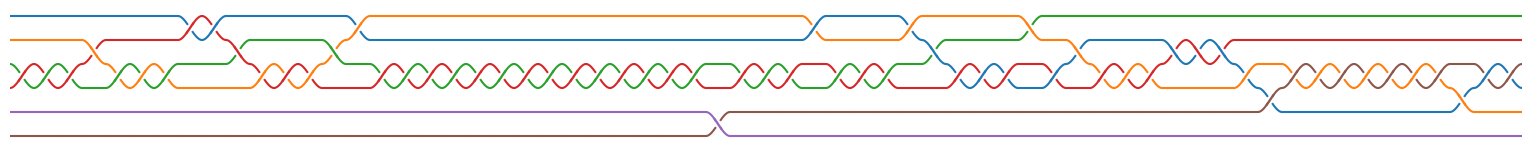

,Rank,Length,Word,RawTotalError
0,1,63,7771777551777157777777777777747775777517770717...,0.008932


Publication PDF: /Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fibonacci_compiler_outputs/braid_selected_candidate.pdf
High-resolution PNG: /Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fibonacci_compiler_outputs/braid_selected_candidate.png


In [32]:
SELECTED_RANK = 1
INCHES_PER_CROSSING = 0.24
COLOUR_STRANDS = True

BRAID_PDF_PATH = OUTPUT_DIRECTORY / "braid_selected_candidate.pdf"
BRAID_PNG_PATH = OUTPUT_DIRECTORY / "braid_selected_candidate.png"

selected_index = int(SELECTED_RANK) - 1
if not 0 <= selected_index < len(publication_operators):
    raise IndexError(
        f"SELECTED_RANK must lie between 1 and {len(publication_operators)}."
    )

selected_gate = publication_operators.iloc[selected_index]
word = str(selected_gate["Word"]).strip()
reported_length = int(selected_gate["Length"])
raw_total_error = float(selected_gate["RawTotalError"])

if not word or not word.isdigit():
    raise ValueError("The selected braid word must be a nonempty digit string.")
if any(int(character) >= len(BRAID_GATES) for character in word):
    raise ValueError("The selected braid word contains an unavailable action.")
if len(word) != reported_length:
    raise ValueError(
        "The reported braid length does not equal the complete word length."
    )

def get_strand_colours(
    number_of_strands: int = 6,
    coloured: bool = True,
) -> list[str]:
    """
    Assign one fixed colour to each physical strand.
    """
    if not coloured:
        return ["black"] * number_of_strands

    colour_cycle = (
        plt.rcParams["axes.prop_cycle"]
        .by_key()
        .get("color", [])
    )

    if not colour_cycle:
        colour_cycle = [
            f"C{index}"
            for index in range(number_of_strands)
        ]

    return [
        colour_cycle[
            index % len(colour_cycle)
        ]
        for index in range(number_of_strands)
    ]


def draw_horizontal_braid(
    operator_word: str,
    *,
    inches_per_crossing: float = 0.24,
    coloured: bool = True,
) -> plt.Figure:
    """
    Draw a six-strand braid as one continuous horizontal diagram.

    The operator word is read from left to right.

    Action encoding
    ---------------
    0,...,4:
        sigma_1,...,sigma_5

    5,...,9:
        sigma_1^{-1},...,sigma_5^{-1}

    Positive generator:
        the strand entering from above passes over.

    Inverse generator:
        the strand entering from below passes over.
    """
    actions = [
        int(character)
        for character in operator_word
    ]

    number_of_actions = len(actions)
    number_of_strands = 6

    if number_of_actions == 0:
        raise ValueError(
            "Cannot draw an empty braid word."
        )

    if inches_per_crossing <= 0.0:
        raise ValueError(
            "INCHES_PER_CROSSING must be positive."
        )

    figure_width = max(
        10.0,
        inches_per_crossing * number_of_actions,
    )

    # The title and endpoint labels have been removed, so the
    # vertical canvas can be kept close to the six braid strands.
    figure_height = 1.8

    figure, axis = plt.subplots(
        figsize=(
            figure_width,
            figure_height,
        )
    )

    strand_colours = get_strand_colours(
        number_of_strands,
        coloured=coloured,
    )

    # order[position] is the identity of the strand currently
    # occupying that vertical position.
    order = list(
        range(number_of_strands)
    )

    interpolation_parameter = np.linspace(
        0.0,
        1.0,
        161,
    )

    # Smooth cubic interpolation with horizontal tangents.
    smooth_step = (
        3.0 * interpolation_parameter**2
        - 2.0 * interpolation_parameter**3
    )

    background_colour = axis.get_facecolor()
    line_width = 1.5

    for action_index, action in enumerate(actions):
        if not 0 <= action <= 9:
            raise ValueError(
                f"Invalid braid action: {action}"
            )

        is_positive = action < 5

        generator_index = (
            action
            if is_positive
            else action - 5
        )

        upper_position = generator_index
        lower_position = generator_index + 1

        upper_strand = order[upper_position]
        lower_strand = order[lower_position]

        x_start = float(action_index)

        x_values = (
            x_start
            + interpolation_parameter
        )

        # Draw the four unaffected strands as straight segments.
        for position, strand_identity in enumerate(order):
            if position in {
                upper_position,
                lower_position,
            }:
                continue

            axis.plot(
                [
                    x_start,
                    x_start + 1.0,
                ],
                [
                    position,
                    position,
                ],
                linewidth=line_width,
                color=strand_colours[
                    strand_identity
                ],
                solid_capstyle="round",
                zorder=1,
            )

        # The upper incoming strand moves downward.
        upper_trajectory = (
            upper_position
            + smooth_step
        )

        # The lower incoming strand moves upward.
        lower_trajectory = (
            lower_position
            - smooth_step
        )

        axis.plot(
            x_values,
            upper_trajectory,
            linewidth=line_width,
            color=strand_colours[
                upper_strand
            ],
            solid_capstyle="round",
            zorder=2,
        )

        axis.plot(
            x_values,
            lower_trajectory,
            linewidth=line_width,
            color=strand_colours[
                lower_strand
            ],
            solid_capstyle="round",
            zorder=2,
        )

        if is_positive:
            over_trajectory = upper_trajectory
            under_trajectory = lower_trajectory
            over_strand = upper_strand
        else:
            over_trajectory = lower_trajectory
            under_trajectory = upper_trajectory
            over_strand = lower_strand

        # Erase a small portion of the undercrossing.
        under_gap = (
            (
                interpolation_parameter
                >= 0.41
            )
            & (
                interpolation_parameter
                <= 0.59
            )
        )

        axis.plot(
            x_values[under_gap],
            under_trajectory[under_gap],
            linewidth=line_width + 4.2,
            color=background_colour,
            solid_capstyle="butt",
            zorder=3,
        )

        # Redraw the overcrossing above the erased segment.
        over_segment = (
            (
                interpolation_parameter
                >= 0.36
            )
            & (
                interpolation_parameter
                <= 0.64
            )
        )

        axis.plot(
            x_values[over_segment],
            over_trajectory[over_segment],
            linewidth=line_width + 0.15,
            color=strand_colours[
                over_strand
            ],
            solid_capstyle="round",
            zorder=4,
        )

        # Both sigma_i and sigma_i^{-1} exchange positions.
        (
            order[upper_position],
            order[lower_position],
        ) = (
            order[lower_position],
            order[upper_position],
        )

    # Display only the braid itself.
    axis.set_xlim(
        0.0,
        float(number_of_actions),
    )

    axis.set_ylim(
        number_of_strands - 0.25,
        -0.25,
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    axis.axis("off")

    # Remove the unused exterior canvas. Do not call tight_layout(),
    # because it may reintroduce padding around the axes.
    figure.subplots_adjust(
        left=0.0,
        right=1.0,
        bottom=0.0,
        top=1.0,
    )

    return figure

braid_figure = draw_horizontal_braid(
    word,
    inches_per_crossing=INCHES_PER_CROSSING,
    coloured=COLOUR_STRANDS,
)

braid_figure.savefig(
    BRAID_PDF_PATH,
    bbox_inches="tight",
    pad_inches=0.01,
)
braid_figure.savefig(
    BRAID_PNG_PATH,
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.01,
)
plt.show()

selected_summary = pd.DataFrame(
    {
        "Rank": [SELECTED_RANK],
        "Length": [reported_length],
        "Word": [word],
        "RawTotalError": [raw_total_error],
    }
)
display(selected_summary)
print("Publication PDF:", BRAID_PDF_PATH.resolve())
print("High-resolution PNG:", BRAID_PNG_PATH.resolve())

## 4.4 Fixed-budget certified-quality comparison

For each independent run, define

\[
Q(B)=\min\{e_{\mathrm{raw}}:\text{a certified gate is found within budget }B\}.
\]

The empirical attainment curve reports \(\Pr[Q(B)\le q]\) for the learned pipeline and an inverse-free random-search baseline under the same gate-score budget. Runs with no certified gate are assigned \(Q(B)=\infty\). Shaded bands are pointwise 95% Wilson intervals.

### 4.4.1 Analysis configuration and input tables

In [33]:
from pathlib import Path
from time import perf_counter
import hashlib
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from tqdm.auto import tqdm
except ImportError as error:
    raise ImportError(
        "This cell requires tqdm for the progress display. "
        "Run `%pip install tqdm` in a notebook cell and try again."
    ) from error


CELL_START_TIME = perf_counter()


# Analysis controls

# Use 20 for a preliminary plot.
# Use at least 100 for the final paper analysis.
RANDOM_QUALITY_RUNS = 100

RANDOM_QUALITY_BASE_SEED = 1_310_000

# Delete or ignore an existing random-search cache and rerun all
# random campaigns.
FORCE_RECOMPUTE_RANDOM_BASELINE = False

FIGURE_DPI = 600
FIGURE_SIZE = (3.5, 3.05)

# Minimum time, in seconds, between progress-bar redraws.
PROGRESS_REFRESH_SECONDS = 0.5

QUALITY_OUTPUT_DIRECTORY = Path(OUTPUT_DIRECTORY)

QUALITY_OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

QUALITY_PDF_PATH = QUALITY_OUTPUT_DIRECTORY / "hybrid_fixed_budget_quality_attainment.pdf"

QUALITY_PNG_PATH = QUALITY_OUTPUT_DIRECTORY / "hybrid_fixed_budget_quality_attainment.png"

QUALITY_RUNS_CSV_PATH = (
    QUALITY_OUTPUT_DIRECTORY
    / "hybrid_fixed_budget_quality_runs.csv"
)

QUALITY_SUMMARY_CSV_PATH = (
    QUALITY_OUTPUT_DIRECTORY
    / "hybrid_fixed_budget_quality_summary.csv"
)

QUALITY_BUDGET_CSV_PATH = (
    QUALITY_OUTPUT_DIRECTORY
    / "hybrid_fixed_budget_by_seed.csv"
)


QUALITY_X_LIMITS = (0.014, 0.13)
QUALITY_TICKS = (0.02, 0.03, 0.05, 0.07, 0.10)

### 4.4.2 Loading, parsing, and budget helpers

In [34]:
def format_duration(seconds):
    """Format an elapsed duration compactly."""
    seconds = max(0, int(round(float(seconds))))

    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    if hours:
        return f"{hours:d} h {minutes:02d} min {seconds:02d} s"

    if minutes:
        return f"{minutes:d} min {seconds:02d} s"

    return f"{seconds:d} s"


# Validate the mathematical objects needed for random search

required_mathematical_objects = [
    "CONFIG",
    "REFINEMENT_CONFIG",
    "BRAID_GATES",
    "INVERSE_ACTION",
    "compute_gate_metrics",
    "is_success",
    "perfect_entangler_diagnostics",
]

missing_mathematical_objects = [
    name
    for name in required_mathematical_objects
    if name not in globals()
]

if missing_mathematical_objects:
    raise RuntimeError(
        "Run the mathematical definitions and experiment-configuration "
        "cells before this cell. Missing objects:\n"
        + ", ".join(missing_mathematical_objects)
    )


# Load the result tables

def load_result_table(global_name, filename):
    """
    Return an in-memory DataFrame when available; otherwise
    load the corresponding exported CSV.
    """
    value = globals().get(global_name)

    if isinstance(value, pd.DataFrame):
        return value.copy()

    path = QUALITY_OUTPUT_DIRECTORY / filename

    if not path.is_file():
        raise FileNotFoundError(
            f"Neither the in-memory table '{global_name}' nor its "
            f"exported CSV could be found:\n{path.resolve()}"
        )

    return read_csv_preserving_braid_words(path)


print("Loading learned-policy and refinement records...")

policy_frame = load_result_table(
    "policy_episodes",
    "hybrid_policy_episodes_all_seeds.csv",
)

refinement_frame = load_result_table(
    "refinement_results",
    "hybrid_refinement_results_all_seeds.csv",
)

progress_frame = load_result_table(
    "refinement_progress",
    "hybrid_refinement_progress_all_seeds.csv",
)

for frame in (
    policy_frame,
    refinement_frame,
    progress_frame,
):
    frame.columns = (
        frame.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )


# Parsing helpers

def boolean_series(series):
    """Convert common CSV Boolean encodings to Boolean values."""
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(
            {
                "true",
                "1",
                "yes",
                "y",
                "t",
            }
        )
    )


def clean_word(value):
    """
    Convert a CSV word field to a validated digit string.
    Missing values become the empty string.
    """
    if pd.isna(value):
        return ""

    word = str(value).strip()

    if word.lower() in {
        "",
        "nan",
        "none",
        "<na>",
    }:
        return ""

    if not word.isdigit():
        raise ValueError(
            "Encountered a braid word containing non-digit "
            f"characters: {word!r}"
        )

    if any(
        int(character) >= len(BRAID_GATES)
        for character in word
    ):
        raise ValueError(
            "Encountered a braid action outside the available "
            f"alphabet: {word!r}"
        )

    return word

if "TRAINING_SEEDS" in globals():
    learned_seeds = sorted(
        {
            int(seed)
            for seed in TRAINING_SEEDS
        }
    )
else:
    if "Seed" not in policy_frame.columns:
        raise KeyError(
            "The policy-evaluation table has no 'Seed' column, "
            "and TRAINING_SEEDS is unavailable."
        )

    learned_seeds = sorted(
        pd.to_numeric(
            policy_frame["Seed"],
            errors="raise",
        )
        .astype(int)
        .unique()
        .tolist()
    )

if not learned_seeds:
    raise RuntimeError(
        "No trained seeds were found."
    )

print(
    f"Detected {len(learned_seeds)} independently trained seed(s): "
    + ", ".join(map(str, learned_seeds))
)


# Per-seed training budget

def training_overhead_for_seed(seed):
    """
    Sum the gate-score evaluations charged during global
    discovery for one trained seed.
    """
    seed = int(seed)
    budget_frame = None

    in_memory_budgets = globals().get(
        "TRAINING_BUDGETS"
    )

    if isinstance(in_memory_budgets, dict):
        budget_frame = in_memory_budgets.get(seed)

        if budget_frame is None:
            budget_frame = in_memory_budgets.get(
                str(seed)
            )

    if budget_frame is None:
        budget_path = (
            QUALITY_OUTPUT_DIRECTORY
            / f"hybrid_gate_score_budget_seed_{seed}.csv"
        )

        if not budget_path.is_file():
            raise FileNotFoundError(
                "The training gate-score ledger is unavailable "
                f"for seed {seed}:\n{budget_path.resolve()}"
            )

        budget_frame = read_csv_preserving_braid_words(
            budget_path
        )

    if not isinstance(
        budget_frame,
        pd.DataFrame,
    ):
        budget_frame = pd.DataFrame(
            budget_frame
        )

    budget_frame = budget_frame.copy()

    budget_frame.columns = (
        budget_frame.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )

    if (
        "GateScoreEvaluations"
        not in budget_frame.columns
    ):
        raise KeyError(
            f"The training ledger for seed {seed} has no "
            "'GateScoreEvaluations' column.\n"
            "Available columns: "
            + ", ".join(budget_frame.columns)
        )

    evaluations = pd.to_numeric(
        budget_frame["GateScoreEvaluations"],
        errors="coerce",
    ).fillna(0)

    if (evaluations < 0).any():
        raise ValueError(
            "The training ledger contains negative gate-score "
            f"counts for seed {seed}."
        )

    return int(evaluations.sum())


# Policy-evaluation and refinement budgets

evaluation_horizon = int(
    CONFIG.global_max_sequence_length
)

number_of_evaluation_environments = int(
    globals().get(
        "EVALUATION_NUM_ENVS",
        8,
    )
)


def policy_budget_for_seed(seed):
    """
    Total gate-score calls made during identity-start policy
    evaluation for one seed.
    """
    seed_rows = policy_frame.loc[
        pd.to_numeric(
            policy_frame["Seed"],
            errors="coerce",
        )
        .fillna(-1)
        .astype(int)
        .eq(int(seed))
    ]

    if seed_rows.empty:
        raise RuntimeError(
            f"No policy-evaluation rows were found for seed {seed}."
        )

    if (
        "GateScoreEvaluations"
        in seed_rows.columns
    ):
        score_counts = pd.to_numeric(
            seed_rows["GateScoreEvaluations"],
            errors="coerce",
        )

        if score_counts.notna().all():
            return int(score_counts.sum())

    return int(
        len(seed_rows)
        * evaluation_horizon
    )


def refinement_budget_for_seed(seed):
    """
    Total refinement score calls available for one seed.
    """
    seed = int(seed)

    if (
        not progress_frame.empty
        and {
            "Seed",
            "CandidatesEvaluated",
        }.issubset(progress_frame.columns)
    ):
        seed_progress = progress_frame.loc[
            pd.to_numeric(
                progress_frame["Seed"],
                errors="coerce",
            )
            .fillna(-1)
            .astype(int)
            .eq(seed)
        ]

        if not seed_progress.empty:
            counts = pd.to_numeric(
                seed_progress["CandidatesEvaluated"],
                errors="coerce",
            ).dropna()

            if not counts.empty:
                return int(counts.max())

    if {
        "Seed",
        "EvaluationsUsed",
    }.issubset(refinement_frame.columns):
        seed_results = refinement_frame.loc[
            pd.to_numeric(
                refinement_frame["Seed"],
                errors="coerce",
            )
            .fillna(-1)
            .astype(int)
            .eq(seed)
        ]

        if not seed_results.empty:
            counts = pd.to_numeric(
                seed_results["EvaluationsUsed"],
                errors="coerce",
            ).dropna()

            if not counts.empty:
                return int(counts.max())

    return 0

Loading learned-policy and refinement records...
Detected 6 independently trained seed(s): 0, 1, 2, 3, 4, 5


### 4.4.3 Construct the common gate-score budget

In [35]:
print("Computing the common gate-score budget...")

budget_records = []

for seed in tqdm(
    learned_seeds,
    desc="Budget ledgers",
    unit="seed",
    dynamic_ncols=True,
    mininterval=PROGRESS_REFRESH_SECONDS,
):
    training_cost = (
        training_overhead_for_seed(seed)
    )

    policy_cost = (
        policy_budget_for_seed(seed)
    )

    refinement_cost = (
        refinement_budget_for_seed(seed)
    )

    budget_records.append(
        {
            "Seed": seed,
            "TrainingEvaluations": training_cost,
            "PolicyEvaluationEvaluations": policy_cost,
            "RefinementEvaluations": refinement_cost,
            "CompletePipelineBudget": (
                training_cost
                + policy_cost
                + refinement_cost
            ),
        }
    )

budget_table = pd.DataFrame.from_records(
    budget_records
)

if budget_table.empty:
    raise RuntimeError(
        "The per-seed budget table is empty."
    )

common_fixed_budget = int(
    budget_table[
        "CompletePipelineBudget"
    ].min()
)

if common_fixed_budget <= 0:
    raise ValueError(
        "The computed common budget is not positive."
    )

budget_table[
    "CommonFixedBudget"
] = common_fixed_budget

budget_table.to_csv(
    QUALITY_BUDGET_CSV_PATH,
    index=False,
)

print(
    "\nCommon fixed budget:",
    f"{common_fixed_budget:,}",
    "gate-score evaluations per independent run.",
)

display(budget_table)

Computing the common gate-score budget...


Budget ledgers:   0%|          | 0/6 [00:00<?, ?seed/s]


Common fixed budget: 1,253,457 gate-score evaluations per independent run.


,Seed,TrainingEvaluations,PolicyEvaluationEvaluations,RefinementEvaluations,CompletePipelineBudget,CommonFixedBudget
0,0,1058594,200320,181552,1440466,1253457
1,1,893278,200320,206928,1300526,1253457
2,2,888744,200320,186777,1275841,1253457
3,3,950909,200320,235043,1386272,1253457
4,4,922477,200320,213788,1336585,1253457
5,5,834144,200320,218993,1253457,1253457


### 4.4.4 Certification and learned-pipeline quality

In [36]:
certified_word_cache = {}


def certified_metrics_for_word(word):
    """
    Recompose a word and return its metrics only when it passes
    threshold success and perfect-entangler certification.
    """
    word = clean_word(word)

    if not word:
        return None

    if word in certified_word_cache:
        return certified_word_cache[word]

    matrix_dimension = int(
        np.asarray(
            BRAID_GATES[0]
        ).shape[0]
    )

    composition = np.eye(
        matrix_dimension,
        dtype=np.complex128,
    )

    for character in word:
        action = int(character)

        composition = (
            composition
            @ BRAID_GATES[action]
        )

    metrics = compute_gate_metrics(
        composition,
        config=CONFIG,
    )

    if not is_success(
        metrics,
        config=CONFIG,
    ):
        certified_word_cache[word] = None
        return None

    # Actual return order:
    # perfect_entangler, robust_interior, signed_margin
    perfect_entangler, robust, margin = (
        perfect_entangler_diagnostics(
            composition,
            robust_margin_threshold=(
                REFINEMENT_CONFIG
                .perfect_entangler_margin_threshold
            ),
        )
    )

    if not perfect_entangler:
        certified_word_cache[word] = None
        return None

    result = {
        "RawTotalError": float(
            metrics.raw_total_error
        ),
        "ProbabilityLeakage": float(
            metrics.probability_leakage
        ),
        "RawMakhlinError": float(
            metrics.raw_makhlin_error
        ),
        "PerfectEntanglerMargin": float(
            margin
        ),
        "RobustlyCertified": bool(
            robust
        ),
    }

    certified_word_cache[word] = result

    return result


# Best learned quality within the common budget

print("\nExtracting the best learned certified quality for each seed...")

learned_quality_records = []

for seed in tqdm(
    learned_seeds,
    desc="Learned runs",
    unit="seed",
    dynamic_ncols=True,
    mininterval=PROGRESS_REFRESH_SECONDS,
):
    seed = int(seed)

    seed_budget_row = (
        budget_table.loc[
            budget_table["Seed"].eq(seed)
        ]
        .iloc[0]
    )

    training_cost = int(
        seed_budget_row["TrainingEvaluations"]
    )

    policy_cost = int(
        seed_budget_row[
            "PolicyEvaluationEvaluations"
        ]
    )

    seed_policy = (
        policy_frame.loc[
            pd.to_numeric(
                policy_frame["Seed"],
                errors="coerce",
            )
            .fillna(-1)
            .astype(int)
            .eq(seed)
        ]
        .reset_index(drop=True)
    )

    if seed_policy.empty:
        raise RuntimeError(
            f"No policy-evaluation rows were found for seed {seed}."
        )

    if (
        len(seed_policy)
        % number_of_evaluation_environments
        != 0
    ):
        raise ValueError(
            f"Seed {seed} does not contain a complete number "
            "of vectorised evaluation batches."
        )

    best_error = np.inf
    best_word = ""
    best_source = ""
    evaluations_at_best = np.nan

    training_solution_archives = globals().get(
        "TRAINING_SOLUTIONS"
    )
    training_solutions = None
    if isinstance(training_solution_archives, dict):
        training_solutions = training_solution_archives.get(seed)
        if training_solutions is None:
            training_solutions = training_solution_archives.get(str(seed))

    if training_solutions is None:
        training_solution_path = solution_path_for_seed(seed)
        if not training_solution_path.is_file():
            raise FileNotFoundError(
                "The training solution archive is unavailable for "
                f"seed {seed}:\n{training_solution_path.resolve()}"
            )
        training_solutions = load_solution_archive_from_csv(
            training_solution_path
        )

    for solution in training_solutions.to_frame().itertuples(index=False):
        word = clean_word(solution.word)
        candidate_metrics = certified_metrics_for_word(word)
        if candidate_metrics is None:
            continue

        candidate_error = float(candidate_metrics["RawTotalError"])
        if (
            training_cost <= common_fixed_budget
            and candidate_error < best_error
        ):
            best_error = candidate_error
            best_word = word
            best_source = "global discovery"
            # The archive does not record an exact insertion evaluation.
            # Charging the full training budget is conservative and valid.
            evaluations_at_best = training_cost

    policy_candidate_pairs = [
        (
            "BestSuccessfulWord",
            "BestSuccessfulLength",
            "policy best-success prefix",
        ),
        (
            "FirstCertifiedWord",
            "FirstCertifiedLength",
            "policy first-certified prefix",
        ),
        (
            "BestCertifiedWord",
            "BestCertifiedLength",
            "policy best-certified prefix",
        ),
    ]

    for row_index, row in seed_policy.iterrows():
        batch_index = (
            row_index
            // number_of_evaluation_environments
        )

        completed_previous_batches = (
            batch_index
            * number_of_evaluation_environments
            * evaluation_horizon
        )

        for (
            word_column,
            length_column,
            source_label,
        ) in policy_candidate_pairs:
            if (
                word_column not in seed_policy.columns
                or length_column not in seed_policy.columns
            ):
                continue

            word = clean_word(
                row.get(
                    word_column,
                    "",
                )
            )

            if not word:
                continue

            try:
                prefix_length = int(
                    float(
                        row.get(
                            length_column,
                            -1,
                        )
                    )
                )
            except (
                TypeError,
                ValueError,
            ):
                continue

            if (
                prefix_length
                < CONFIG.minimum_eligible_prefix_length
            ):
                continue

            policy_relative_cost = (
                completed_previous_batches
                + prefix_length
                * number_of_evaluation_environments
            )

            absolute_cost = (
                training_cost
                + policy_relative_cost
            )

            if (
                absolute_cost
                > common_fixed_budget
            ):
                continue

            candidate_metrics = (
                certified_metrics_for_word(word)
            )

            if candidate_metrics is None:
                continue

            candidate_error = float(
                candidate_metrics[
                    "RawTotalError"
                ]
            )

            if candidate_error < best_error:
                best_error = candidate_error
                best_word = word
                best_source = source_label
                evaluations_at_best = int(
                    absolute_cost
                )

    required_refinement_columns = {
        "Seed",
        "Certified",
        "RawTotalError",
        "EvaluationsUsed",
        "Word",
    }

    if required_refinement_columns.issubset(
        refinement_frame.columns
    ):
        seed_refinement = (
            refinement_frame.loc[
                pd.to_numeric(
                    refinement_frame["Seed"],
                    errors="coerce",
                )
                .fillna(-1)
                .astype(int)
                .eq(seed)
                & boolean_series(
                    refinement_frame["Certified"]
                )
            ]
            .copy()
        )

        if not seed_refinement.empty:
            seed_refinement[
                "RawTotalError"
            ] = pd.to_numeric(
                seed_refinement[
                    "RawTotalError"
                ],
                errors="coerce",
            )

            seed_refinement[
                "EvaluationsUsed"
            ] = pd.to_numeric(
                seed_refinement[
                    "EvaluationsUsed"
                ],
                errors="coerce",
            )

            seed_refinement = (
                seed_refinement.dropna(
                    subset=[
                        "RawTotalError",
                        "EvaluationsUsed",
                    ]
                )
            )

            seed_refinement[
                "AbsoluteEvaluations"
            ] = (
                training_cost
                + policy_cost
                + seed_refinement[
                    "EvaluationsUsed"
                ]
            )

            seed_refinement = (
                seed_refinement.loc[
                    seed_refinement[
                        "AbsoluteEvaluations"
                    ].le(common_fixed_budget)
                ]
            )

            if not seed_refinement.empty:
                best_refinement_row = (
                    seed_refinement.loc[
                        seed_refinement[
                            "RawTotalError"
                        ].idxmin()
                    ]
                )

                refinement_error = float(
                    best_refinement_row[
                        "RawTotalError"
                    ]
                )

                if refinement_error < best_error:
                    best_error = refinement_error

                    best_word = clean_word(
                        best_refinement_row["Word"]
                    )

                    best_source = (
                        "frozen suffix refinement"
                    )

                    evaluations_at_best = int(
                        best_refinement_row[
                            "AbsoluteEvaluations"
                        ]
                    )

    learned_quality_records.append(
        {
            "Method": (
                "QD-PPO + suffix refinement"
            ),
            "Run": seed,
            "FixedBudget": common_fixed_budget,
            "CertifiedGateFound": bool(
                np.isfinite(best_error)
            ),
            "BestCertifiedRawTotalError": (
                best_error
                if np.isfinite(best_error)
                else np.nan
            ),
            "BestWord": best_word,
            "BestSource": best_source,
            "EvaluationsAtBest": (
                evaluations_at_best
                if np.isfinite(evaluations_at_best)
                else np.nan
            ),
        }
    )

learned_quality_runs = (
    pd.DataFrame.from_records(
        learned_quality_records
    )
)


Extracting the best learned certified quality for each seed...


Learned runs:   0%|          | 0/6 [00:00<?, ?seed/s]

### 4.4.5 Inverse-free random-search baseline

In [37]:
legal_actions_after = {
    previous_action: np.asarray(
        [
            action
            for action in range(
                len(BRAID_GATES)
            )
            if action
            != INVERSE_ACTION[
                previous_action
            ]
        ],
        dtype=int,
    )
    for previous_action in range(
        len(BRAID_GATES)
    )
}


def run_random_quality_campaign(
    *,
    seed,
    maximum_evaluations,
    progress_bar=None,
):
    """
    Run one inverse-free random campaign through the full fixed
    budget and retain the best certified gate encountered.

    The progress bar is updated after each complete random
    episode rather than after every matrix multiplication,
    avoiding excessive display overhead.
    """
    rng = np.random.default_rng(
        int(seed)
    )

    maximum_evaluations = int(
        maximum_evaluations
    )

    matrix_dimension = int(
        np.asarray(
            BRAID_GATES[0]
        ).shape[0]
    )

    evaluations = 0
    best_error = np.inf
    best_word = ""
    evaluations_at_best = np.nan
    certified_candidates = 0

    while evaluations < maximum_evaluations:
        composition = np.eye(
            matrix_dimension,
            dtype=np.complex128,
        )

        actions = []

        episode_length = min(
            evaluation_horizon,
            maximum_evaluations
            - evaluations,
        )

        episode_start_evaluations = evaluations

        for _ in range(episode_length):
            if actions:
                action = int(
                    rng.choice(
                        legal_actions_after[
                            actions[-1]
                        ]
                    )
                )
            else:
                action = int(
                    rng.integers(
                        len(BRAID_GATES)
                    )
                )

            actions.append(action)

            composition = (
                composition
                @ BRAID_GATES[action]
            )

            evaluations += 1

            metrics = compute_gate_metrics(
                composition,
                config=CONFIG,
            )

            if (
                len(actions)
                < CONFIG.minimum_eligible_prefix_length
            ):
                continue

            if not is_success(
                metrics,
                config=CONFIG,
            ):
                continue

            perfect_entangler, _, _ = (
                perfect_entangler_diagnostics(
                    composition,
                    robust_margin_threshold=(
                        REFINEMENT_CONFIG
                        .perfect_entangler_margin_threshold
                    ),
                )
            )

            if not perfect_entangler:
                continue

            certified_candidates += 1

            candidate_error = float(
                metrics.raw_total_error
            )

            if candidate_error < best_error:
                best_error = candidate_error

                best_word = "".join(
                    str(value)
                    for value in actions
                )

                evaluations_at_best = int(
                    evaluations
                )

        if progress_bar is not None:
            progress_bar.update(
                evaluations
                - episode_start_evaluations
            )

    return {
        "CertifiedGateFound": bool(
            np.isfinite(best_error)
        ),
        "BestCertifiedRawTotalError": (
            best_error
            if np.isfinite(best_error)
            else np.nan
        ),
        "BestWord": best_word,
        "BestSource": (
            "inverse-free random search"
        ),
        "EvaluationsAtBest": (
            evaluations_at_best
            if np.isfinite(evaluations_at_best)
            else np.nan
        ),
        "CertifiedCandidatesEncountered": int(
            certified_candidates
        ),
    }

### 4.4.6 Fingerprinted cache and random campaigns

In [38]:
gate_array = np.ascontiguousarray(
    np.stack(BRAID_GATES)
)

gate_digest = hashlib.sha256(
    gate_array
    .view(np.float64)
    .tobytes()
).hexdigest()

random_cache_payload = {
    "analysis": (
        "fixed-budget certified-quality attainment"
    ),
    "common_fixed_budget": int(
        common_fixed_budget
    ),
    "random_runs": int(
        RANDOM_QUALITY_RUNS
    ),
    "random_base_seed": int(
        RANDOM_QUALITY_BASE_SEED
    ),
    "global_max_sequence_length": int(
        CONFIG.global_max_sequence_length
    ),
    "minimum_eligible_prefix_length": int(
        CONFIG.minimum_eligible_prefix_length
    ),
    "success_retention_threshold": float(
        CONFIG.success_retention_threshold
    ),
    "success_makhlin_threshold": float(
        CONFIG.success_makhlin_threshold
    ),
    "leakage_weight": float(
        CONFIG.leakage_weight
    ),
    "makhlin_weight": float(
        CONFIG.makhlin_weight
    ),
    "determinant_regularization": float(
        CONFIG.determinant_regularization
    ),
    "determinant_regularization_mode": str(
        CONFIG.determinant_regularization_mode
    ),
    "robust_margin_threshold": float(
        REFINEMENT_CONFIG
        .perfect_entangler_margin_threshold
    ),
    "inverse_action": {
        str(key): int(value)
        for key, value in INVERSE_ACTION.items()
    },
    "braid_gate_sha256": gate_digest,
}

random_cache_digest = (
    hashlib.sha256(
        json.dumps(
            random_cache_payload,
            sort_keys=True,
            default=str,
        ).encode("utf-8")
    )
    .hexdigest()[:20]
)

random_cache_path = (
    QUALITY_OUTPUT_DIRECTORY
    / (
        "hybrid_random_fixed_budget_quality_"
        f"{random_cache_digest}.csv"
    )
)

random_cache_metadata_path = (
    QUALITY_OUTPUT_DIRECTORY
    / (
        "hybrid_random_fixed_budget_quality_"
        f"{random_cache_digest}.json"
    )
)


# Run or load random campaigns

if (
    random_cache_path.is_file()
    and not FORCE_RECOMPUTE_RANDOM_BASELINE
):
    random_quality_runs = read_csv_preserving_braid_words(
        random_cache_path,
        dtype={
            "BestWord": str,
        },
    )

    if (
        len(random_quality_runs)
        != RANDOM_QUALITY_RUNS
    ):
        raise RuntimeError(
            "The cached random baseline contains an unexpected "
            "number of campaigns."
        )

    cached_budgets = pd.to_numeric(
        random_quality_runs["FixedBudget"],
        errors="coerce",
    )

    if not cached_budgets.eq(
        common_fixed_budget
    ).all():
        raise RuntimeError(
            "The cached random baseline uses a different "
            "fixed budget."
        )

    print(
        "\nLoaded cached random campaigns; no random recomputation "
        "is necessary:"
    )
    print(random_cache_path.resolve())

else:
    random_records = []

    total_random_evaluations = (
        int(RANDOM_QUALITY_RUNS)
        * int(common_fixed_budget)
    )

    print(
        "\nStarting inverse-free random baseline:"
    )
    print(
        f"  campaigns:             {RANDOM_QUALITY_RUNS:,}"
    )
    print(
        f"  evaluations/campaign:  {common_fixed_budget:,}"
    )
    print(
        f"  total evaluations:     {total_random_evaluations:,}"
    )
    print(
        "The ETA will become more stable after the first several "
        "random episodes."
    )

    random_phase_start = perf_counter()

    with tqdm(
        total=total_random_evaluations,
        desc="Random baseline",
        unit="score",
        unit_scale=True,
        dynamic_ncols=True,
        mininterval=PROGRESS_REFRESH_SECONDS,
        smoothing=0.05,
        leave=True,
    ) as random_progress:
        for run_index in range(
            RANDOM_QUALITY_RUNS
        ):
            campaign = (
                run_random_quality_campaign(
                    seed=(
                        RANDOM_QUALITY_BASE_SEED
                        + run_index
                    ),
                    maximum_evaluations=(
                        common_fixed_budget
                    ),
                    progress_bar=random_progress,
                )
            )

            random_records.append(
                {
                    "Method": (
                        "Inverse-free random search"
                    ),
                    "Run": run_index,
                    "FixedBudget": (
                        common_fixed_budget
                    ),
                    **campaign,
                }
            )

            completed_runs = run_index + 1

            completed_frame = (
                pd.DataFrame.from_records(
                    random_records
                )
            )

            hit_count = int(
                completed_frame[
                    "CertifiedGateFound"
                ].sum()
            )

            finite_errors = pd.to_numeric(
                completed_frame[
                    "BestCertifiedRawTotalError"
                ],
                errors="coerce",
            ).dropna()

            best_so_far = (
                float(finite_errors.min())
                if not finite_errors.empty
                else np.nan
            )

            best_text = (
                f"{best_so_far:.4g}"
                if np.isfinite(best_so_far)
                else "none"
            )

            random_progress.set_postfix(
                {
                    "campaign": (
                        f"{completed_runs}/"
                        f"{RANDOM_QUALITY_RUNS}"
                    ),
                    "certified": hit_count,
                    "best_e_raw": best_text,
                },
                refresh=True,
            )

    random_phase_elapsed = (
        perf_counter()
        - random_phase_start
    )

    print(
        "Random baseline completed in "
        f"{format_duration(random_phase_elapsed)}."
    )

    random_quality_runs = (
        pd.DataFrame.from_records(
            random_records
        )
    )

    random_quality_runs.to_csv(
        random_cache_path,
        index=False,
    )

    random_cache_metadata_path.write_text(
        json.dumps(
            random_cache_payload,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )

    print(
        "Cached random campaigns:"
    )
    print(
        random_cache_path.resolve()
    )


Starting inverse-free random baseline:
  campaigns:             100
  evaluations/campaign:  1,253,457
  total evaluations:     125,345,700
The ETA will become more stable after the first several random episodes.


Random baseline:   0%|          | 0.00/125M [00:00<?, ?score/s]

/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/0xca7/Library/Python/3.9/lib/python/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Random baseline completed in 50 min 34 s.
Cached random campaigns:
/Users/0xca7/Desktop/Fibonacci/RLTQC/hybrid_fibonacci_compiler_outputs/hybrid_random_fixed_budget_quality_266376d607b011626ccc.csv


### 4.4.7 Assemble independent-run records

In [39]:
quality_runs = pd.concat(
    [
        learned_quality_runs,
        random_quality_runs,
    ],
    ignore_index=True,
    sort=False,
)

quality_runs[
    "BestCertifiedRawTotalError"
] = pd.to_numeric(
    quality_runs[
        "BestCertifiedRawTotalError"
    ],
    errors="coerce",
)

quality_runs.to_csv(
    QUALITY_RUNS_CSV_PATH,
    index=False,
)

### 4.4.8 Attainment estimators and Wilson intervals

In [40]:
def wilson_interval(
    successes,
    trials,
    z_value=1.959963984540054,
):
    """Pointwise Wilson score interval for a binomial proportion."""
    successes = np.asarray(
        successes,
        dtype=float,
    )

    trials = float(trials)

    if trials <= 0:
        raise ValueError(
            "At least one independent run is required."
        )

    proportion = (
        successes
        / trials
    )

    denominator = (
        1.0
        + z_value**2
        / trials
    )

    centre = (
        proportion
        + z_value**2
        / (2.0 * trials)
    ) / denominator

    half_width = (
        z_value
        * np.sqrt(
            proportion
            * (1.0 - proportion)
            / trials
            + z_value**2
            / (4.0 * trials**2)
        )
        / denominator
    )

    return (
        np.clip(
            centre - half_width,
            0.0,
            1.0,
        ),
        np.clip(
            centre + half_width,
            0.0,
            1.0,
        ),
    )


def quality_attainment_curve(
    method_frame,
    quality_grid,
):
    """
    Fraction of independent runs whose best certified error is
    no larger than each quality threshold.
    """
    best_errors = (
        pd.to_numeric(
            method_frame[
                "BestCertifiedRawTotalError"
            ],
            errors="coerce",
        )
        .to_numpy(dtype=float)
    )

    best_errors = np.where(
        np.isfinite(best_errors),
        best_errors,
        np.inf,
    )

    success_counts = np.asarray(
        [
            np.count_nonzero(
                best_errors <= threshold
            )
            for threshold in quality_grid
        ],
        dtype=int,
    )

    estimates = (
        success_counts
        / len(best_errors)
    )

    lower, upper = wilson_interval(
        success_counts,
        len(best_errors),
    )

    return (
        estimates,
        lower,
        upper,
    )

### 4.4.9 Data-driven threshold grid

In [41]:
finite_quality_values = (
    quality_runs["BestCertifiedRawTotalError"]
    .dropna()
    .to_numpy(dtype=float)
)
finite_quality_values = finite_quality_values[
    np.isfinite(finite_quality_values) & (finite_quality_values > 0.0)
]

if finite_quality_values.size == 0:
    raise RuntimeError(
        "No finite certified raw-total-error values are available for plotting."
    )

minimum_quality = max(
    float(finite_quality_values.min()) / 1.25,
    np.finfo(float).tiny,
)
maximum_quality = float(finite_quality_values.max()) * 1.25
if maximum_quality <= minimum_quality:
    minimum_quality = max(
        float(finite_quality_values.min()) / 1.5,
        np.finfo(float).tiny,
    )
    maximum_quality = float(finite_quality_values.max()) * 1.5

quality_grid = np.unique(
    np.concatenate(
        [
            np.logspace(
                math.log10(minimum_quality),
                math.log10(maximum_quality),
                500,
            ),
            finite_quality_values,
            np.asarray(QUALITY_X_LIMITS, dtype=float),
        ]
    )
)
quality_grid.sort()

### 4.4.10 Final publication figure

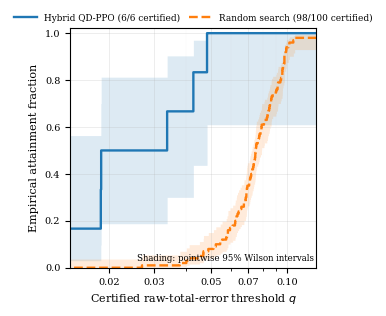

In [42]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

method_specs = [
    {
        "method": "QD-PPO + suffix refinement",
        "short_name": "Hybrid QD-PPO",
        "linestyle": "-",
    },
    {
        "method": "Inverse-free random search",
        "short_name": "Random search",
        "linestyle": "--",
    },
]

with plt.rc_context(
    {
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 6.4,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
):
    figure, axis = plt.subplots(figsize=FIGURE_SIZE)
    plotted_methods = 0

    for specification in method_specs:
        method = specification["method"]
        method_runs = quality_runs.loc[
            quality_runs["Method"].eq(method)
        ]

        if method_runs.empty:
            print(f"Warning: no rows found for method {method!r}.")
            continue

        plotted_methods += 1

        estimate, lower, upper = quality_attainment_curve(
            method_runs,
            quality_grid,
        )

        certified_count = int(
            pd.to_numeric(
                method_runs["BestCertifiedRawTotalError"],
                errors="coerce",
            )
            .notna()
            .sum()
        )
        total_count = int(len(method_runs))

        label = (
            f"{specification['short_name']} "
            f"({certified_count}/{total_count} certified)"
        )

        line, = axis.step(
            quality_grid,
            estimate,
            where="post",
            linewidth=1.7,
            linestyle=specification["linestyle"],
            label=label,
        )

        axis.fill_between(
            quality_grid,
            lower,
            upper,
            step="post",
            alpha=0.15,
            linewidth=0,
            color=line.get_color(),
        )

    if plotted_methods == 0:
        raise RuntimeError(
            "Neither expected method is present in quality_runs."
        )

    # Use a logarithmic quality axis.
    axis.set_xscale("log")
    axis.set_xlim(*QUALITY_X_LIMITS)
    axis.set_ylim(0.0, 1.02)

    # Show only the explicitly selected major tick labels.
    axis.xaxis.set_major_locator(
        FixedLocator(QUALITY_TICKS)
    )
    axis.xaxis.set_major_formatter(
        FuncFormatter(
            lambda value, position: f"{value:.2f}"
        )
    )

    # Keep the logarithmic minor ticks and grid lines, but suppress
    # automatically generated labels such as 4 × 10^{-2}.
    axis.xaxis.set_minor_formatter(
        NullFormatter()
    )
    axis.tick_params(
        axis="x",
        which="minor",
        labelbottom=False,
    )

    axis.set_xlabel(
        r"Certified raw-total-error threshold $q$"
    )
    axis.set_ylabel(
        "Empirical attainment fraction"
    )

    axis.grid(
        True,
        which="major",
        linewidth=0.45,
        alpha=0.35,
    )
    axis.grid(
        True,
        which="minor",
        linewidth=0.25,
        alpha=0.12,
    )

    axis.legend(
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
        ncol=2,
        columnspacing=1.0,
        handlelength=2.6,
        borderaxespad=0.0,
    )

    axis.text(
        0.99,
        0.02,
        "Shading: pointwise 95% Wilson intervals",
        transform=axis.transAxes,
        horizontalalignment="right",
        verticalalignment="bottom",
        fontsize=6.2,
    )

    figure.tight_layout(pad=0.4)

    figure.savefig(
        QUALITY_PDF_PATH,
        bbox_inches="tight",
    )
    figure.savefig(
        QUALITY_PNG_PATH,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    plt.show()

### 4.4.11 Target-free numerical summary and final exports

The summary reports the fraction of independent runs that find any certified gate within the common budget, together with its Wilson interval and the distribution of the best certified raw total error. It does not privilege an arbitrary quality threshold.

In [ ]:
summary_records = []
for method, method_runs in quality_runs.groupby("Method", sort=False):
    errors = pd.to_numeric(
        method_runs["BestCertifiedRawTotalError"],
        errors="coerce",
    )
    certified_mask = errors.notna()
    certified_errors = errors.loc[certified_mask].to_numpy(dtype=float)

    number_of_runs = int(len(method_runs))
    certified_runs = int(certified_mask.sum())
    lower, upper = wilson_interval(
        np.asarray([certified_runs]),
        number_of_runs,
    )

    summary_records.append(
        {
            "Method": method,
            "IndependentRuns": number_of_runs,
            "CertifiedRuns": certified_runs,
            "CertifiedRunFraction": certified_runs / number_of_runs,
            "CertifiedRunWilson95Lower": float(lower[0]),
            "CertifiedRunWilson95Upper": float(upper[0]),
            "MedianBestCertifiedRawTotalError": (
                float(np.median(certified_errors))
                if certified_errors.size
                else np.nan
            ),
            "MinimumCertifiedRawTotalError": (
                float(certified_errors.min())
                if certified_errors.size
                else np.nan
            ),
            "CommonFixedBudget": common_fixed_budget,
        }
    )

quality_summary = pd.DataFrame.from_records(summary_records)
quality_summary.to_csv(QUALITY_SUMMARY_CSV_PATH, index=False)

# The per-run and budget tables are canonical inputs for independent replotting.
quality_runs.to_csv(QUALITY_RUNS_CSV_PATH, index=False)
budget_table.to_csv(QUALITY_BUDGET_CSV_PATH, index=False)

total_elapsed = perf_counter() - CELL_START_TIME

display(learned_quality_runs)
display(quality_summary)
print(f"Statistical analysis completed in {format_duration(total_elapsed)}.")
print("Figure PDF:", QUALITY_PDF_PATH.resolve())
print("Figure PNG:", QUALITY_PNG_PATH.resolve())
print("Per-run quality records:", QUALITY_RUNS_CSV_PATH.resolve())
print("Per-seed budget records:", QUALITY_BUDGET_CSV_PATH.resolve())
print("Numerical summary:", QUALITY_SUMMARY_CSV_PATH.resolve())

## Output inventory

After a complete run, the output directory contains trained models and stage checkpoints, verified restart and solution archives, evaluation and refinement tables, the ranked certified-operator table, the selected braid diagram, the fixed-budget quality records, and the final statistical figure. All publication figures are generated directly in their final style.